# pip install and imports


In [1]:
# ==========================
# Install packages
# ==========================
!pip install git+https://github.com/networkgeometry/mercator.git@master
!pip install mercator torchdiffeq sdeint scienceplots omegaconf requests


# ==========================
# Core
# ==========================
import os
import random
import warnings
import pickle
import urllib.request
import zipfile
import re
import json
import csv
import math
import requests
import traceback
from collections import defaultdict
from google.colab import files
import sys


# ==========================
# Math / Arrays
# ==========================
import numpy as np
import pandas as pd


# ==========================
# PyTorch
# ==========================
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR


# ==========================
# ML / Stats
# ==========================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score
import sklearn.cluster as cluster
from sklearn.preprocessing import StandardScaler


# ==========================
# Graphs
# ==========================
import networkx as nx
import mercator


# ==========================
# Differential equations
# ==========================
import torchdiffeq as ode
from sdeint import itoEuler


# ==========================
# Plotting
# ==========================
import matplotlib.pyplot as plt
import scienceplots


# ==========================
# Config
# ==========================
from omegaconf import OmegaConf


# ==========================
# Type hinting
# ==========================
from typing import Any, Dict, List, Set


# ==========================
# Suppress warnings
# ==========================
warnings.filterwarnings('ignore')

  Cloning https://github.com/networkgeometry/mercator.git (to revision master) to /tmp/pip-req-build-r4ubdhsw
  Running command git clone --filter=blob:none --quiet https://github.com/networkgeometry/mercator.git /tmp/pip-req-build-r4ubdhsw
  Resolved https://github.com/networkgeometry/mercator.git to commit 3e1368c56aa3c7a0d45bfc35bec3198302478970
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for mercator: filename=mercator-1.0.0-cp312-cp312-linux_x86_64.whl size=4911317 sha256=afe0d3118ec76f9134aa0187e9c261bb859cd6b95e4dd8df77abc87ab42524d6
  Stored in directory: /tmp/pip-ephem-wheel-cache-hkf_l8_j/wheels/bf/e9/e0/1b926a0a79f57e36886bba43ea71f5fc1fd5d9ea142168d072
Successfully built mercator
  Preparing metadata (setup.py) ... done
  Created wheel for sdeint: filename=sdeint-0.3.0-py3-none-any.whl size=25905 sha256=c7efb92999a87b521a178421bd8fcd5f116fc53f

# anomaly_detection

In [2]:
class CitationAnomalyDetector:
    def __init__(self, contamination=0.1):
        self.contamination = contamination
        self.isolation_forest = IsolationForest(
            contamination=contamination,
            random_state=42,
            n_estimators=100
        )

    def detect_anomalies(self, predicted_dynamics, actual_dynamics):
        """
        Detect anomalies by comparing predicted vs actual citation dynamics

        Args:
            predicted_dynamics: Model predictions (batch_size, horizon, node_num, feature_dim)
            actual_dynamics: Ground truth (batch_size, horizon, node_num, feature_dim)

        Returns:
            anomaly_scores: Deviation scores for each node
            anomaly_labels: Binary labels (-1 = anomaly, 1 = normal)
        """
        # Calculate deviation scores for each node
        deviation_scores = self._calculate_deviation_scores(predicted_dynamics, actual_dynamics)

        # Fit isolation forest and predict anomalies
        anomaly_labels = self.isolation_forest.fit_predict(deviation_scores.reshape(-1, 1))

        return deviation_scores, anomaly_labels

    def _calculate_deviation_scores(self, predicted, actual):
        """Calculate deviation scores between predicted and actual dynamics"""
        # Mean Absolute Error for each node across time and features
        mae_per_node = np.mean(np.abs(predicted - actual), axis=(0, 1, 3))  # Average across batch, time, features
        return mae_per_node

    def evaluate_detection(self, predicted_labels, true_labels):
        """Evaluate anomaly detection performance"""
        # Convert isolation forest labels (-1, 1) to (0, 1)
        predicted_binary = (predicted_labels == 1).astype(int)
        true_binary = true_labels.astype(int)

        precision = precision_score(true_binary, predicted_binary)
        recall = recall_score(true_binary, predicted_binary)

        return precision, recall

    def inject_synthetic_anomalies(self, graph, ratio=0.1):
        """
        Inject synthetic anomalies for testing

        Args:
            graph: NetworkX graph
            ratio: Proportion of nodes to make anomalous

        Returns:
            anomalous_nodes: List of node IDs that are anomalous
            ground_truth: Binary array (1 = anomaly, 0 = normal)
        """
        node_list = list(graph.nodes())
        n_anomalies = int(len(node_list) * ratio)

        # Randomly select nodes to be anomalous
        anomalous_nodes = np.random.choice(node_list, n_anomalies, replace=False)

        # Create ground truth labels
        ground_truth = np.zeros(len(node_list))
        for i, node in enumerate(node_list):
            if node in anomalous_nodes:
                ground_truth[i] = 1

        return anomalous_nodes, ground_truth

# citation_data

In [68]:
class CitationDataset(Dataset):
    """
    A PyTorch Dataset class for time-series forecasting datasets.
    It handles loading, sliding window creation, normalization,
    and splitting into train, validation, and test sets.
    """

    def __init__(self, args, mode='train'):
        super().__init__()
        self.args = args
        self.mode = mode
        self.lookback = args.lookback
        self.horizon = args.horizon

        # Path to the saved split dataset file
        dataset_path = os.path.join(args.data_dir, 'dataset', f'{mode}_{self.lookback}_{self.horizon}.npz')

        try:
            # Attempt to load pre-processed data
            processed_data = np.load(dataset_path)
            self.X = torch.from_numpy(processed_data['X']).float().to(self.args.device)
            self.Y = torch.from_numpy(processed_data['Y']).float().to(self.args.device)
            self.mean_y, self.std_y = processed_data['mean_y'], processed_data['std_y']
        except FileNotFoundError:
            # If files are not found (first run), process and save the data
            self.process()

    def __getitem__(self, index):
        """Returns one sample of the dataset."""
        return self.X[index], self.Y[index]

    def __len__(self):
        """Returns the total number of samples."""
        return len(self.X)

    def process(self):
        """
        Loads the raw dynamics, applies sliding window, normalizes,
        splits data into train/val/test, and saves the results.
        """
        simulation_path = os.path.join(self.args.data_dir, 'dynamics.npz')
        try:
            simulation = np.load(simulation_path)['X']
        except FileNotFoundError:
            raise FileNotFoundError(f"Required dynamics file not found at: {simulation_path}")

        lookback = self.args.lookback
        horizon = self.args.horizon

        # 1. Sliding window (Create X and Y samples)
        # idx runs from the first possible window start up to the last one
        idx = np.arange(0, simulation.shape[0] - lookback - horizon + 1)
        X = np.stack([simulation[i:i+lookback] for i in idx], axis=0)
        Y = np.stack([simulation[i+lookback:i+lookback+horizon] for i in idx], axis=0)

        # 2. Normalize
        # Calculate mean/std across all samples, time steps, and features (axis 0, 1, 2)
        self.mean_x, self.mean_y = X.mean(axis=(0, 1, 2), keepdims=True), Y.mean(axis=(0, 1, 2), keepdims=True)
        self.std_x, self.std_y = X.std(axis=(0, 1, 2), keepdims=True), Y.std(axis=(0, 1, 2), keepdims=True)

        # Avoid division by zero if std is near zero (handle constant features)
        std_x_safe = np.where(self.std_x == 0, 1e-6, self.std_x)
        std_y_safe = np.where(self.std_y == 0, 1e-6, self.std_y)

        X = (X - self.mean_x) / std_x_safe
        Y = (Y - self.mean_y) / std_y_safe

        # 3. Split train, val, test (Robust Logic for Small Datasets)
        total_samples = X.shape[0]
        train_ratio, val_ratio = self.args.train_ratio, self.args.val_ratio

        # Calculate initial sizes
        train_size = int(total_samples * train_ratio)
        val_size = int(total_samples * val_ratio)
        test_size = total_samples - train_size - val_size

        # --- GUARANTEE AT LEAST 1 VAL SAMPLE ---
        if val_size == 0:
            if test_size > 0:
                # Take one sample from the test set for validation
                val_size = 1
                test_size -= 1
            elif train_size > 1:
                # If no test samples remain, take one from the training set
                val_size = 1
                train_size -= 1

        # 4. Extract indices using shuffled array and slicing
        all_indices = np.arange(total_samples)
        np.random.shuffle(all_indices)

        train_idx = all_indices[:train_size]
        val_idx = all_indices[train_size : train_size + val_size]
        test_idx = all_indices[train_size + val_size :]

        # Extract data splits
        X_train, Y_train = X[train_idx], Y[train_idx]
        X_val, Y_val = X[val_idx], Y[val_idx]
        X_test, Y_test = X[test_idx], Y[test_idx]

        print(f"\n--- DATASET SPLIT REPORT ---")
        print(f"Total Samples (Windowed): {total_samples}")
        print(f"Train samples: {len(train_idx)}")
        print(f"Val samples: {len(val_idx)}")
        print(f"Test samples: {len(test_idx)}")
        print("----------------------------\n")

        # 5. Save the splits
        os.makedirs(os.path.join(self.args.data_dir, 'dataset'), exist_ok=True)

        # Helper function for saving
        def save_split(split_name, X_data, Y_data):
            filename = os.path.join(self.args.data_dir, 'dataset', f'{split_name}_{lookback}_{horizon}.npz')
            np.savez(filename, X=X_data, Y=Y_data, mean_y=self.mean_y, std_y=self.std_y)

        save_split('train', X_train, Y_train)
        save_split('val', X_val, Y_val)
        save_split('test', X_test, Y_test)

        # 6. Assign tensors for the current mode
        if self.mode == 'train':
            self.X, self.Y = X_train, Y_train
        elif self.mode == 'val':
            self.X, self.Y = X_val, Y_val
        elif self.mode == 'test':
            self.X, self.Y = X_test, Y_test

        # Convert the assigned NumPy arrays to PyTorch tensors and move to device
        self.X = torch.from_numpy(self.X).float().to(self.args.device)
        self.Y = torch.from_numpy(self.Y).float().to(self.args.device)

    def getLoader(self):
        """Returns a DataLoader for the current dataset."""
        # Note: shuffle=True should only be used for the training loader
        shuffle_data = (self.mode == 'train')
        return DataLoader(self, batch_size=self.args.batch_size, shuffle=shuffle_data, drop_last=True)

# dynamics

In [4]:
class FitzHughNagumo:
    def __init__(self, args, A):
        self.L = A - np.diag(np.sum(A, axis=1)) # Difussion matrix: x_j - x_i

        param = args[args.dynamics]
        self.a = param.a
        self.b = param.b
        self.c = param.c
        self.epsilon = param.epsilon
        self.k_in = np.sum(A, axis=1) # in-degree

    def f(self, x, t):

        node_num = x.shape[0] // 2
        x1, x2 = x[:node_num], x[node_num:]

        # x1
        f_x1 = x1 - (x1 ** 3)/3 - x2
        outer_x1 = self.epsilon * np.dot(self.L, 1/self.k_in) # epsilon * sum_j Aij * ((x1_j - x1_i) / k_in_i)
        dx1dt = f_x1 + outer_x1

        # x2
        f_x2 = self.a + self.b * x1 + self.c * x2
        outer_x2 = 0.0
        dx2dt = f_x2 + outer_x2

        if np.isnan(dx1dt).any():
            print('nan during simulation!')
            exit()

        dxdt = np.concatenate([dx1dt, dx2dt], axis=0)
        return dxdt

    def g(self, x, t):
        """inherent noise"""
        return np.diag([0.0] * x.shape[0])


class HindmarshRose:
    def __init__(self, args, A):
        self.A = A   # Adjacency matrix

        param = args[args.dynamics]
        self.a = param.a
        self.b = param.b
        self.c = param.c
        self.u = param.u
        self.s = param.s
        self.r = param.r
        self.epsilon = param.epsilon
        self.v = param.v
        self.lam = param.lam
        self.I = param.I
        self.omega = param.omega
        self.x0 = param.x0

    def f(self, x, t):

        node_num = x.shape[0] // 3
        x1, x2, x3 = x[:node_num], x[node_num:2*node_num], x[2*node_num:]
        mu_xj = 1 / (1 + np.exp(-self.lam * (x1 - self.omega)))

        # x1
        f_x1 = x2 - self.a * x1 ** 3 + self.b * x1 ** 2 - x3 + self.I
        outer_x1 = self.epsilon * (self.v - x1) * np.dot(self.A, mu_xj)
        dx1dt = f_x1 + outer_x1

        # x2
        f_x2 = self.c - self.u * x1 ** 2 - x2
        outer_x2 = 0.0
        dx2dt = f_x2 + outer_x2

        # x3
        f_x3 = self.r * (self.s * (x1 - self.x0) - x3)
        outer_x3 = 0.0
        dx3dt = f_x3 + outer_x3

        if np.isnan(dx1dt).any():
            print('nan during simulation!')
            exit()

        dxdt = np.concatenate([dx1dt, dx2dt, dx3dt], axis=0)
        return dxdt

    def g(self, x, t):
        """inherent noise"""
        return np.diag([0.0] * x.shape[0])


class CoupledRossler:
    def __init__(self, args, A):
        self.L = A - np.diag(np.sum(A, axis=1)) # Difussion matrix: x_j - x_i

        param = args[args.dynamics]
        self.a = param.a
        self.b = param.b
        self.c = param.c
        self.epsilon = param.epsilon
        self.delta = param.delta

    def f(self, x, t):

        node_num = x.shape[0] // 3
        x1, x2, x3 = x[:node_num], x[node_num:2*node_num], x[2*node_num:]
        omega = np.random.normal(1, self.delta, size=node_num)

        # x1
        f_x1 = - omega * x2 - x3
        outer_x1 = self.epsilon * np.dot(self.L, x1)
        dx1dt = f_x1 + outer_x1

        # x2
        f_x2 = omega * x1 + self.a * x2
        outer_x2 = 0.0
        dx2dt = f_x2 + outer_x2

        # x3
        f_x3 = self.b + x3 * (x1 + self.c)
        outer_x3 = 0.0
        dx3dt = f_x3 + outer_x3

        if np.isnan(dx1dt).any():
            print('nan during simulation!')
            exit()

        dxdt = np.concatenate([dx1dt, dx2dt, dx3dt], axis=0)
        return dxdt

    def g(self, x, t):
        """inherent noise"""
        return np.diag([0.0] * x.shape[0])

# metrics

In [5]:
def MAE(y_true, y_pred, keep_step=False, keep_node=False):
    if not keep_step and not keep_node:
        return np.mean(np.abs(y_true - y_pred))
    elif keep_step and not keep_node:
        return np.mean(np.abs(y_true - y_pred), axis=(0,2,3))
    elif not keep_step and keep_node:
        return np.mean(np.abs(y_true - y_pred), axis=(0,1,3))

def MSE(y_true, y_pred, keep_step=False, keep_node=False):
    if not keep_step and not keep_node:
        return np.mean(np.square(y_true - y_pred))
    elif keep_step and not keep_node:
        return np.mean(np.square(y_true - y_pred), axis=(0,2,3))
    elif not keep_step and keep_node:
        return np.mean(np.abs(y_true - y_pred), axis=(0,1,3))

def RMSE(y_true, y_pred, keep_step=False):
    if not keep_step:
        return np.sqrt(np.mean(np.square(y_true - y_pred)))
    else:
        return np.sqrt(np.mean(np.square(y_true - y_pred), axis=(0,2,3)))

def NMSE(y_true, y_pred, keep_step=False):
    if not keep_step:
        return np.mean(np.square(y_true - y_pred)) / (np.mean(np.square(y_true)) + 1e-7)
    else:
        return np.mean(np.square(y_true - y_pred), axis=(0,2,3)) / (np.mean(np.square(y_true), axis=(0,2,3)) + 1e-7)

# simluator

In [6]:
sites = {
    'Drosophila': 'https://nrvis.com/download/data/bn/bn-fly-drosophila_medulla_1.zip',
    'PowerGrid': 'https://nrvis.com/download/data/power/power-bcspwr10.zip',
    'Social': 'https://nrvis.com/download/data/soc/fb-pages-tvshow.zip',
    'Web': 'https://nrvis.com/download/data/web/web-EPA.zip',
    'Airport': 'https://nrvis.com/download/data/inf/inf-openflights.zip',
}


class NetworkSimulator(object):

    def __init__(self, args: dict):
        self.args = args
        self.G = None
        self.HyperbolicG = None

    def buildNetwork(self):
      # --- 1. Handle Citation network first ---
      if self.args.graph_type == 'citation':
          import os
          import pandas as pd
          import networkx as nx
          import numpy as np

          os.makedirs(self.args.data_dir, exist_ok=True)

          edge_path = f'{self.args.data_dir}/validation_edges.csv'

          if not os.path.exists(edge_path):
              raise FileNotFoundError(f"Citation network file not found: {edge_path}")

          # Load the citation graph
          try:
              df_edges = pd.read_csv(edge_path, dtype=str) # Explicitly set dtype to str
              if 'cited' not in df_edges.columns or 'cites' not in df_edges.columns:
                  raise ValueError("CSV does not have required 'cited' and 'cites' columns.")
          except Exception:
              # Try space-separated
              df_edges = pd.read_csv(edge_path, delimiter=' ', dtype=str)
              if 'cited' not in df_edges.columns or 'cites' not in df_edges.columns:
                  raise ValueError("CSV does not have required 'cited' and 'cites' columns.")

          # Create directed graph
          self.G = nx.from_pandas_edgelist(df_edges, source='cited', target='cites', create_using=nx.DiGraph())
          print(f"Loaded citation graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges")

          # --- POST-PROCESSING ---
          # Remove isolated nodes
          self.G.remove_nodes_from(list(nx.isolates(self.G)))
          # Remove self-loops
          self.G.remove_edges_from(nx.selfloop_edges(self.G))
          # Keep only largest weakly connected component
          self.G = self.G.subgraph(max(nx.weakly_connected_components(self.G), key=len)).copy()

          # Keep even number of nodes
          if self.G.number_of_nodes() % 2 == 1:
              self.G.remove_node(np.random.choice(list(self.G.nodes())))

          # Create a mapping from current (string) node IDs to new integer IDs (0 to N-1)
          old_labels_in_order = sorted(list(self.G.nodes())) # Deterministic order
          old_to_new_label_map = {old_label: new_int_label for new_int_label, old_label in enumerate(old_labels_in_order)}
          self.G = nx.relabel_nodes(self.G, old_to_new_label_map)

          # Create the reverse mapping (integer to original string ID)
          graph_node_map_int_to_str = {new_int_label: old_label for old_label, new_int_label in old_to_new_label_map.items()}

          # Save this mapping to a JSON file
          map_path = os.path.join(self.args.data_dir, 'graph_node_map_int_to_str.json')
          with open(map_path, 'w') as f:
              json.dump(graph_node_map_int_to_str, f)
          print(f"Node ID mapping saved to: {map_path}")

          # Save edge list
          nx.write_edgelist(self.G, f'{self.args.data_dir}/graph.txt', data=False)
          print(f'Save citation graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges')

          # Return graph and adjacency matrix
          return self.G, nx.to_numpy_array(self.G)



      else:
          try:
              with open(f'{self.args.data_dir}/graph.pkl', 'rb') as file:
                  graph = pickle.load(file)
                  self.G = graph.G
                  print(f'Load {self.args.graph_type} graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges')

          except:
              os.makedirs(self.args.data_dir, exist_ok=True)

              # Create graph
              if self.args.graph_type == 'BA':
                  self.G = nx.barabasi_albert_graph(self.args.node_num, self.args.edge_num, seed=self.args.seed)
              elif self.args.graph_type == 'WS':
                  self.G = nx.watts_strogatz_graph(self.args.node_num, self.args.ring_lattice_k, self.args.rewiring_prob, seed=self.args.seed)
              elif self.args.graph_type == 'Drosophila':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/bn/bn-fly-drosophila_medulla_1.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'PowerGrid':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/power-bcspwr10.mtx', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'Social':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/fb-pages-tvshow.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'Web':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/web-EPA.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'Airport':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/inf-openflights.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              else:
                  raise Exception(f'Invalid graph type: {self.args.graph_type}')

          # delete isolated nodes
          self.G.remove_nodes_from(list(nx.isolates(self.G)))
          # delete self-loop edges
          self.G.remove_edges_from(nx.selfloop_edges(self.G))
          # only keep the largest connected component
          self.G = self.G.subgraph(max(nx.connected_components(self.G), key=len))

          # keep even number of nodes for static RG model
          if self.G.number_of_nodes() % 2 == 1:
              print(self.G.number_of_nodes())
              self.G.remove_node(np.random.choice(list(self.G.nodes())))
              print(self.G.number_of_nodes())

          # Create a mapping from current node IDs to new integer IDs (0 to N-1)
          old_labels_in_order = sorted(list(self.G.nodes())) # Deterministic order
          old_to_new_label_map = {old_label: new_int_label for new_int_label, old_label in enumerate(old_labels_in_order)}
          self.G = nx.relabel_nodes(self.G, old_to_new_label_map)

          # Create the reverse mapping (integer to original ID)
          graph_node_map_int_to_str = {new_int_label: old_label for old_label, new_int_label in old_to_new_label_map.items()}

          # Save this mapping to a JSON file
          map_path = os.path.join(self.args.data_dir, 'graph_node_map_int_to_str.json')
          with open(map_path, 'w') as f:
              json.dump(graph_node_map_int_to_str, f)
          print(f"Node ID mapping saved to: {map_path}")

          with open(f'{self.args.data_dir}/graph.pkl', 'wb') as file:
              pickle.dump(self, file)

          nx.write_edgelist(self.G, f'{self.args.data_dir}/graph.txt', data=False)

          print(f'Save {self.args.graph_type} graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges')

          return self.G, nx.to_numpy_array(self.G)

    def getHyperbolicEmbedding(self):
        he = HyperbolicEmbedding(args=self.args)
        s1_kappa, s1_angular, h1_radius, mu, beta, radius_s1 = he.fit_transform()

        exp_degree, he_degree = np.mean([d for n, d in nx.degree(self.G)]), 0.1
        # while abs(exp_degree - he_degree) > 0.1:
        p_matrix = self._connectivity_probability_matrix(s1_kappa, s1_angular, mu, beta, radius_s1)
        sampled_A = np.random.binomial(1, p_matrix)
        self.HyperbolicG = nx.from_numpy_array(sampled_A)
        he_degree = np.mean([d for n, d in nx.degree(self.HyperbolicG)])
        mu = mu * (exp_degree / he_degree)

        nx.write_edgelist(self.HyperbolicG, f'{self.args.log_dir}/HE/hyperbolic_graph.txt', data=False)

        print(f'clustering coeficient: {nx.average_clustering(self.G):.3f}-->{nx.average_clustering(self.HyperbolicG):.3f}')
        print(f'degree: {np.mean([d for n, d in nx.degree(self.G)]):.3f}-->{np.mean([d for n, d in nx.degree(self.HyperbolicG)]):.3f}')

        return s1_kappa, s1_angular, h1_radius, mu, beta, radius_s1

    def getSimTraj(self):

        dynamics_path = f'{self.args.data_dir}/dynamics.npz'

        try:
            with np.load(dynamics_path) as data:
                X = data['X']
            print("Loaded existing dynamics")
            print(f'Load {self.args.dynamics} dynamics with {self.args.node_num} nodes')

        except FileNotFoundError:
            print("No dynamics found. Generating dynamics from processed graph...")

            if not hasattr(self, 'G'):
                raise RuntimeError("Graph not found. Please run buildNetwork first.")

            # Use the updated_clean_meta.csv for dynamics generation
            meta_csv = f'{self.args.data_dir}/updated_clean_meta.csv'
            # Use the updated_id2idx_clean.json for dynamics generation
            idmap_json = f'{self.args.data_dir}/updated_id2idx_clean.json'
            out_dir = self.args.data_dir

            try:
                build_dynamics_from_graph(self.G, meta_csv, idmap_json, out_dir)
            except RuntimeError as e:
                raise RuntimeError(
                    f"Failed to generate dynamics: {e}\n"
                    "Check your metadata CSV for valid 'year' column."
                )

            # reload newly created dynamics
            with np.load(dynamics_path) as data:
                X = data['X']
        """ orignal disknet except
        except:
            dim = self.args[self.args.dynamics].dim

            if self.args.dynamics == 'HindmarshRose':
                sde = HindmarshRose(args=self.args, A=nx.to_numpy_array(self.G))
                x0_1 = np.random.uniform(-1, 0, size=self.args.node_num)
                x0_2 = np.random.uniform(-5, 0, size=self.args.node_num)
                x0_3 = np.random.uniform(3, 3.5, size=self.args.node_num)
                x0 = np.concatenate((x0_1, x0_2, x0_3))
            elif self.args.dynamics == 'FitzHughNagumo':
                sde = FitzHughNagumo(args=self.args, A=nx.to_numpy_array(self.G))
                x0 = np.random.uniform(-1, 1, size=self.args.node_num*dim)
            elif self.args.dynamics == 'CoupledRossler':
                sde = CoupledRossler(args=self.args, A=nx.to_numpy_array(self.G))
                x0 = np.random.uniform(-0.05, 0.05, size=self.args.node_num*dim)

            tspan = np.arange(0, self.args[self.args.dynamics].total_t, self.args[self.args.dynamics].sim_dt)
            sol = itoEuler(sde.f, sde.g, x0, tspan) # (total_t, node_num*feature_dim)

            # downsample
            ratio = int(self.args[self.args.dynamics].dt / self.args[self.args.dynamics].sim_dt)
            sol = sol[::ratio]

            X = np.zeros((sol.shape[0], self.args.node_num, dim))
            for i in range(dim):
                X[:, :, i] = sol[:, i*self.args.node_num:(i+1)*self.args.node_num]

            if self.args.dynamics == 'CoupledKuramoto':
                X = np.sin(X)

            os.makedirs(f'{self.args.data_dir}/{self.args.dynamics}', exist_ok=True)
            np.savez(f'{self.args.data_dir}/{self.args.dynamics}/dynamics.npz', X=X)
            print(f'Save {self.args.dynamics} dynamics with {self.args.node_num} nodes and {self.args[self.args.dynamics].total_t} time steps')
        """
        return X

    def _downloadNetwork(self):
        url = sites[self.args.graph_type]
        file_name = f"{self.args.data_dir}/download.zip"
        urllib.request.urlretrieve(url, file_name)

        with zipfile.ZipFile(file_name, "r") as zip_ref:
            zip_ref.extractall(self.args.data_dir)

        os.remove(file_name)

        if self.args.graph_type == 'PowerGrid':
            # delete header
            with open(f'{self.args.data_dir}/power-bcspwr10.mtx', 'r') as f:
                lines = f.readlines()
            with open(f'{self.args.data_dir}/power-bcspwr10.mtx', 'w') as f:
                f.writelines(lines[14:])
        elif self.args.graph_type == 'Social':
            # replace ',' with ' '
            with open(f'{self.args.data_dir}/fb-pages-tvshow.edges', 'r') as f:
                lines = f.readlines()
            with open(f'{self.args.data_dir}/fb-pages-tvshow.edges', 'w') as f:
                for line in lines:
                    f.write(line.replace(',', ' '))
        elif self.args.graph_type == 'Airport':
            # delete header
            with open(f'{self.args.data_dir}/inf-openflights.edges', 'r') as f:
                lines = f.readlines()
            with open(f'{self.args.data_dir}/inf-openflights.edges', 'w') as f:
                f.writelines(lines[2:])

    def _connectivity_probability_matrix(self, kappa, angular, mu, beta, radius):
        """p_ij = 1 / (1 + (radius*(delta_angular) / (mu*kappa_i*kappa_j))**beta)"""

        abs_delta_angular = np.abs(angular.reshape(-1, 1) - angular.reshape(1, -1))
        delta_angular = np.minimum(abs_delta_angular, 2 * np.pi - abs_delta_angular)
        kappa_mul = kappa.reshape(-1, 1) * kappa.reshape(1, -1)
        rescaled_dist = radius * delta_angular / (mu * kappa_mul)
        p_matrix = 1 / (1 + rescaled_dist ** beta) - np.eye(self.args.node_num)

        return p_matrix

# utils

In [7]:
plt.style.use(['ieee', 'science', 'no-latex'])
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams["font.family"] = 'DejaVu Sans'


def set_cpu_num(cpu_num: int = 1):
    if cpu_num <= 0: return

    os.environ ['OMP_NUM_THREADS'] = str(cpu_num)
    os.environ ['OPENBLAS_NUM_THREADS'] = str(cpu_num)
    os.environ ['MKL_NUM_THREADS'] = str(cpu_num)
    os.environ ['VECLIB_MAXIMUM_THREADS'] = str(cpu_num)
    os.environ ['NUMEXPR_NUM_THREADS'] = str(cpu_num)
    torch.set_num_threads(cpu_num)


def seed_everything(seed: int = 42):
    # Set the random seed for Python's built-in random module
    random.seed(seed)

    # Set the random seed for NumPy
    np.random.seed(seed)

    # Set the random seed for torch operations
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_summary(model):
    print(model)
    print("Number of parameters: {:,}".format(count_parameters(model)))

    print("\nParameter details:")
    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            print(name, parameter.shape, parameter.device, parameter.dtype, parameter.numel())


class HyperbolicEmbedding:
    def __init__(self, args: dict):
        self.args = args

    def fit_transform(self):
        # Assuming mercator.embed is the correct function based on original repo usage
        if not os.path.exists(f'{self.args.log_dir}/HE/he.inf_coord'):
            os.makedirs(f'{self.args.log_dir}/HE', exist_ok=True)
            mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                beta = 0.5
            )

        if self.args.refine:
             mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                inf_coord=f'{self.args.log_dir}/HE/he.inf_coord',
                beta = 0.5

            )

        return self._parse_mercator_output()

    def _parse_mercator_output(self):
        with open(f'{self.args.log_dir}/HE/he.inf_coord', 'r') as f:
            lines = f.readlines()

        # parse node_num, dim, coords
        node_num = int(lines[7].split()[-1])
        beta = float(lines[8].split()[-1])
        mu = float(lines[9].split()[-1])
        radius_s1 = float(lines[10].split()[-1])
        radius_h2 = float(lines[11].split()[-1])

        s1_kappa = np.zeros(node_num)
        s1_angular = np.zeros(node_num)
        h2_radius = np.zeros(node_num)
        for i in range(15, 15+node_num):
            s1_kappa[i-15] = float(lines[i].split()[1])
            s1_angular[i-15] = float(lines[i].split()[2])
            h2_radius[i-15] = float(lines[i].split()[3])

        return s1_kappa, s1_angular, h2_radius, mu, beta, radius_s1


def drawGraph(G: nx.Graph, layout: str = 'random', filter: str = 'none', threshold = 0.3, out_path: str = 'graph.png'):
    """
    param G: networkX graph
    param layout: layout type, options: random, circular, spring, spectral, shell, kamada_kawai (default: random)
    param filter: disparity filter, options: none, degree, betweenness, random (default: none)
    param threshold: disparity filter threshold (default: 0.3)
    """

    # disparity filter
    if filter == 'degree':
        degree_centrality = nx.degree_centrality(G)
        core_nodes = [node for node, centrality in degree_centrality.items() if centrality >= threshold]
        G = G.subgraph(core_nodes)
    elif filter == 'betweenness':
        betweenness_centrality = nx.betweenness_centrality(G)
        core_nodes = [node for node, centrality in betweenness_centrality.items() if centrality >= threshold]
        G = G.subgraph(core_nodes)
    elif filter == 'random':
        core_nodes = [node for node in G.nodes() if np.random.rand() >= threshold]
        G = G.subgraph(core_nodes)
    else:
        pass

    # layout
    if layout == 'random':
        pos = nx.random_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'spring':
        pos = nx.spring_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    elif layout == 'shell':
        pos = nx.shell_layout(G)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.random_layout(G)

    # node color and size
    node_color = [G.degree(v) for v in G]
    node_size = [v * 10 for v in node_color]

    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, with_labels=False, node_color=node_color, node_size=node_size, edge_color=(0, 0, 0, 0.25))
    plt.savefig(out_path, dpi=300)


def drawTraj(X1, X2, title1, title2, yticks1=None, yticks2=None, dim=0, out_path='traj.png', num=2):
    # X1, X2: (Batch, Node Num, Horizon)
    if isinstance(X1, torch.Tensor):
        data1 = X1[0,:,:,dim].detach().cpu().numpy().T
        data2 = X2[0,:,:,dim].detach().cpu().numpy().T
    else:
        data1 = X1[0,:,:,dim].T
        data2 = X2[0,:,:,dim].T
    if yticks1 is not None:
        yticks1 = yticks1.detach().cpu().numpy()[:,0]
        yticks2 = yticks2.detach().cpu().numpy()[:,0]

    zmax = max(np.max(data1), np.max(data2))
    zmin = min(np.min(data1), np.min(data2))

    # Heatmap
    plt.figure(figsize=(num*4, 4))
    plt.subplot(1, num, 1)
    plt.imshow(data1, cmap='hot', interpolation='nearest', vmin=zmin, vmax=zmax)
    plt.ylabel('Node')
    plt.xlabel('Time Step')
    if yticks1 is not None:
        plt.yticks(np.arange(0, len(yticks1), 1), yticks1)
    plt.title(title1)
    plt.subplot(1, num, 2)
    plt.imshow(data2, cmap='hot', interpolation='nearest', vmin=zmin, vmax=zmax)
    plt.ylabel('Node')
    plt.xlabel('Time Step')
    if yticks1 is not None:
        plt.yticks(np.arange(0, len(yticks2), 1), yticks2)
    plt.title(title2)
    if num == 3:
        plt.subplot(1, num, 3)
        plt.imshow(np.abs(data2-data1), cmap='hot', interpolation='nearest', vmin=zmin, vmax=zmax)
        plt.ylabel('Node')
        plt.xlabel('Time Step')
        if yticks1 is not None:
            plt.yticks(np.arange(0, len(yticks2), 1), yticks2)
        plt.title('MAE')
    # plt.colorbar()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path)
    plt.close()


def draw_embedding(adj, embedding, out_path, label=None, mask=None):
    """
    Draw the embedding.
    """
    if os.path.exists(out_path):
        return

    embedding = embedding.cpu().detach().numpy()
    size = adj.diagonal().cpu().detach().numpy() + 1

    plt.figure(figsize=(4, 4))

    # edge
    tmp = adj >= 1
    idx = np.where(tmp.cpu().detach().numpy())
    for i in range(len(idx[0])):
        plt.plot([embedding[idx[0][i], 0], embedding[idx[1][i], 0]], [embedding[idx[0][i], 1], embedding[idx[1][i], 1]], color="#555555", alpha=0.03, linewidth=0.5)

    # node
    if label is None:
        plt.scatter(embedding[:, 0], embedding[:, 1], s=8, alpha=1.0)
    else:
        if mask is None:
            mask = np.ones_like(label, dtype=bool)
        else:
            mask = mask.cpu().detach().numpy()

        for i in np.unique(label):
            mask_ = (label == i) & mask
            plt.scatter(embedding[mask_, 0], embedding[mask_, 1], s=size[mask_]*1.2, alpha=1.0, label=f'Supernode {i}')

    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.xticks([])
    plt.yticks([])
    # plt.legend(loc='upper right', fontsize=8, frameon=False)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300)
    plt.close()


def StatisticGraph():

    import pickle
    import networkx as nx
    for graph_type in ['PowerGrid', 'Drosophila', 'Social', 'Web', 'Airport', 'BA_n5000_612', 'WS_n5000_612']:
        with open(f'data/{graph_type}/graph.pkl', 'rb') as file:
            graph = pickle.load(file).G # nx.Graph

        node_num = graph.number_of_nodes()
        edge_num = graph.number_of_edges()
        avg_degree = sum(dict(graph.degree()).values()) / node_num
        avg_clustering = nx.average_clustering(graph)
        density = nx.density(graph)
        print(f'{graph_type.rjust(12)}: Node Num={node_num}, Edge Num={edge_num}, Avg Degree={avg_degree:.4f}, Avg Clustering={avg_clustering:.4f}, Density={density:.4f}')


# if __name__ == '__main__':
#     StatisticGraph()
def create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices):

  report_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_report.txt'

  with open(report_path, 'w') as f:
      f.write("CITATION NETWORK ANOMALY DETECTION REPORT\n")
      f.write("="*50 + "\n\n")

      f.write(f"Graph Type: {conf.graph_type}\n")
      f.write(f"Total Nodes: {network.number_of_nodes()}\n")
      f.write(f"Total Edges: {network.number_of_edges()}\n")
      f.write(f"Lookback Window: {conf.lookback}\n")
      f.write(f"Prediction Horizon: {conf.horizon}\n\n")

      f.write("ANOMALY DETECTION RESULTS:\n")
      f.write("-" * 30 + "\n")
      f.write(f"Total Anomalies Detected: {len(anomalous_indices)}\n")
      f.write(f"Anomaly Rate: {len(anomalous_indices)/len(anomaly_labels)*100:.2f}%\n")
      f.write(f"Mean Deviation Score: {np.mean(deviation_scores):.6f}\n")
      f.write(f"Std Deviation Score: {np.std(deviation_scores):.6f}\n\n")

      f.write("TOP 20 MOST ANOMALOUS NODES:\n")
      f.write("-" * 30 + "\n")
      f.write("Rank | Node ID | Deviation Score\n")
      f.write("-" * 35 + "\n")

      top_20 = anomalous_indices[np.argsort(deviation_scores[anomalous_indices])[-20:]]
      for rank, idx in enumerate(reversed(top_20), 1):
          f.write(f"{rank:4d} | {idx:7d} | {deviation_scores[idx]:13.6f}\n")

  print(f"Detailed report saved to: {report_path}")

#Add files from git

In [8]:
# Create necessary directories
os.makedirs("data", exist_ok=True)
os.makedirs("data/citation", exist_ok=True)

# Base URL for raw files from your GitHub repository
base_url = "https://raw.githubusercontent.com/IdoSakal/SkAD-CN/main/phase%20b/dataset/"

# Dictionary mapping files to their destination paths
files_to_download = {
    "config.yaml": "config.yaml",
    "citation_edges.csv": "data/citation_edges.csv",
    "papers_metadata.csv": "data/papers_metadata.csv",
    "Topics and conceptes.JSON": "data/Topics and conceptes.JSON",
}

# Download each file
for filename, local_path in files_to_download.items():
    try:
        url = base_url + filename
        print(f"Downloading {filename}...")

        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes

        # Write the file to the local path
        with open(local_path, 'wb') as f:
            f.write(response.content)

        print(f"✓ Successfully downloaded {filename} to {local_path}")

    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading {filename}: {e}")
    except Exception as e:
        print(f"✗ Unexpected error with {filename}: {e}")

print("\nDownload process completed!")

✓ Successfully downloaded config_old.yaml to config.yaml
✓ Successfully downloaded citation_edges_old.csv to data/citation_edges.csv
✓ Successfully downloaded papers_metadata_old.csv to data/papers_metadata.csv
✓ Successfully downloaded Topics and conceptes.JSON to data/Topics and conceptes.JSON

Download process completed!


#cleanCitationRaw

In [9]:
# ----------------- config -----------------
edges_csv = "data/citation_edges.csv"
meta_csv  = "data/papers_metadata.csv"
out_dir   = "data/citation"
os.makedirs(out_dir, exist_ok=True)
clean_edges_path = os.path.join(out_dir, "clean_edges.csv")
clean_meta_path  = os.path.join(out_dir, "clean_meta.csv")
# ------------------------------------------

def detect_sep_and_read(path):
    """Detect separator and read CSV robustly, drop all-empty cols and Unnamed.*."""
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        sample = f.read(4096)
    # guess separator
    if sample.count(';') > sample.count(',') and sample.count(';') > sample.count('\t'):
        sep = ';'
    elif sample.count('\t') > sample.count(','):
        sep = '\t'
    else:
        sep = ','
    # Use 'on_bad_lines='skip' to skip malformed rows and specify quotechar
    df = pd.read_csv(path, sep=sep, dtype=str, keep_default_na=False, na_values=[''], on_bad_lines='skip', quotechar='"', engine='python')
    # strip column names
    df.columns = [str(c).strip() for c in df.columns]
    # drop columns that are completely empty or Unnamed...
    def col_all_empty(col):
        vals = col.astype(str).map(lambda x: x.strip())
        return vals.replace('', pd.NA).isna().all()
    drop_cols = [c for c in df.columns if (c.lower().startswith('unnamed') or col_all_empty(df[c]))]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    # trim whitespace in string cells
    df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
    return df

def find_column(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    # try contains
    for cand in candidates:
        for k in cols:
            if cand.lower() in k:
                return cols[k]
    return None

def parse_concepts(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return set()
    parts = re.split(r'[;,|/]', str(s))
    cleaned = {p.strip().lower() for p in parts if p is not None and str(p).strip() != ''}
    return cleaned

print("Reading raw edges from:", edges_csv)
edges_df = detect_sep_and_read(edges_csv)
print("edges cols:", edges_df.columns.tolist())

print("Reading raw meta from:", meta_csv)
meta_df = detect_sep_and_read(meta_csv)
print("meta cols:", meta_df.columns.tolist())

# detect source/target columns in edges
edge_src_col = find_column(edges_df, ['cited', 'source', 'from', 'paper_cited'])
edge_dst_col = find_column(edges_df, ['cites', 'target', 'to', 'paper_citing'])
if edge_src_col is None or edge_dst_col is None:
    raise RuntimeError(f"Could not find source/target columns in edges CSV. cols: {edges_df.columns.tolist()}")

# detect id/year/concepts/topic columns in meta
meta_id_col = find_column(meta_df, ['id', 'paper_id', 'paper', 'pid'])
meta_year_col = find_column(meta_df, ['year', 'pubyear', 'publication_year', 'date'])
meta_concepts_col = find_column(meta_df, ['concepts', 'keywords', 'topics', 'tags'])
meta_topic_col = find_column(meta_df, ['primary_topic', 'topic', 'primarytopic', 'main_topic'])

if meta_id_col is None:
    raise RuntimeError(f"Could not find id column in meta CSV. cols: {meta_df.columns.tolist()}")

# Normalize ids to strings trimmed
edges_df[edge_src_col] = edges_df[edge_src_col].astype(str).map(lambda x: x.strip())
edges_df[edge_dst_col] = edges_df[edge_dst_col].astype(str).map(lambda x: x.strip())
meta_df[meta_id_col] = meta_df[meta_id_col].astype(str).map(lambda x: x.strip())

# 1) Remove self-citations
before = len(edges_df)
edges_df = edges_df[edges_df[edge_src_col] != edges_df[edge_dst_col]].copy()
after = len(edges_df)
print(f"Removed self-citations: {before - after} rows dropped")

# 2) Remove exact duplicate edge rows (same src,dst[,maybe year,...]) -> keep first
# keep only src,dst and any other columns for informational purposes
# But remove duplicates based on src,dst (ignore other columns)
edges_df = edges_df.drop_duplicates(subset=[edge_src_col, edge_dst_col])
print("After dropping duplicate edges (by src,dst):", len(edges_df))

# 3) Build set of ids that appear in edges (either as src or dst)
edge_ids = set(edges_df[edge_src_col].dropna().unique()) | set(edges_df[edge_dst_col].dropna().unique())
print("Unique ids appearing in edges:", len(edge_ids))

# 4) Clean/merge meta: if several rows for same id, aggregate primary_topic into a list (unique)
#    and keep other columns from first occurrence (title, year, concepts merged)
# First, ensure meta has required columns; if not, create empty
if meta_year_col is None:
    meta_df['__year__tmp__'] = ''
    meta_year_col = '__year__tmp__'
if meta_concepts_col is None:
    meta_df['__concepts__tmp__'] = ''
    meta_concepts_col = '__concepts__tmp__'
if meta_topic_col is None:
    meta_df['__topic__tmp__'] = ''
    meta_topic_col = '__topic__tmp__'

# group by id and aggregate
grouped = {}
for _, row in meta_df.iterrows():
    mid = str(row[meta_id_col]).strip()
    if mid == '' or mid.lower() in ['nan','none','na']:
        continue
    if mid not in grouped:
        grouped[mid] = {
            'rows': [],
            'primary_topics': [],
            'concepts_sets': [],
            'year_vals': []
        }
    grouped[mid]['rows'].append(row)
    tp = row.get(meta_topic_col, None)
    if isinstance(tp, str) and tp.strip() != '':
        grouped[mid]['primary_topics'].append(tp.strip())
    # parse concepts
    cs = parse_concepts(row.get(meta_concepts_col, ''))
    if cs:
        grouped[mid]['concepts_sets'].append(cs)
    # year
    yraw = row.get(meta_year_col, '')
    try:
        y = int(float(str(yraw))) if str(yraw).strip() != '' else None
    except Exception:
        y = None
    if y is not None:
        grouped[mid]['year_vals'].append(y)

# build consolidated meta rows
clean_meta_rows = []
for mid, info in grouped.items():
    # primary topics: unique list preserving order
    pts = []
    for p in info['primary_topics']:
        if p not in pts:
            pts.append(p)
    # combine concepts: union of all
    combined_concepts = set()
    for s in info['concepts_sets']:
        combined_concepts |= s
    # choose year: prefer min year found (earliest pub) if exists, else ''
    year_val = ''
    if len(info['year_vals']) > 0:
        year_val = int(min(info['year_vals']))
    # other fields: take from first row (but ensure string types)
    first = info['rows'][0]
    # build cleaned row as dict
    rowdict = {}
    rowdict['id'] = mid
    # try to keep title if exists
    if 'title' in first.index:
        rowdict['title'] = first['title']
    else:
        rowdict['title'] = ''
    rowdict['year'] = year_val if year_val != '' else ''
    # concepts: join sorted
    rowdict['concepts'] = ';'.join(sorted(list(combined_concepts))) if combined_concepts else ''
    # primary_topic(s): join by '|' to indicate multiple primary topics
    rowdict['primary_topic'] = '|'.join(pts) if pts else ''
    clean_meta_rows.append(rowdict)

clean_meta_df = pd.DataFrame(clean_meta_rows, columns=['id','title','year','concepts','primary_topic'])
print("Consolidated meta rows:", len(clean_meta_df))

# 5) Remove articles that never appear in edges (no in and no out) according to the raw edges file
# keep only meta rows whose id in edge_ids
meta_before = len(clean_meta_df)
clean_meta_df = clean_meta_df[clean_meta_df['id'].isin(edge_ids)].reset_index(drop=True)
meta_after = len(clean_meta_df)
print(f"Removed isolated articles (no in/out in edges): {meta_before - meta_after} rows dropped")

# **MODIFICATION: Sort clean_meta_df by 'id'**
clean_meta_df = clean_meta_df.sort_values(by='id').reset_index(drop=True)

# 6) After removing isolated meta items, also filter edges (if any refs point to removed ids)
valid_ids = set(clean_meta_df['id'].astype(str).tolist())
edges_before = len(edges_df)
edges_df = edges_df[edges_df[edge_src_col].isin(valid_ids) & edges_df[edge_dst_col].isin(valid_ids)].copy()
edges_after = len(edges_df)
print(f"Filtered edges to valid meta ids: {edges_before - edges_after} rows dropped")

# 7) Final housekeeping: ensure no self-loops (again) and drop duplicate edges
edges_df = edges_df[edges_df[edge_src_col] != edges_df[edge_dst_col]]
edges_df = edges_df.drop_duplicates(subset=[edge_src_col, edge_dst_col]).reset_index(drop=True)

# **MODIFICATION: Sort edges_df by source then target ID**
edges_df = edges_df.sort_values(by=[edge_src_col, edge_dst_col]).reset_index(drop=True)

print("Final edges count:", len(edges_df))

# 8) Save cleaned files
edges_df.to_csv(clean_edges_path, index=False)
clean_meta_df.to_csv(clean_meta_path, index=False)
print("Saved cleaned edges to:", clean_edges_path)
print("Saved cleaned meta to: ", clean_meta_path)

# 9) Save id2idx mapping for downstream scripts (sorted)
# Get the IDs directly from the now-sorted clean_meta_df
all_ids = clean_meta_df['id'].astype(str).tolist()
# **Modification: The IDs are already sorted due to the sort_values above,
# but explicitly using sorted() ensures this property.**
all_ids_sorted = sorted(all_ids)
id2idx = {idv: i for i, idv in enumerate(all_ids_sorted)}
with open(os.path.join(out_dir, "id2idx_clean.json"), "w", encoding="utf-8") as f:
    json.dump(id2idx, f, ensure_ascii=False, indent=2)
print("Saved id2idx_clean.json (N={} )".format(len(all_ids_sorted)))

Reading raw edges from: data/citation_edges.csv
edges cols: ['cited', 'cites']
Reading raw meta from: data/papers_metadata.csv
meta cols: ['id', 'title', 'year', 'concepts', 'referenced_works', 'primary_topic']
Removed self-citations: 56 rows dropped
After dropping duplicate edges (by src,dst): 4822
Unique ids appearing in edges: 1702
Consolidated meta rows: 2342
Removed isolated articles (no in/out in edges): 640 rows dropped
Filtered edges to valid meta ids: 0 rows dropped
Final edges count: 4822
Saved cleaned edges to: data/citation/clean_edges.csv
Saved cleaned meta to:  data/citation/clean_meta.csv
Saved id2idx_clean.json (N=1702 )


#updated cleanCitation

In [10]:
def build_updated_clean_files(data_dir):
    """
    Create updated_clean_edges.csv, updated_clean_meta.csv, and updated_id2idx_clean.json
    based ONLY on:
        - graph.txt (final pruned graph)
        - graph_node_map_int_to_str.json (mapping integer index to original ID)
        - clean_meta.csv

    clean_edges.csv is NOT used.
    """
    graph_path = f"{data_dir}/graph.txt"
    map_int_to_str_path = f"{data_dir}/graph_node_map_int_to_str.json"
    clean_meta_path = f"{data_dir}/validation_nodes.csv" # This is the meta file from step 0 with synthetic nodes

    # --- Load graph ---
    # The graph nodes are now integers (0-N-1) as set by NetworkSimulator.buildNetwork
    G = nx.read_edgelist(graph_path, nodetype=int, create_using=nx.DiGraph())
    print(f"[GRAPH] Loaded pruned graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Load the new int-to-str mapping ---
    # This mapping converts the integer node IDs in graph.txt back to original string IDs.
    with open(map_int_to_str_path, "r", encoding="utf-8") as f:
        graph_int_to_str_map = {int(k): v for k, v in json.load(f).items()} # Keys might be stringified in JSON, convert back to int

    # --- Build updated edges FROM GRAPH ONLY ---
    rows = []
    for u_int, v_int in G.edges():
        src_str = graph_int_to_str_map.get(u_int)
        dst_str = graph_int_to_str_map.get(v_int)
        if src_str is not None and dst_str is not None: # Ensure both nodes have a valid mapping
            rows.append((src_str, dst_str))

    updated_edges_df = pd.DataFrame(rows, columns=["cited", "cites"])
    updated_edges_path = f"{data_dir}/updated_clean_edges.csv"
    updated_edges_df.to_csv(updated_edges_path, index=False)
    print(f"[EDGES] Saved updated edges: {len(updated_edges_df)} rows → {updated_edges_path}")

    # --- Now update metadata ---
    # Load the meta_df which includes original and synthetic node details
    meta_df = pd.read_csv(clean_meta_path, dtype=str)

    # Get the list of original string IDs that are actually present in the final graph
    # These are the values from our graph_int_to_str_map for the nodes present in G.
    final_graph_original_ids = {graph_int_to_str_map[node_int] for node_int in G.nodes()}
    updated_meta_df = meta_df[meta_df["id"].isin(final_graph_original_ids)].reset_index(drop=True)

    updated_meta_path = f"{data_dir}/updated_clean_meta.csv"
    updated_meta_df.to_csv(updated_meta_path, index=False)
    print(f"[META] Saved updated metadata: {len(updated_meta_df)} rows → {updated_meta_path}")

    ## ✅ Create Updated ID to Index Mapping
    # The IDs in updated_meta_df are already the original string IDs (both original and synthetic).
    # We create a new 0-indexed map for these for consistency with the CitationDataset, etc.
    final_ids_in_meta_df_order = updated_meta_df["id"].tolist()
    updated_id2idx = {doc_id: idx for idx, doc_id in enumerate(final_ids_in_meta_df_order)}

    # Save the new mapping to a JSON file
    updated_id2idx_path = f"{data_dir}/updated_id2idx_clean.json"
    with open(updated_id2idx_path, "w", encoding="utf-8") as f:
        json.dump(updated_id2idx, f, indent=4)

    print(f"[IDMAP] Saved updated ID map: {len(updated_id2idx)} entries → {updated_id2idx_path}")

    print("\n✔ DONE: updated_clean_edges.csv, updated_clean_meta.csv, and updated_id2idx_clean.json created.")


#buildFeaturesFromCitationCsv


In [11]:
def build_dynamics_from_graph(G, meta_csv, idmap_json, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    # ======================================================
    # 1. LOAD METADATA
    # ======================================================
    meta_df = pd.read_csv(meta_csv, dtype=str)
    meta_df.columns = [c.strip() for c in meta_df.columns]

    if "id" not in meta_df.columns:
        raise RuntimeError("metadata CSV must contain 'id' column")

    # Metadata IDs should stay EXACTLY as in CSV
    meta_df["id"] = meta_df["id"].astype(str)

    # ======================================================
    # 2. LOAD id2idx_clean.json (maps ID -> index)
    # ======================================================
    with open(idmap_json, "r") as f:
        id2idx_original = json.load(f)

    # Convert keys to str, values to int
    id2idx = {str(k): int(v) for k, v in id2idx_original.items()}

    # Graph nodes: integers (index numbers)
    graph_indices = set(G.nodes())

    # Reverse mapping (idx → paper_id)
    idx2id = {v: k for k, v in id2idx.items()}

    # ======================================================
    # 3. FILTER METADATA to nodes that remain in graph
    # ======================================================
    valid_ids = {idx2id[i] for i in graph_indices if i in idx2id}

    meta_df = meta_df[meta_df["id"].isin(valid_ids)]

    if meta_df.empty:
        raise RuntimeError(
            "No metadata left after filtering.\n"
            f"Graph nodes: {len(graph_indices)}\n"
            f"Metadata rows: {len(pd.read_csv(meta_csv))}"
        )

    # ======================================================
    # 4. BUILD CONSISTENT ORDERING (same as graph node order)
    # ======================================================
    all_ids = [idx2id[i] for i in sorted(graph_indices)]
    id2idx_final = {pid: i for i, pid in enumerate(all_ids)}
    N = len(all_ids)


    # ======================================================
    # 5. PREPROCESS METADATA
    # ======================================================
    meta_df_indexed = meta_df.set_index("id")

    years = np.full(N, -1, dtype=int)
    primary_topics = [None] * N
    concepts_sets = [set() for _ in range(N)]

    def normalize_concept(x):
        return str(x).strip().lower()

    def parse_concepts(s):
        if pd.isna(s):
            return set()
        parts = re.split(r'[;,|/]', str(s))
        return {normalize_concept(p) for p in parts if p.strip()}

    for pid, idx in id2idx_final.items():
        row = meta_df_indexed.loc[pid]

        # year
        try:
            years[idx] = int(row["year"])
        except:
            years[idx] = -1

        # primary topic
        primary_topics[idx] = row.get("primary_topic", None)

        # concepts
        concepts_sets[idx] = parse_concepts(row.get("concepts", ""))

    # ======================================================
    # 6. Convert graph edges → (src_idx, dst_idx, dst_year)
    # ======================================================
    edges = []
    for src_idx, dst_idx in G.edges():
        if src_idx not in idx2id or dst_idx not in idx2id:
            continue

        src_id = idx2id[src_idx]
        dst_id = idx2id[dst_idx]

        ia = id2idx_final[src_id]
        ib = id2idx_final[dst_id]

        yr = years[ib]
        if yr != -1:
            edges.append((ia, ib, yr))

    # ======================================================
    # 7. Time steps
    # ======================================================
    valid_years = sorted({y for y in years if y >= 0})

    if not valid_years:
        raise RuntimeError("No valid publication years found.")

    min_year, max_year = valid_years[0], valid_years[-1]
    time_steps = list(range(min_year, max_year + 1))
    T = len(time_steps)

    print(f"Years: {min_year} -> {max_year}, T={T}")

    # Group edges by year
    edges_by_year = {y: [] for y in time_steps}
    for ia, ib, yr in edges:
        edges_by_year[yr].append((ia, ib))

    # ======================================================
    # 8. Build feature tensor X[t, node, dim]
    # ======================================================
    dim = 4
    X = np.zeros((T, N, dim), dtype=np.float32)

    cumulative_in = np.zeros(N, dtype=int)

    for ti, yr in enumerate(time_steps):
        in_deg_this = np.zeros(N, dtype=int)
        citing_lists = [[] for _ in range(N)]

        for src, dst in edges_by_year.get(yr, []):
            in_deg_this[dst] += 1
            citing_lists[dst].append(src)

        cumulative_in += in_deg_this

        for node in range(N):
            f1 = float(in_deg_this[node])
            f2 = float(cumulative_in[node])

            citing_nodes = citing_lists[node]

            if len(citing_nodes) == 0:
                f3 = 0.0
                f4 = 0.0
            else:
                target_topic = primary_topics[node]
                target_concepts = concepts_sets[node]

                same_topic = 0
                no_concept_overlap = 0

                for cnode in citing_nodes:
                    citer_topic = primary_topics[cnode]
                    citer_concepts = concepts_sets[cnode]

                    if target_topic and citer_topic == target_topic:
                        same_topic += 1
                    else:
                        if target_concepts.isdisjoint(citer_concepts):
                            no_concept_overlap += 1

                f3 = same_topic
                f4 = no_concept_overlap

            X[ti, node, 0] = f1
            X[ti, node, 1] = f2
            X[ti, node, 2] = f3
            X[ti, node, 3] = f4

    # ======================================================
    # 9. Save
    # ======================================================
    np.savez(os.path.join(out_dir, "dynamics.npz"), X=X)

    with open(os.path.join(out_dir, "id2idx.json"), "w") as f:
        json.dump(id2idx_final, f, indent=2)

    print("Saved dynamics and id2idx.json")

# model

In [12]:
def normalized_laplacian(A: torch.Tensor):
    """Symmetrically Normalized Laplacian: I - D^-1/2 * ( A ) * D^-1/2"""
    eps = 1e-8
    out_degree = torch.sum(A, dim=1)
    int_degree = torch.sum(A, dim=0)

    out_degree_sqrt_inv = torch.pow(out_degree + eps, -0.5)
    int_degree_sqrt_inv = torch.pow(int_degree + eps, -0.5)
    mx_operator = torch.eye(A.shape[0], device=A.device) - torch.diag(out_degree_sqrt_inv) @ A @ torch.diag(int_degree_sqrt_inv)

    return mx_operator


class HyperbolicEmbedding:
    def __init__(self, args: dict):
        self.args = args

    def fit_transform(self):
        if not os.path.exists(f'{self.args.log_dir}/HE/he.inf_coord'):
            os.makedirs(f'{self.args.log_dir}/HE', exist_ok=True)
            mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                beta = 0.5
            )

        if self.args.refine:
            mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                inf_coord=f'{self.args.log_dir}/HE/he.inf_coord',
                beta = 0.5
            )

        return self._parse_mercator_output()

    def _parse_mercator_output(self):
        with open(f'{self.args.log_dir}/HE/he.inf_coord', 'r') as f:
            lines = f.readlines()

        # parse node_num, dim, coords
        node_num = int(lines[7].split()[-1])
        beta = float(lines[8].split()[-1])
        mu = float(lines[9].split()[-1])

        kappa = np.zeros(node_num)
        angular = np.zeros(node_num)
        radius = np.zeros(node_num)
        for i in range(15, 15+node_num):
            kappa[i-15] = float(lines[i].split()[1])
            angular[i-15] = float(lines[i].split()[2])
            radius[i-15] = float(lines[i].split()[3])

        return kappa, angular, radius


def atanh(x, eps=1e-5):
    x = torch.clamp(x, max=1. - eps)
    return .5 * (torch.log(1 + x) - torch.log(1 - x))

class PoincareManifold:

    @staticmethod
    def poincare_grad(euclidean_grad, x, c=-1, eps=1e-5):
        """
        Compute the gradient of the Poincare distance with respect to x.
        """
        sqnormx = torch.sum(x * x, dim=-1, keepdim=True)
        result = ((1 + c*sqnormx) / 2) ** 2 * euclidean_grad
        return result

    @staticmethod
    def log_map_zero(x, c=-1, eps=1e-5):
        """
        Log map from Poincare ball space to tangent space of zero.
        Ref:
        1. https://github.com/cll27/pvae/tree/7abbb4604a1acec2332b1b4dfe21267834b505cc
        2. https://github.com/facebookresearch/hgnn/blob/master/manifold/PoincareManifold.py
        """
        norm_diff = torch.norm(x, 2, dim=1, keepdim=True)
        atanh_x = atanh(np.sqrt(np.abs(c)) * norm_diff)
        lam_zero = 2. # lambda = 2 / (1 + ||zero||) = 2
        return 2. / (np.sqrt(np.abs(c)) * lam_zero) * atanh_x * (x + eps) / norm_diff


class GNN(nn.Module):
    def __init__(self, feature_dim, ode_hid_dim):
        super(GNN, self).__init__()
        self.f1 = nn.Sequential(
            nn.Linear(feature_dim, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, ode_hid_dim, bias=True),
        )
        self.f2 = nn.Sequential(
            nn.Linear(ode_hid_dim, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, feature_dim, bias=True),
        )

        self.adj = None

    def forward(self, x):
        x = self.f1(x)
        x = self.adj @ x
        x = self.f2(x)
        return x


class BackboneODE(nn.Module):
    """dXdt = f(X) + g(X, A)"""
    def __init__(self, lookback, feature_dim, ode_hid_dim, method):
        super(BackboneODE, self).__init__()

        self.method = method
        self.feature_dim = feature_dim
        self.init_enc = nn.Sequential(
            nn.Linear(lookback, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, 1, bias=True)
        )
        self.f = nn.Sequential(
            nn.Linear(feature_dim, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, feature_dim, bias=True),
        )
        self.g = GNN(feature_dim, ode_hid_dim)

    def dxdt(self, t, x):
        x_self = self.f(x)
        x_neigh = self.g(x)
        dxdt = x_self + x_neigh
        return dxdt

    def forward(self, tspan, x, adj_w):
        # batch_size, lookback, node_num, feature_dim
        self.g.adj = adj_w

        x = x.permute(0, 2, 3, 1) # batch_size, node_num, feature_dim, lookback
        x = self.init_enc(x) # batch_size, node_num, feature_dim, 1
        x = x.squeeze(-1) # batch_size, node_num, feature_dim
        out = ode.odeint(self.dxdt, x, tspan, method=self.method) # horizon, batch_size, node_num, feature_dim
        out = out.permute(1, 0, 2, 3) # batch_size, horizon, node_num, feature_dim
        return out


class Refiner(nn.Module):
    def __init__(self, lookback, horizon, feature_dim, hid_dim):
        super(Refiner, self).__init__()

        self.feature_dim = feature_dim
        self.mlp_X = nn.Sequential(
            nn.Linear(lookback*feature_dim, hid_dim),
            nn.Tanh(),
        )
        self.mlp_Y = nn.Sequential(
            nn.Linear(horizon*feature_dim, hid_dim),
            nn.Tanh(),
        )
        self.mlp_out = nn.Sequential(
            nn.Linear(hid_dim*2, hid_dim),
            nn.Tanh(),
            nn.Linear(hid_dim, horizon*feature_dim),
        )

    def forward(self, X, Y):
        X = X.permute(0, 2, 1, 3) # batch_size, node_num, lookback, feature_dim
        X = X.reshape(X.shape[0], X.shape[1], -1) # batch_size, node_num, lookback*feature_dim
        Y = Y.permute(0, 2, 1, 3) # batch_size, node_num, lookback, feature_dim
        Y = Y.reshape(Y.shape[0], Y.shape[1], -1) # batch_size, node_num, lookback*feature_dim

        X = self.mlp_X(X)
        Y = self.mlp_Y(Y)
        output = torch.cat([X, Y], dim=-1)
        refined_Y = self.mlp_out(output)

        refined_Y = refined_Y.reshape(refined_Y.shape[0], refined_Y.shape[1], -1, self.feature_dim) # batch_size, node_num, horizon, feature_dim
        refined_Y = refined_Y.permute(0, 2, 1, 3) # batch_size, horizon, node_num, feature_dim
        return refined_Y


class DiskNet(nn.Module):

    def __init__(self, args, adj):
        super(DiskNet, self).__init__()
        self.args = args
        self.model_args = args['DiskNet']

        self.adj = torch.from_numpy(adj).float().to(args.device)
        self.norm_lap = normalized_laplacian(self.adj)
        self.feature_dim = args[args.dynamics].dim

        # Identity Backbone
        self.repr_net1 = nn.Sequential(
            nn.Linear(self.model_args.n_dim, self.model_args.ag_hid_dim),
            nn.Tanh(),
            nn.Linear(self.model_args.ag_hid_dim, self.model_args.ag_hid_dim),
            nn.ReLU(),
            nn.LayerNorm(self.model_args.ag_hid_dim),
        )
        self.repr_net2 = nn.Sequential(
            nn.Linear(self.model_args.n_dim, self.model_args.ag_hid_dim),
            nn.Tanh(),
            nn.Linear(self.model_args.ag_hid_dim, self.model_args.ag_hid_dim),
            nn.ReLU(),
            nn.LayerNorm(self.model_args.ag_hid_dim),
        )
        self.softmax = nn.Softmax(dim=-1)

        # State aggregation
        self.agc_mlp = nn.Sequential(
            nn.Linear(self.feature_dim, self.model_args.ag_hid_dim),
            nn.ReLU(),
            nn.Linear(self.model_args.ag_hid_dim, self.feature_dim),
        )
        self.tanh = nn.Tanh()

        # Backbone Dynamics
        self.BackboneODE = BackboneODE(args.lookback, self.feature_dim, self.model_args.ode_hid_dim, self.model_args.method)

        # K-means
        self.cluster_idx, self.cluster_centers = self._kmeans(adj, self.model_args.k, self.model_args.log)

        # Refine
        self.refiners = nn.ModuleList([Refiner(args.lookback, args.horizon, self.feature_dim, self.model_args.sr_hid_dim) for _ in range(self.model_args.k)])

        # Device
        self.to(args.device)

        # Init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.1)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

        # Init hyperbolic embedding
        self.node_embedding, angular = self._init_poincare()
        self.supernode_embedding, backbone, assignment_matrix = self._init_super_node(angular)
        draw_embedding(self.adj, self.node_embedding, f'{self.args.log_dir}/HE/init_node_poincare.png')
        draw_embedding(backbone, self.supernode_embedding, f'{self.args.log_dir}/HE/init_supernode_poincare.png')

        if self.model_args.prior_init:
            # Pretrain for Identity Backbone
            self._pretrain_identity_backbone(assignment_matrix)
            draw_embedding(self.backbone, self.supernode_embedding, f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/pretrain_supernode_poincare.png')

    def _init_poincare(self):
        _, angular, radius = HyperbolicEmbedding(self.args).fit_transform()

        # Poincaré Disk to Euclidean
        radius /= radius.max() # enhance hierarchical structure
        r = np.tanh(radius / 2)
        x, y = r * np.cos(angular), r * np.sin(angular)
        poincare_embedding = torch.from_numpy(np.stack([x, y], axis=1)).float().to(self.args.device)

        return self._check_norm(poincare_embedding), angular

    def _init_super_node(self, angular):
        print('Initializing super node embedding...')
        num = int(self.model_args.ratio * self.args.node_num)

        # init super node embedding by angular
        idx = np.argsort(angular)
        assignment_matrix = torch.zeros(num, self.args.node_num).to(self.args.device)
        size = int(1/self.model_args.ratio)
        for i in range(num):
            assignment_matrix[i, idx[i*size:(i+1)*size]] = 1

        degree = self.adj.sum(axis=1, keepdims=True)
        super_node_embedding = assignment_matrix @ (self.node_embedding * degree) / (assignment_matrix @ degree).sum(dim=-1, keepdim=True)
        super_node_embedding = nn.Parameter(self._check_norm(super_node_embedding))
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T

        return super_node_embedding, backbone, assignment_matrix

    def _pretrain_identity_backbone(self, prior_assignment_matrix):

        optimizer = torch.optim.Adam(
            [
                {'params': self.repr_net1.parameters(), 'lr': self.args.lr},
                {'params': self.repr_net2.parameters(), 'lr': self.args.lr},
                {'params': self.agc_mlp.parameters(), 'lr': self.args.lr},
            ],
            lr=self.args.lr)
        loss_fn = nn.L1Loss()

        for epoch in range(self.model_args.pretrain_epoch):
            # 1. map to euclidean space from poincare space
            node_euclidean_embedding = PoincareManifold.log_map_zero(self.node_embedding)
            supernode_euclidean_embedding = PoincareManifold.log_map_zero(self.supernode_embedding)
            # 2. topology-aware representation
            node_repr = self.repr_net1(node_euclidean_embedding)
            supernode_repr = self.repr_net2(supernode_euclidean_embedding)
            # 3. assignment matrix
            assignment_prob = self.softmax(supernode_repr @ node_repr.T)
            assignment_matrix = assignment_prob
            # 4. loss
            loss = loss_fn(assignment_matrix, prior_assignment_matrix)
            # 5. update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            print(f'\rPretrain identity backbone[{epoch}]: {loss.item():.4f}', end='')

        print()
        del optimizer, loss_fn

    @property
    def assignment_matrix(self):
        # 1. map to euclidean space from poincare space
        node_euclidean_embedding = PoincareManifold.log_map_zero(self.node_embedding)
        supernode_euclidean_embedding = PoincareManifold.log_map_zero(self.supernode_embedding)
        # 2. topology-aware representation
        node_repr = self.repr_net1(node_euclidean_embedding)
        supernode_repr = self.repr_net2(supernode_euclidean_embedding)
        # 3. assignment matrix
        assignment_prob = self.softmax(supernode_repr @ node_repr.T)
        assignment_matrix = assignment_prob
        return assignment_matrix

    @property
    def backbone(self):
        assignment_matrix = self.assignment_matrix
        idx = torch.argmax(assignment_matrix, dim=0)
        assignment_matrix = torch.zeros_like(assignment_matrix, device=self.args.device)
        assignment_matrix[idx, torch.arange(idx.shape[0])] = 1
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T
        backbone[backbone > 0] = 1
        return backbone

    def _update_supernode_embedding(self, lr):
        # Update supernode embedding by backbone
        euclidean_grad = self.supernode_embedding.grad
        poincare_grad = PoincareManifold.poincare_grad(euclidean_grad, self.supernode_embedding)
        self.supernode_embedding.data -= lr * poincare_grad
        self.supernode_embedding.data = self._check_norm(self.supernode_embedding.data)
        self.supernode_embedding.grad.zero_()


    def _check_norm(self, embedding, eps=1e-5):
        norm = torch.norm(embedding, dim=-1)

        # Keep the norm of embedding less than 1
        idx = norm > 1
        if idx.sum() > 0:
            embedding[idx] = embedding[idx] / norm[idx].unsqueeze(-1) - eps
        return embedding

    def _kmeans(self, adj, k, log=True):
        assert k >= 1, "k must be greater than 1"

        degree = adj.sum(axis=1)
        if log:
            # Add a small epsilon to handle nodes with degree 0, preventing log(0) which results in -inf
            log_degree = np.log(degree + 1e-8)

        model = cluster.KMeans(n_clusters=k, n_init='auto', max_iter=1000, random_state=0)
        model.fit(np.array(log_degree).reshape(-1, 1))
        labels = model.labels_
        log_centers = model.cluster_centers_

        if log:
            centers = np.exp(log_centers)

        cluster_ids = [[] for _ in range(k)]
        for i, label in enumerate(labels):
            cluster_ids[label].append(i)

        return cluster_ids, centers

    def forward(self, tspan, X, isolate=False):
        # X: (batch_size, lookback, node_num, feature_dim)

        ###################
        # Identity Backbone
        ###################
        # 1. map to euclidean space from poincare space
        node_euclidean_embedding = PoincareManifold.log_map_zero(self.node_embedding)
        supernode_euclidean_embedding = PoincareManifold.log_map_zero(self.supernode_embedding)
        # 2. topology-aware representation
        node_repr = self.repr_net1(node_euclidean_embedding)
        supernode_repr = self.repr_net2(supernode_euclidean_embedding)
        # 3. assignment matrix
        assignment_prob = self.softmax(supernode_repr @ node_repr.T)
        assignment_matrix = assignment_prob
        # 4. backbone
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T


        ###################
        # State aggregation
        ###################
        # 1. dynamics-aware representation
        agc_repr = self.tanh(self.agc_mlp(self.norm_lap @ X))
        # 2. state aggregation
        X_supernode = assignment_matrix @ agc_repr # batch_size, lookback, supernode_num, feature_dim


        ###################
        # Backbone Dynamics
        ###################
        # 1. predict supernode trajectory by graph neural ode
        Y_supernode = self.BackboneODE(tspan, X_supernode, backbone)  # batch_size, horizon, supernode_num, feature_dim
        # 2. copy supernode trajectory to original nodes
        Y_coarse = assignment_matrix.T @ Y_supernode # batch_size, horizon, node_num, feature_dim


        ###################
        # Refine
        ###################
        Y_refine = torch.zeros_like(Y_coarse)
        if isolate:
            Y_coarse = Y_coarse.detach()

        for k in range(len(self.refiners)):
            cluster_X = X[:, :, self.cluster_idx[k]]
            cluster_Y_coarse = Y_coarse[:, :, self.cluster_idx[k]]

            if len(self.cluster_idx[k]) == 0:
                continue
            else:
                Y_refine[:, :, self.cluster_idx[k]] = self.refiners[k](cluster_X, cluster_Y_coarse)

        return assignment_matrix, Y_refine, Y_supernode, (Y_coarse, X, X_supernode)

    def _agc_state(self, X, assignment_matrix):
        agc_repr = self.tanh(self.agc_mlp(self.norm_lap @ X))
        X_supernode = assignment_matrix @ agc_repr # batch_size, lookback, supernode_num, feature_dim
        return X_supernode

    def _rg_loss(self, y_rg, Y, assignment_matrix, dim=None):

        # Averaging Y by RG mapping M
        with torch.no_grad():
            Y_supernode = self._agc_state(Y, assignment_matrix)

        # MSE Loss
        if dim is None:
            rg_loss = torch.mean((y_rg - Y_supernode) ** 2)
        else:
            rg_loss = torch.mean((y_rg - Y_supernode) ** 2, dim=dim)

        return rg_loss, Y_supernode

    def _onehot_loss(self, assignment_matrix):
        entropy = -torch.sum(assignment_matrix * torch.log2(assignment_matrix + 1e-5), dim=0)
        onehot_loss = torch.mean(entropy)
        return onehot_loss

    def _uniform_loss(self, assignment_matrix):
        supernode_strength = torch.sum(assignment_matrix, dim=1)
        prob = supernode_strength / torch.sum(supernode_strength)
        entropy = -torch.sum(prob * torch.log2(prob + 1e-5), dim=0)
        uniform_loss = -torch.mean(entropy) # maximize entropy
        return uniform_loss

    def _recons_loss(self, assignment_matrix, adj):
        surrogate_adj = assignment_matrix.T @ assignment_matrix
        recons_loss = torch.norm(adj - surrogate_adj, p='fro')
        return recons_loss

    def _refine_loss(self, y_refine, Y, dim=None):

        # MSE Loss
        if dim is None:
            refine_loss = torch.mean((y_refine - Y) ** 2)
        else:
            refine_loss = torch.mean((y_refine - Y) ** 2, dim=dim)

        return refine_loss, Y

    def fit(self, train_dataloader, val_dataloader):

        # if os.path.exists(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model.pt'):
        #     print('Model exists, skip training')
        #     return
        # else:
        #     os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}', exist_ok=True)
        #     print(f'Training {self.args.model} model')

        optimizer = torch.optim.Adam(
            [
                {'params': self.repr_net1.parameters(), 'lr': self.args.lr},
                {'params': self.repr_net2.parameters(), 'lr': self.args.lr},
                {'params': self.agc_mlp.parameters(), 'lr': self.args.lr},
                {'params': self.BackboneODE.parameters(), 'lr': self.args.lr},
                {'params': self.refiners.parameters(), 'lr': self.args.lr},
                {'params': self.supernode_embedding, 'lr': self.args.lr},
            ]
            , lr=self.args.lr)
        scheduler = StepLR(optimizer, step_size=self.args.lr_step, gamma=self.args.lr_decay)

        dt = self.args[self.args.dynamics].dt
        start_t = (self.args.lookback) * dt
        end_t = (self.args.lookback + self.args.horizon - 1) * dt
        tspan = torch.linspace(start_t, end_t, self.args.horizon).to(self.args.device)

        train_loss_list, val_loss_list = [], []
        for epoch in range(1, self.args.max_epoch+1):
            train_loss = 0.0
            self.train()
            for i, (X, Y) in enumerate(train_dataloader):
                assignment_matrix, y_refine, y_rg, _ = self(tspan, X)
                rg_loss, _ = self._rg_loss(y_rg, Y, assignment_matrix)
                refine_loss, _ = self._refine_loss(y_refine, Y)
                onehot_loss = self._onehot_loss(assignment_matrix)
                uniform_loss = self._uniform_loss(assignment_matrix)
                recons_loss = self._recons_loss(assignment_matrix, self.adj)
                loss = refine_loss + rg_loss + onehot_loss + recons_loss + uniform_loss

                optimizer.zero_grad()
                loss.backward()
                self.supernode_embedding.grad = PoincareManifold.poincare_grad(self.supernode_embedding.grad, self.supernode_embedding) # rescale euclidean grad to poincare grad
                optimizer.step()

                with torch.no_grad():
                    self.supernode_embedding.data = self._check_norm(self.supernode_embedding.data)

                train_loss += loss.item()
            print(f'\rEpoch[{epoch}/{self.args.max_epoch}] train backbone: {rg_loss.item():.4f}, refine: {refine_loss.item():.4f}, onehot: {onehot_loss.item():.4f}, recons: {recons_loss.item():.4f}, uniform: {uniform_loss.item():.4f}', end='')
            train_loss_list.append([epoch, train_loss / len(train_dataloader)])

            scheduler.step()
            if epoch % self.args.val_interval == 0:
                self.eval()
                val_loss = 0
                for i, (X, Y) in enumerate(val_dataloader):
                    assignment_matrix, y_refine, y_rg, info = self(tspan, X) # info: (Y_coarse, X_reindex, Y_coarse, X_rg, kappa_reindex)
                    rg_loss, Y_coarse = self._rg_loss(y_rg, Y, assignment_matrix)
                    refine_loss, Y_reindex = self._refine_loss(y_refine, Y)
                    onehot_loss = self._onehot_loss(assignment_matrix)
                    uniform_loss = self._uniform_loss(assignment_matrix)
                    recons_loss = self._recons_loss(assignment_matrix, self.adj)
                    loss = refine_loss
                    val_loss += loss.item()

                    if i == 0:
                        os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}', exist_ok=True)
                        drawTraj(y_rg[:,:,:100], Y_coarse[:,:,:100], 'pred', 'true', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/rg_pred.png')
                        drawTraj(info[2][:,:,:10], Y_coarse[:,:12,:10], 'rg_x', 'rg_y', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/rg_traj.png')
                        drawTraj(info[1][:,:,:20], info[2][:,:,:10], 'x', 'x_rg', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/x_rg.png')
                        drawTraj(y_refine[:,:,:100], info[0][:,:,:100], 'refined', 'coarse', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine.png')
                        drawTraj(y_refine[:,:,:100], Y_reindex[:,:,:100], 'pred', 'true', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/result.png')
                        drawTraj(Y_reindex[:,:,:100], Y_coarse[:,:,:50], 'Y', 'Y_coarse', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/y_rg.png')

                        # Draw the backbone
                        idx = torch.argmax(assignment_matrix, dim=0)
                        assignment_matrix = torch.zeros_like(assignment_matrix, device=self.args.device)
                        assignment_matrix[idx, torch.arange(idx.shape[0])] = 1
                        backbone = assignment_matrix @ self.adj @ assignment_matrix.T
                        # backbone[backbone > 0] = 1
                        draw_embedding(backbone, self.supernode_embedding, f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/supernode_poincare.png')

                        # Assignment distribution
                        count = torch.sum(assignment_matrix, dim=1)
                        valid_num = len(count[count > 0])

                print(f'\nEpoch[{epoch}/{self.args.max_epoch}] val backbone: {rg_loss.item():.4f}, refine: {refine_loss.item():.4f}, onehot: {onehot_loss.item():.4f}, recons: {recons_loss.item():.4f}, uniform: {uniform_loss.item():.4f} | assignment: {valid_num}/{self.supernode_embedding.shape[0]}')
                val_loss_list.append([epoch, val_loss / len(val_dataloader)])

                # Save model
                torch.save(self.state_dict(), f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model_{epoch}.pt')


        # Save model
        torch.save(self.state_dict(), f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model.pt')

        # Fine-tune refiner
        self.refine(train_dataloader, val_dataloader)

        # Release memory
        del train_dataloader, val_dataloader, optimizer, scheduler

    def refine(self, train_dataloader, val_dataloader):

        dt = self.args[self.args.dynamics].dt
        start_t = (self.args.lookback) * dt
        end_t = (self.args.lookback + self.args.horizon - 1) * dt
        tspan = torch.linspace(start_t, end_t, self.args.horizon).to(self.args.device)

        optimizer = torch.optim.Adam(self.refiners.parameters(), lr=0.001)
        scheduler = StepLR(optimizer, step_size=self.args.lr_step, gamma=self.args.lr_decay)

        for epoch in range(1, 10+1):
            train_loss = 0.0
            self.train()
            for i, (X, Y) in enumerate(train_dataloader):
                optimizer.zero_grad()
                _, y_refine, y_rg, _ = self(tspan, X, isolate=True)
                refine_loss, _ = self._refine_loss(y_refine, Y)
                loss = refine_loss
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            print(f'\rEpoch[{epoch}] train refine loss: {refine_loss.item():.4f}', end='')

            scheduler.step()
            if epoch % self.args.val_interval == 0:
                self.eval()
                val_loss = 0
                for i, (X, Y) in enumerate(val_dataloader):
                    _, y_refine, y_rg, info = self(tspan, X, isolate=True) # info: (Y_coarse, X_reindex, Y_coarse, X_rg, kappa_reindex)
                    refine_loss, Y_reindex = self._refine_loss(y_refine, Y)
                    loss = refine_loss
                    val_loss += loss.item()
                    if i == 0:
                        os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine', exist_ok=True)
                        drawTraj(info[1][:,:,:20], info[2][:,:,:10], 'x', 'x_rg', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine/x_rg.png')
                        drawTraj(y_refine[:,:,:100], info[0][:,:,:100], 'refined', 'coarse', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine/refine.png')
                        drawTraj(y_refine[:,:,:100], Y_reindex[:,:,:100], 'pred', 'true', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine/result.png')
                print(f'\nEpoch[{epoch}/10] val refine loss: {refine_loss.item():.4f}')

        # Save model
        torch.save(self.state_dict(), f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model_refine.pt')

    def test(self, test_dataloader):

        # Load model
        try:
            self.load_state_dict(torch.load(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model_refine.pt'))
        except:
            self.load_state_dict(torch.load(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model.pt'))
        self.to(self.args.device)

        dt = self.args[self.args.dynamics].dt
        start_t = (self.args.lookback) * dt
        end_t = (self.args.lookback + self.args.horizon - 1) * dt
        tspan = torch.linspace(start_t, end_t, self.args.horizon).to(self.args.device)

        # Test
        self.eval()
        print('Testing...')
        ground_truth = np.zeros((len(test_dataloader), self.args.batch_size, self.args.horizon, self.args.node_num, self.feature_dim))
        predict = np.zeros((len(test_dataloader), self.args.batch_size, self.args.horizon, self.args.node_num, self.feature_dim))
        for i, (X, Y) in enumerate(test_dataloader):
            assignment_matrix, y_refine, y_rg, info = self(tspan, X)

            if i == len(test_dataloader)-1:
                Y_coarse = self._agc_state(Y, assignment_matrix)
                os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test', exist_ok=True)
                drawTraj(y_rg[:,:,:100], Y_coarse[:,:,:100], 'pred', 'true', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/rg_pred.png', num=3)
                drawTraj(info[2][:,:,:10], Y_coarse[:,:12,:10], 'rg_x', 'rg_y', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/rg_traj.png')
                drawTraj(info[1][:,:,:20], info[2][:,:,:10], 'x', 'x_rg', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/x_rg.png')
                drawTraj(y_refine[:,:,:200], info[0][:,:,:200], 'refined', 'coarse', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/refine.png')
                drawTraj(y_refine[:,:,:200], Y[:,:,:200], 'pred', 'true', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/result.png', num=3)
                drawTraj(Y[:,:,:200], Y_coarse[:,:,:100], 'Y', 'Y_coarse', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/y_rg.png')

            ground_truth[i, :, :, :, :] = Y.cpu().detach().numpy()
            predict[i, :, :, :, :] = y_refine.cpu().detach().numpy()

        backbone_pred = y_rg.cpu().detach().numpy()
        backbone_true = Y_coarse.cpu().detach().numpy()

        # Draw the backbone
        idx = torch.argmax(assignment_matrix, dim=-1)
        assignment_matrix = torch.zeros_like(assignment_matrix)
        assignment_matrix[torch.arange(idx.shape[0]), idx] = 1
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T
        # backbone[backbone > 0] = 1
        draw_embedding(backbone, self.supernode_embedding, f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/supernode_poincare.png')

        # Save result
        time_cost = 0.0
        ground_truth = ground_truth.reshape(-1, self.args.horizon, self.args.node_num, self.feature_dim)
        predict = predict.reshape(-1, self.args.horizon, self.args.node_num, self.feature_dim)
        np.savez(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/backbone_result.npz', backbone_pred=backbone_pred, backbone_true=backbone_true)
        np.savez(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/result.npz', ground_truth=ground_truth, predict=predict, time_cost=time_cost)


#DiskNet cleaning

In [13]:
# --- NEW FUNCTION FOR CLEANING ---
def clean_citation_graph_data(clean_meta_df: pd.DataFrame, clean_edges_df: pd.DataFrame) -> (pd.DataFrame, List[str]):
    """
    Applies the graph cleaning logic from NetworkSimulator.buildNetwork()
    to the initial 'clean' data before synthetic nodes are added.
    """
    print("\nApplying pre-cleaning logic to original graph data...")

    # 1. Create initial directed graph from clean edges
    G_initial = nx.from_pandas_edgelist(
        clean_edges_df,
        source='cited',
        target='cites',
        create_using=nx.DiGraph()
    )
    print(f"Initial clean graph: {G_initial.number_of_nodes()} nodes, {G_initial.number_of_edges()} edges")

    # 2. Perform cleaning steps (copied from NetworkSimulator.buildNetwork())
    # Remove isolated nodes
    G_initial.remove_nodes_from(list(nx.isolates(G_initial)))
    print(f"After removing isolates: {G_initial.number_of_nodes()} nodes")

    # Remove self-loops
    G_initial.remove_edges_from(nx.selfloop_edges(G_initial))
    print(f"After removing self-loops: {G_initial.number_of_edges()} edges")

    # Keep only largest weakly connected component (LWCC)
    lwcc_nodes = max(nx.weakly_connected_components(G_initial), key=len)
    G_cleaned = G_initial.subgraph(lwcc_nodes).copy()
    print(f"After keeping LWCC: {G_cleaned.number_of_nodes()} nodes, {G_cleaned.number_of_edges()} edges")

    # 3. Handle odd number of nodes removal (Crucial for parity)
    # The original code removes one random node if the count is odd
    removed_odd_node = None
    if G_cleaned.number_of_nodes() % 2 == 1:
        # We need numpy for random choice, which should be imported in the script's header
        node_to_remove = np.random.choice(list(G_cleaned.nodes))
        G_cleaned.remove_node(node_to_remove)
        removed_odd_node = node_to_remove
        print(f"Removed one node ({removed_odd_node}) to ensure even node count: {G_cleaned.number_of_nodes()} nodes")

    # NOTE: The NetworkSimulator *re-labels* nodes, but we can skip that here.
    # We only need the list of final *original IDs* and the edges.

    # 4. Prepare output
    # Get the list of edges from the cleaned graph
    cleaned_edges = list(G_cleaned.edges(data=False))

    # Convert edges back to a DataFrame format expected by the rest of the script
    cleaned_edges_df = pd.DataFrame(cleaned_edges, columns=['cited', 'cites'])

    # Get the list of all *remaining* node IDs
    final_node_ids = list(G_cleaned.nodes)

    print(f"Pre-cleaning complete. Final original graph size: {len(final_node_ids)} nodes, {len(cleaned_edges_df)} edges")

    return cleaned_edges_df, final_node_ids

#step 0

In [70]:
import pandas as pd
import numpy as np
import os
import re
import json
import math
import random
from typing import List, Dict, Set

# Configuration
DATA_DIR = "data"
CLEAN_META_PATH = os.path.join("data/citation", "clean_meta.csv")
CLEAN_EDGES_PATH = os.path.join("data/citation", "clean_edges.csv")
TOPICS_JSON_PATH = os.path.join(DATA_DIR, "Topics and conceptes.JSON")
VALIDATION_NODES_PATH = os.path.join("data/citation", "validation_nodes.csv")
VALIDATION_EDGES_PATH = os.path.join("data/citation", "validation_edges.csv")
VALIDATION_ID2IDX_PATH = os.path.join("data/citation", "validation_id2idx.json")

# --- Helper functions (kept from previous code but shortened for brevity) ---
def load_data():
    """Load all required data files"""
    print("Loading data files...")
    clean_meta_df = pd.read_csv(CLEAN_META_PATH)
    print(f"Loaded clean_meta.csv: {len(clean_meta_df)} rows")
    clean_edges_df = pd.read_csv(CLEAN_EDGES_PATH)
    print(f"Loaded clean_edges.csv: {len(clean_edges_df)} rows")
    with open(TOPICS_JSON_PATH, 'r', encoding='utf-8') as f:
        topics_concepts = json.load(f)
    print(f"Loaded topics and concepts: {len(topics_concepts)} topics")
    return clean_meta_df, clean_edges_df, topics_concepts


def calculate_network_parameters(clean_meta_df: pd.DataFrame, clean_edges_df: pd.DataFrame):
    original_nodes = len(clean_meta_df)
    new_nodes_total = math.floor(original_nodes * 0.1)
    original_edges = len(clean_edges_df)
    new_edges_total = math.floor(original_edges * 0.3)
    return new_nodes_total, new_edges_total

def calculate_year_range(clean_meta_df: pd.DataFrame):
    years = pd.to_numeric(clean_meta_df['year'], errors='coerce')
    valid_years = years.dropna()
    if len(valid_years) == 0: raise ValueError("No valid years found.")
    min_year = int(valid_years.min()) + 1
    max_year = int(valid_years.max()) - 1
    return min_year, max_year

def calculate_max_concepts(clean_meta_df: pd.DataFrame) -> int:
    concept_lengths = clean_meta_df['concepts'].fillna('').apply(
        lambda x: len(x.split(';')) if x else 0
    )
    max_concepts = max(1, concept_lengths.max())
    return int(max_concepts)

def calculate_nodes_per_topic(new_nodes_total: int, num_topics: int):
    return new_nodes_total // num_topics

def calculate_edges_per_node(new_edges_total: int, new_nodes_total: int):
    if new_nodes_total == 0: return 0
    return math.floor(new_edges_total / new_nodes_total)

def select_random_concepts(topic_concepts: List[str], num_concepts: int) -> List[str]:
    if len(topic_concepts) <= num_concepts: return topic_concepts.copy()
    return random.sample(topic_concepts, num_concepts)

def create_synthetic_nodes(topics_concepts: Dict, nodes_per_topic: int, min_year: int, max_year: int, max_concepts: int, start_id: int = 1):
    synthetic_nodes = []
    current_id = start_id
    for topic, concepts_list in topics_concepts.items():
        if nodes_per_topic == 0: continue
        for _ in range(nodes_per_topic):
            node_id = f"F{current_id:010d}"
            num_concepts = random.randint(1, max_concepts)
            selected_concepts = select_random_concepts(concepts_list, num_concepts)
            concepts_str = ';'.join([f"'{concept}'" for concept in selected_concepts])
            year = random.randint(min_year, max_year)
            node = {'id': node_id, 'title': f"Synthetic Paper {current_id}", 'year': year, 'concepts': concepts_str, 'primary_topic': topic}
            synthetic_nodes.append(node)
            current_id += 1
    return synthetic_nodes

def get_valid_citation_targets(clean_meta_df: pd.DataFrame, citing_year: int) -> List[str]:
    clean_meta_df_copy = clean_meta_df.copy()
    clean_meta_df_copy['year_numeric'] = pd.to_numeric(clean_meta_df_copy['year'], errors='coerce')
    valid_papers = clean_meta_df_copy[clean_meta_df_copy['year_numeric'] < citing_year]
    return valid_papers['id'].tolist()

def create_synthetic_edges(synthetic_nodes: List[Dict], clean_meta_df: pd.DataFrame, edges_per_node: int):
    if not synthetic_nodes or edges_per_node == 0: return []
    synthetic_edges = []
    original_nodes_for_lookup = clean_meta_df[['id', 'year']].copy()
    original_nodes_for_lookup['year'] = pd.to_numeric(original_nodes_for_lookup['year'], errors='coerce').astype('Int64')
    citation_targets_cache = {}
    newer_original_citers_cache = {}
    for node in synthetic_nodes:
        synthetic_id = node['id']
        synthetic_year = node['year']

        if synthetic_year not in citation_targets_cache:
              citation_targets_cache[synthetic_year] = get_valid_citation_targets(clean_meta_df, synthetic_year)
        valid_citation_targets = citation_targets_cache[synthetic_year]

        if synthetic_year not in newer_original_citers_cache:
            newer_original_citers_cache[synthetic_year] = original_nodes_for_lookup[
                original_nodes_for_lookup['year'] > synthetic_year
            ]['id'].tolist()
        newer_original_citers = newer_original_citers_cache[synthetic_year]

        connected_original_nodes = set()

        for _ in range(edges_per_node):
            edge_type = random.choice([0, 1])

            if edge_type == 0: # Synthetic Node CITES Older Original Node
                available_targets = [t for t in valid_citation_targets if t not in connected_original_nodes]
                if available_targets:
                    cited_id = random.choice(available_targets)
                    edge = {'cited': cited_id, 'cites': synthetic_id}
                    synthetic_edges.append(edge)
                    connected_original_nodes.add(cited_id)

            elif edge_type == 1: # Newer Original Node CITES Synthetic Node
                available_citers = [c for c in newer_original_citers if c not in connected_original_nodes]
                if available_citers:
                    citing_id = random.choice(available_citers)
                    edge = {'cited': synthetic_id, 'cites': citing_id}
                    synthetic_edges.append(edge)
                    connected_original_nodes.add(citing_id)
    return synthetic_edges

def save_and_sort_validation_files(original_nodes_df: pd.DataFrame, synthetic_nodes: List[Dict], original_edges_df: pd.DataFrame, synthetic_edges: List[Dict]):
    """Merges original and synthetic data, sorts both the node and edge files by ID, and saves them."""
    print("\nMerging, Sorting, and Saving validation files...")

    # 1. NODES: Merge, Sort, and Save (Still sorted by ID)
    synthetic_nodes_df = pd.DataFrame(synthetic_nodes)
    if not synthetic_nodes_df.empty:
        synthetic_nodes_df = synthetic_nodes_df[original_nodes_df.columns]
        combined_nodes_df = pd.concat([original_nodes_df, synthetic_nodes_df], ignore_index=True)
    else:
        combined_nodes_df = original_nodes_df.copy()
    combined_nodes_df = combined_nodes_df.sort_values(by='id').reset_index(drop=True)
    combined_nodes_df.to_csv(VALIDATION_NODES_PATH, index=False)
    print(f"Saved {VALIDATION_NODES_PATH} (N={len(combined_nodes_df)}) - **Sorted by ID**")


    # 2. EDGES: Merge, Sort, and Save (Still sorted by Source/Target ID)
    synthetic_edges_df = pd.DataFrame(synthetic_edges)
    if not synthetic_edges_df.empty:
        synthetic_edges_df = synthetic_edges_df[original_edges_df.columns]
        combined_edges_df = pd.concat([original_edges_df, synthetic_edges_df], ignore_index=True)
    else:
        combined_edges_df = original_edges_df.copy()

    src_col = original_edges_df.columns[0]
    dst_col = original_edges_df.columns[1]

    combined_edges_df = combined_edges_df.sort_values(by=[src_col, dst_col]).reset_index(drop=True)
    combined_edges_df.to_csv(VALIDATION_EDGES_PATH, index=False)
    print(f"Saved {VALIDATION_EDGES_PATH} (N={len(combined_edges_df)}) - **Sorted by Source/Target ID**")

    return combined_nodes_df, combined_edges_df

# ----------------------------------------------------------------------
#                             MODIFIED FUNCTION
# ----------------------------------------------------------------------

def create_validation_id2idx(final_edges_df: pd.DataFrame):
    """
    Creates an ID-to-Index mapping by iterating through the sorted final_edges_df
    and assigning an index based on the order of first appearance.
    """
    print("\nCreating validation_id2idx.json...")

    # The column names are assumed to be 'cited' (source) and 'cites' (target)
    src_col = final_edges_df.columns[0]
    dst_col = final_edges_df.columns[1]

    # Use a list to store IDs in order of first appearance
    ordered_ids = []
    # Use a set to track IDs already added to avoid duplicates
    seen_ids = set()

    # Iterate over the sorted edges DataFrame
    # Since it is sorted by cited then cites, the iteration will naturally produce
    # the desired grouped order (all IDs related to W1001370459, then W1005007408, etc.)
    for _, row in final_edges_df.iterrows():
        source_id = str(row[src_col])
        target_id = str(row[dst_col])

        # 1. Add Source ID if not seen
        if source_id not in seen_ids:
            seen_ids.add(source_id)
            ordered_ids.append(source_id)

        # 2. Add Target ID if not seen
        if target_id not in seen_ids:
            seen_ids.add(target_id)
            ordered_ids.append(target_id)

    # Create the mapping: ID to Index (based on order of first appearance)
    id2idx = {idv: i for i, idv in enumerate(ordered_ids)}

    # Check for missing nodes (nodes in meta but not in edges, if any)
    # The previous step's node filtering *should* ensure this is zero, but just in case.
    try:
        validation_nodes_df = pd.read_csv(VALIDATION_NODES_PATH, usecols=['id'])
        all_nodes_in_file = set(validation_nodes_df['id'].astype(str).tolist())
        missing_nodes = all_nodes_in_file - seen_ids

        # Add any isolated nodes (if they exist) to the end of the mapping
        # This will ensure all nodes in the graph have an index.
        if missing_nodes:
            print(f"Warning: Found {len(missing_nodes)} isolated nodes in {VALIDATION_NODES_PATH} not present in {VALIDATION_EDGES_PATH}. Appending them to id2idx.")
            isolated_ids_sorted = sorted(list(missing_nodes))
            current_index = len(id2idx)
            for iso_id in isolated_ids_sorted:
                id2idx[iso_id] = current_index
                current_index += 1
            ordered_ids.extend(isolated_ids_sorted)

    except FileNotFoundError:
        print(f"Warning: {VALIDATION_NODES_PATH} not found. Skipping check for isolated nodes.")


    # Save the mapping to a JSON file
    with open(VALIDATION_ID2IDX_PATH, "w", encoding="utf-8") as f:
        json.dump(id2idx, f, ensure_ascii=False, indent=2)

    print(f"Saved {VALIDATION_ID2IDX_PATH} (N={len(ordered_ids)}) - **Keys ordered by appearance in edges**")
    return id2idx

# ----------------------------------------------------------------------
#                             EXECUTION
# ----------------------------------------------------------------------

print("="*50)
print("STEP 0: Synthetic Citation Network Generator")
print("="*50)

random.seed(42)

# Load data
clean_meta_df, clean_edges_df, topics_concepts = load_data()

# Pre-clean the original graph data
clean_edges_df, final_original_node_ids = clean_citation_graph_data(clean_meta_df, clean_edges_df)
original_nodes_set = set(final_original_node_ids)
clean_meta_df = clean_meta_df[clean_meta_df['id'].isin(original_nodes_set)].copy()

# Calculate parameters
new_nodes_total, new_edges_total = calculate_network_parameters(clean_meta_df, clean_edges_df)
min_year, max_year = calculate_year_range(clean_meta_df)
max_concepts = calculate_max_concepts(clean_meta_df)
num_topics = len(topics_concepts)
nodes_per_topic = calculate_nodes_per_topic(new_nodes_total, num_topics)
edges_per_node = calculate_edges_per_node(new_edges_total, new_nodes_total)

# Create synthetic data
synthetic_nodes = create_synthetic_nodes(
    topics_concepts=topics_concepts, nodes_per_topic=nodes_per_topic,
    min_year=min_year, max_year=max_year, max_concepts=max_concepts
)
synthetic_edges = create_synthetic_edges(
    synthetic_nodes=synthetic_nodes, clean_meta_df=clean_meta_df, edges_per_node=edges_per_node
)

# Merge, Sort, and Save final CSV files
final_nodes_df, final_edges_df = save_and_sort_validation_files(
    original_nodes_df=clean_meta_df, synthetic_nodes=synthetic_nodes,
    original_edges_df=clean_edges_df, synthetic_edges=synthetic_edges
)

# **MODIFIED STEP: Create the ID to Index mapping from the sorted EDGES file**
validation_id2idx = create_validation_id2idx(final_edges_df)

print("\n=== Summary ===")
print(f"✓ Created {len(synthetic_nodes)} synthetic nodes")
print(f"✓ Created {len(synthetic_edges)} synthetic edges")
print(f"✓ Final files saved:")
print(f"  - {VALIDATION_NODES_PATH} (Sorted by ID)")
print(f"  - {VALIDATION_EDGES_PATH} (Sorted by Source/Target ID)")
print(f"  - {VALIDATION_ID2IDX_PATH} (**Keys ordered by appearance in edges**)")
print("="*50)
print("Synthetic Network Generation Complete")
print("="*50)

STEP 0: Synthetic Citation Network Generator
Loading data files...
Loaded clean_meta.csv: 1702 rows
Loaded clean_edges.csv: 4822 rows
Loaded topics and concepts: 7 topics

Applying pre-cleaning logic to original graph data...
Initial clean graph: 1702 nodes, 4822 edges
After removing isolates: 1702 nodes
After removing self-loops: 4822 edges
After keeping LWCC: 1478 nodes, 4571 edges
Pre-cleaning complete. Final original graph size: 1478 nodes, 4571 edges

Merging, Sorting, and Saving validation files...
Saved data/citation/validation_nodes.csv (N=1625) - **Sorted by ID**
Saved data/citation/validation_edges.csv (N=5894) - **Sorted by Source/Target ID**

Creating validation_id2idx.json...
Saved data/citation/validation_id2idx.json (N=1625) - **Keys ordered by appearance in edges**

=== Summary ===
✓ Created 147 synthetic nodes
✓ Created 1323 synthetic edges
✓ Final files saved:
  - data/citation/validation_nodes.csv (Sorted by ID)
  - data/citation/validation_edges.csv (Sorted by Sourc

#step 1

STEP 1: Building Citation Network
Loaded citation graph with 1625 nodes and 5894 edges
Node ID mapping saved to: data/citation/graph_node_map_int_to_str.json
Save citation graph with 1624 nodes and 5885 edges
Final network size: 1624 nodes, 5885 edges
Graph visualization saved to: data/citation/graph.png


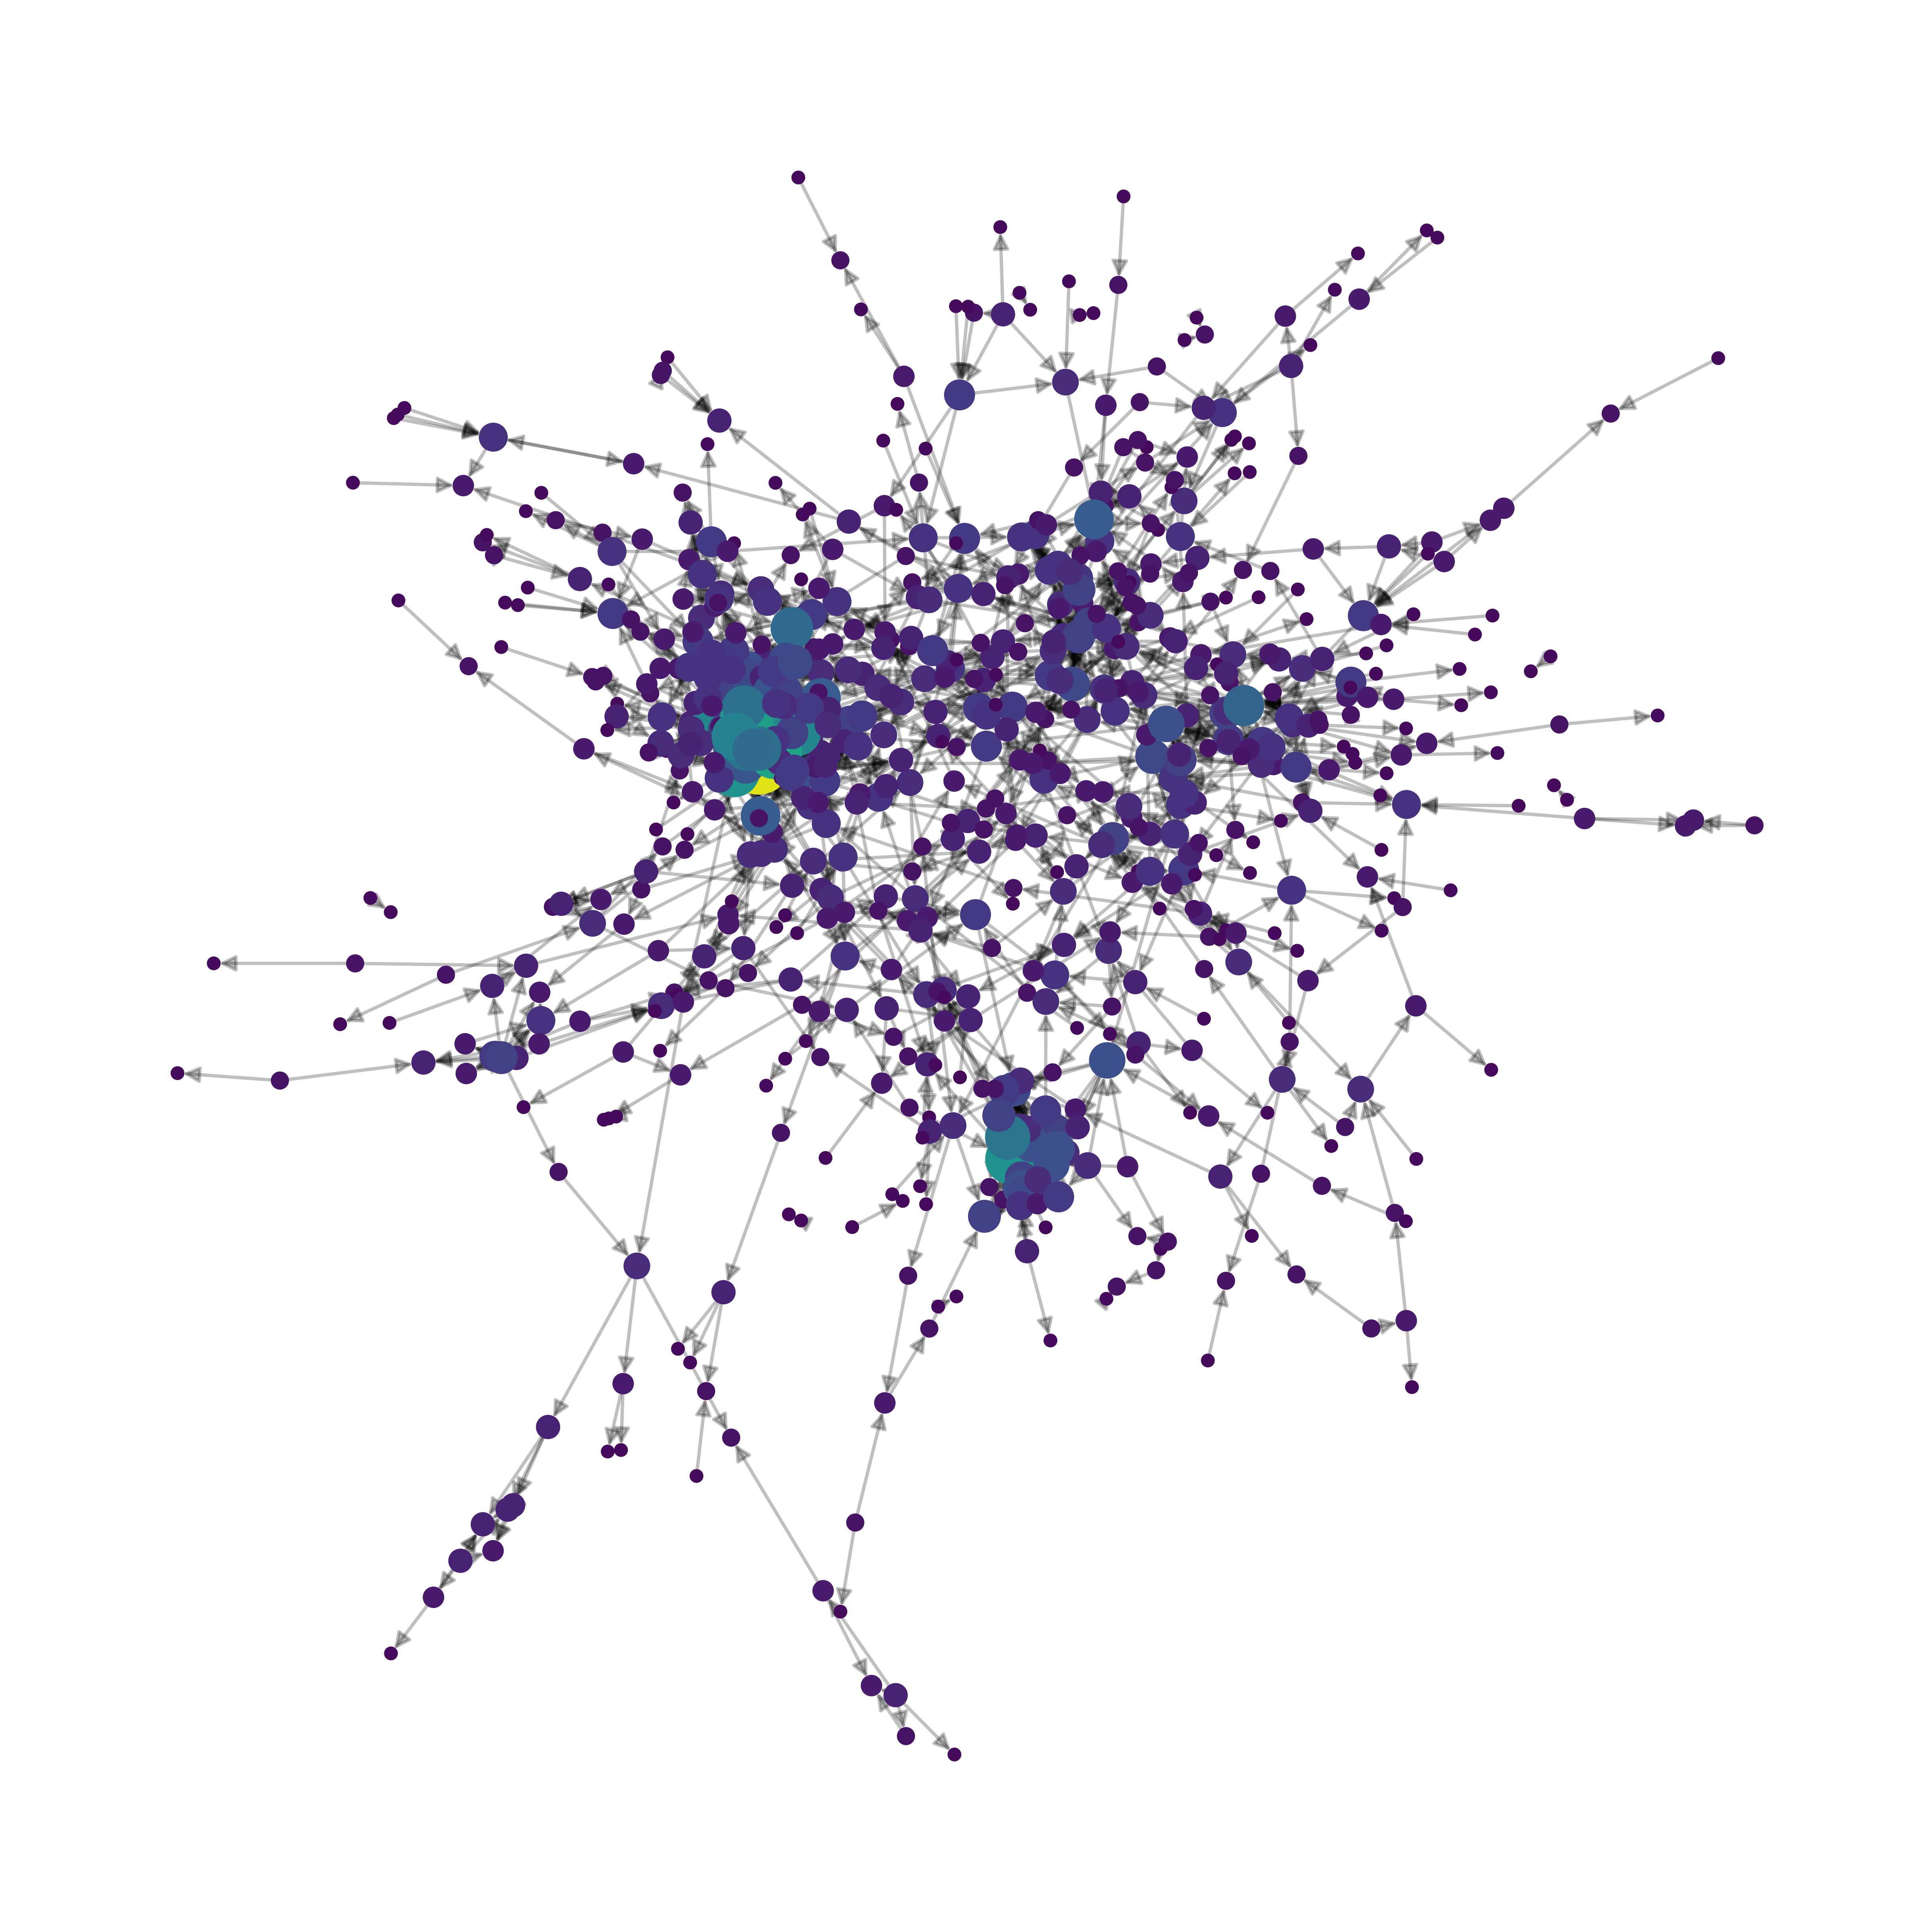

In [71]:
# Read config
conf = OmegaConf.load('config.yaml')

# Set random seed and cpu number
set_cpu_num(conf.cpu_num)
seed_everything(conf.seed)

# Set data and log directory
if conf.graph_type == 'citation':
    conf.data_dir = f'data/{conf.graph_type}'
    conf.log_dir = f'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}'
elif conf.graph_type in ['BA', 'WS']:
    conf.data_dir = f'data/{conf.graph_type}_n{conf.node_num}_{conf.seed}'
    conf.log_dir = f'logs/{conf.graph_type}_n{conf.node_num}_{conf.seed}/l{conf.lookback}_h{conf.horizon}'
else:
    conf.data_dir = f'data/{conf.graph_type}'
    conf.log_dir = f'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}'

print("="*50)
print("STEP 1: Building Citation Network")
print("="*50)

# Create graph
simulator = NetworkSimulator(args=conf)
network, adj_matrix = simulator.buildNetwork()

# Update node_num from actual graph size
conf.node_num = network.number_of_nodes()
print(f"Final network size: {conf.node_num} nodes, {network.number_of_edges()} edges")

# Draw graph
drawGraph(network, layout='spring', filter='random', threshold=0.5, out_path=f'{conf.data_dir}/graph.png')
print(f"Graph visualization saved to: {conf.data_dir}/graph.png")

#step 1.5

In [72]:
if conf.graph_type == 'citation':
  print("="*50)
  print("STEP 1.5: Update csv files")
  print("="*50)
  build_updated_clean_files("data/citation")

STEP 1.5: Update csv files
[GRAPH] Loaded pruned graph: 1624 nodes, 5885 edges
[EDGES] Saved updated edges: 5885 rows → data/citation/updated_clean_edges.csv
[META] Saved updated metadata: 1624 rows → data/citation/updated_clean_meta.csv
[IDMAP] Saved updated ID map: 1624 entries → data/citation/updated_id2idx_clean.json

✔ DONE: updated_clean_edges.csv, updated_clean_meta.csv, and updated_id2idx_clean.json created.


#step 2

In [73]:
print("="*50)
print("STEP 2: Creating Citation Dynamics")
print("="*50)

# Simulate network dynamics
simulator.getSimTraj()

STEP 2: Creating Citation Dynamics
Loaded existing dynamics
Load CitationNetwork dynamics with 1624 nodes


array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [2., 2., 2., 0.],
        [0., 0., 0., 0.],
        [2., 2., 2., 0.]],

       [[5., 5., 1., 4.],
        [5., 5., 1., 2.],
        [4., 4., 0., 4.],
        ...,
        [0., 2., 0., 0.],
        [0., 0., 0., 0.],
        [0., 2., 0., 0.]],

       [[0., 5., 0., 0.],
        [0., 5., 0., 0.],
        [0., 4., 0., 0.],
        ...,
        [0., 2., 0., 0.],
        [0., 0., 0., 0.],
        [0., 2., 0., 0.]],

       [[0., 5., 0., 0.],
        [0., 5., 0., 0.],
        [0., 4., 0., 0.],
        ...,
        [0., 2., 0., 0.],
        [0., 0., 0., 0.],
        [0., 2., 0., 0.]],

       [[0., 5., 0., 0.],
        [0., 5., 0., 0.],
        [0., 4., 0., 0.],
        ...,
        [0., 2., 0., 0.],
        [0., 0., 0., 0.],
        [0., 2., 0., 0.]],

       [[0., 5., 0., 0.],
        [0., 5., 0., 0.],
        [0., 4., 0., 0.],
        ...,
        [0., 2., 0., 0.],
        [0., 0., 0., 0.],
  

#step 3

In [74]:
"""
conf.lookback = 1
conf.horizon = 1
conf.max_epoch = 10
conf.batch_size = 1
conf.train_ratio = 0.6
conf.val_ratio = 0.2
conf.test_ratio = 0.2


print("="*50)
print("STEP 3: Preparing Datasets")
print("="*50)

# Dataset
train_dataset = CitationDataset(conf, mode='train')
val_dataset = CitationDataset(conf, mode='val')
test_dataset = CitationDataset(conf, mode='test')


print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

"""

'\nconf.lookback = 1\nconf.horizon = 1\nconf.max_epoch = 10\nconf.batch_size = 1\nconf.train_ratio = 0.6\nconf.val_ratio = 0.2\nconf.test_ratio = 0.2\n\n\nprint("="*50)\nprint("STEP 3: Preparing Datasets")\nprint("="*50)\n\n# Dataset\ntrain_dataset = CitationDataset(conf, mode=\'train\')\nval_dataset = CitationDataset(conf, mode=\'val\')\ntest_dataset = CitationDataset(conf, mode=\'test\')\n\n\nprint(f"Train samples: {len(train_dataset)}")\nprint(f"Val samples: {len(val_dataset)}")\nprint(f"Test samples: {len(test_dataset)}")\n\n'

In [75]:
print("="*50)
print("STEP 3: Preparing Datasets")
print("="*50)

# Dataset
train_dataset = CitationDataset(conf, mode='train')
val_dataset = CitationDataset(conf, mode='val')
test_dataset = CitationDataset(conf, mode='test')


print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

STEP 3: Preparing Datasets
Train samples: 3
Val samples: 1
Test samples: 1


#step 4

In [76]:
print("="*50)
print("STEP 4: Training DiskNet Model")
print("="*50)

# Model
model = DiskNet(conf, adj_matrix)
print_model_summary(model)

# Train
try:
    print(train_dataset.getLoader())
    print(val_dataset.getLoader())
    model.fit(train_dataset.getLoader(), val_dataset.getLoader())
except Exception as e:
    print(f"An error occurred during model training: {e}")
    import traceback
    traceback.print_exc()


STEP 4: Training DiskNet Model
Initializing super node embedding...
Pretrain identity backbone[499]: 0.0311
DiskNet(
  (repr_net1): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  )
  (repr_net2): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  )
  (softmax): Softmax(dim=-1)
  (agc_mlp): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
  (tanh): Tanh()
  (BackboneODE): BackboneODE(
    (init_enc): Sequential(
      (0): Linear(in_features=1, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=1, bias=True

#step 5

In [77]:
print("="*50)
print("STEP 5: Testing Model")
print("="*50)

# Test and get predictions
model.test(test_dataset.getLoader())

# Load test results
results = np.load(f'{conf.log_dir}/{conf.dynamics}/{conf.model}/result.npz')
predicted_dynamics = results['predict']  # Shape: (n_samples, horizon, node_num, feature_dim)
actual_dynamics = results['ground_truth']

print(f"Prediction shape: {predicted_dynamics.shape}")
print(f"Ground truth shape: {actual_dynamics.shape}")

STEP 5: Testing Model
Testing...
Prediction shape: (1, 1, 1624, 4)
Ground truth shape: (1, 1, 1624, 4)


#step 6

In [78]:
print("="*50)
print("STEP 6: Anomaly Detection")
print("="*50)

# Initialize anomaly detector
detector = CitationAnomalyDetector(contamination=0.1)  # Expect 10% anomalies

# Detect anomalies
# Assumes: anomaly_labels are -1 for anomaly, 1 for normal
deviation_scores, anomaly_labels = detector.detect_anomalies(predicted_dynamics, actual_dynamics)

# Count anomalies (Using standard convention: -1 is ANOMALOUS)
n_anomalies = np.sum(anomaly_labels == -1)
n_normal = np.sum(anomaly_labels == 1)

print(f"Total nodes analyzed: {len(anomaly_labels)}")
print(f"Anomalous nodes detected: {n_anomalies}")
print(f"Normal nodes: {n_normal}")
print(f"Anomaly rate: {n_anomalies/len(anomaly_labels)*100:.2f}%")


# 1. Get indices of all nodes classified as ANOMALOUS (labels == -1)
# NOTE: This index is used for saving all anomalies, not necessarily the top 10.
anomalous_indices = np.where(anomaly_labels == -1)[0]

# 2. Find the TOP 10 MOST EXTREME nodes based on the MAGNITUDE of the deviation score.
# This captures nodes with the highest positive OR highest negative scores.
# np.argsort returns indices sorted from smallest to largest absolute score.
# [-10:] takes the indices of the 10 largest absolute scores.
# [::-1] reverses that list so the most extreme is first.
abs_scores = np.abs(deviation_scores)
top_anomalies_indices = np.argsort(abs_scores)[-10:]
top_anomalies = top_anomalies_indices[::-1]

print("\nTop 10 Most EXTREME Anomalous Nodes (by score magnitude):")
print("Node ID | Deviation Score")
print("-" * 35)
for idx in top_anomalies:
    print(f"{idx:7d} | {deviation_scores[idx]:13.6f}")

# Save anomaly detection results
anomaly_results_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_results.npz'
np.savez(anomaly_results_path,
          deviation_scores=deviation_scores,
          anomaly_labels=anomaly_labels,
          anomalous_nodes=anomalous_indices,
          top_anomalies=top_anomalies)

print(f"\nAnomaly detection results saved to: {anomaly_results_path}")

# Create anomaly report
create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices)

print("="*50)
print("PIPELINE COMPLETED!")
print("="*50)
print(f"Check results in: {conf.log_dir}/{conf.dynamics}/{conf.model}/")

STEP 6: Anomaly Detection
Total nodes analyzed: 1624
Anomalous nodes detected: 163
Normal nodes: 1461
Anomaly rate: 10.04%

Top 10 Most EXTREME Anomalous Nodes (by score magnitude):
Node ID | Deviation Score
-----------------------------------
    299 |      8.799556
   1221 |      6.076585
   1286 |      5.835891
    780 |      5.737258
    668 |      5.518574
    636 |      5.434654
   1240 |      5.375682
    383 |      4.488425
    539 |      4.335588
    836 |      4.117761

Anomaly detection results saved to: logs/citation/l1_h1/CitationNetwork/DiskNet/anomaly_results.npz
Detailed report saved to: logs/citation/l1_h1/CitationNetwork/DiskNet/anomaly_report.txt
PIPELINE COMPLETED!
Check results in: logs/citation/l1_h1/CitationNetwork/DiskNet/


#step 7

In [79]:
print("="*50)
print("STEP 7: Compiling Per-Year Anomaly Report")
print("="*50)

num_test_samples = predicted_dynamics.shape[0]
num_nodes = predicted_dynamics.shape[2]

print(f"Number of test samples (years): {num_test_samples}")
print(f"Number of nodes: {num_nodes}")

STEP 7: Compiling Per-Year Anomaly Report
Number of test samples (years): 1
Number of nodes: 1624


In [80]:
df_report = pd.DataFrame({'Node ID': np.arange(num_nodes)})

# Process anomalies for each test sample (representing a distinct "year" or time window)
for i in range(num_test_samples):
    # Extract predicted and actual dynamics for the current test sample (year)
    pred_for_year_i = predicted_dynamics[i, :, :, :]
    actual_for_year_i = actual_dynamics[i, :, :, :]

    # Reshape for detector: add a batch dimension of 1
    pred_for_year_i_batched = pred_for_year_i[np.newaxis, :, :, :]
    actual_for_year_i_batched = actual_for_year_i[np.newaxis, :, :, :]

    # Detect anomalies for this specific "year"
    deviation_scores_i, anomaly_labels_i = detector.detect_anomalies(
        pred_for_year_i_batched, actual_for_year_i_batched
    )

    # Convert anomaly labels from {-1, 1} to {0, 1} for clarity (1 for anomaly, 0 for normal)
    is_anomaly_binary_i = (anomaly_labels_i == -1).astype(int)

    # Add results to the DataFrame
    df_report[f'Year {i} (Deviation Score)'] = deviation_scores_i
    df_report[f' Year {i} (Is Anomaly)'] = is_anomaly_binary_i


# Calculate the Mean Deviation Score for each node across all years
score_columns = [col for col in df_report.columns if '(Deviation Score)' in col]
df_report['Mean Deviation Score'] = df_report[score_columns].mean(axis=1)

# Calculate Anomaly Status Churn
# Identify all binary anomaly status columns
anomaly_status_columns = [col for col in df_report.columns if '(Is Anomaly)' in col]

# The churn calculation:
# If the max value (1) is greater than the min value (0) for a node across all years,
# it means the status must have changed from 0 to 1 or vice versa.
# df.max(axis=1) - df.min(axis=1) will be 1 if there was a change (1-0) and 0 if not (0-0 or 1-1).
df_report['Anomaly Status Churn'] = (
    df_report[anomaly_status_columns].max(axis=1) - df_report[anomaly_status_columns].min(axis=1)
)

# Define the path for the new CSV report
report_csv_path = os.path.join(conf.log_dir, conf.dynamics, conf.model, 'anomaly_report_per_year.csv')

# Save the compiled anomaly report to a CSV file
df_report.to_csv(report_csv_path, index=False)

print(f"Per-year anomaly report generated and saved to: {report_csv_path}")
print("Final Task: Per-year anomaly report successfully generated and saved to CSV.")

Per-year anomaly report generated and saved to: logs/citation/l1_h1/CitationNetwork/DiskNet/anomaly_report_per_year.csv
Final Task: Per-year anomaly report successfully generated and saved to CSV.


#step 8

STEP 8: Anomaly Detection Evaluation (Per-Year and Aggregate Visualization)

Generating plots for 1 time windows (Years 0 to 0)...


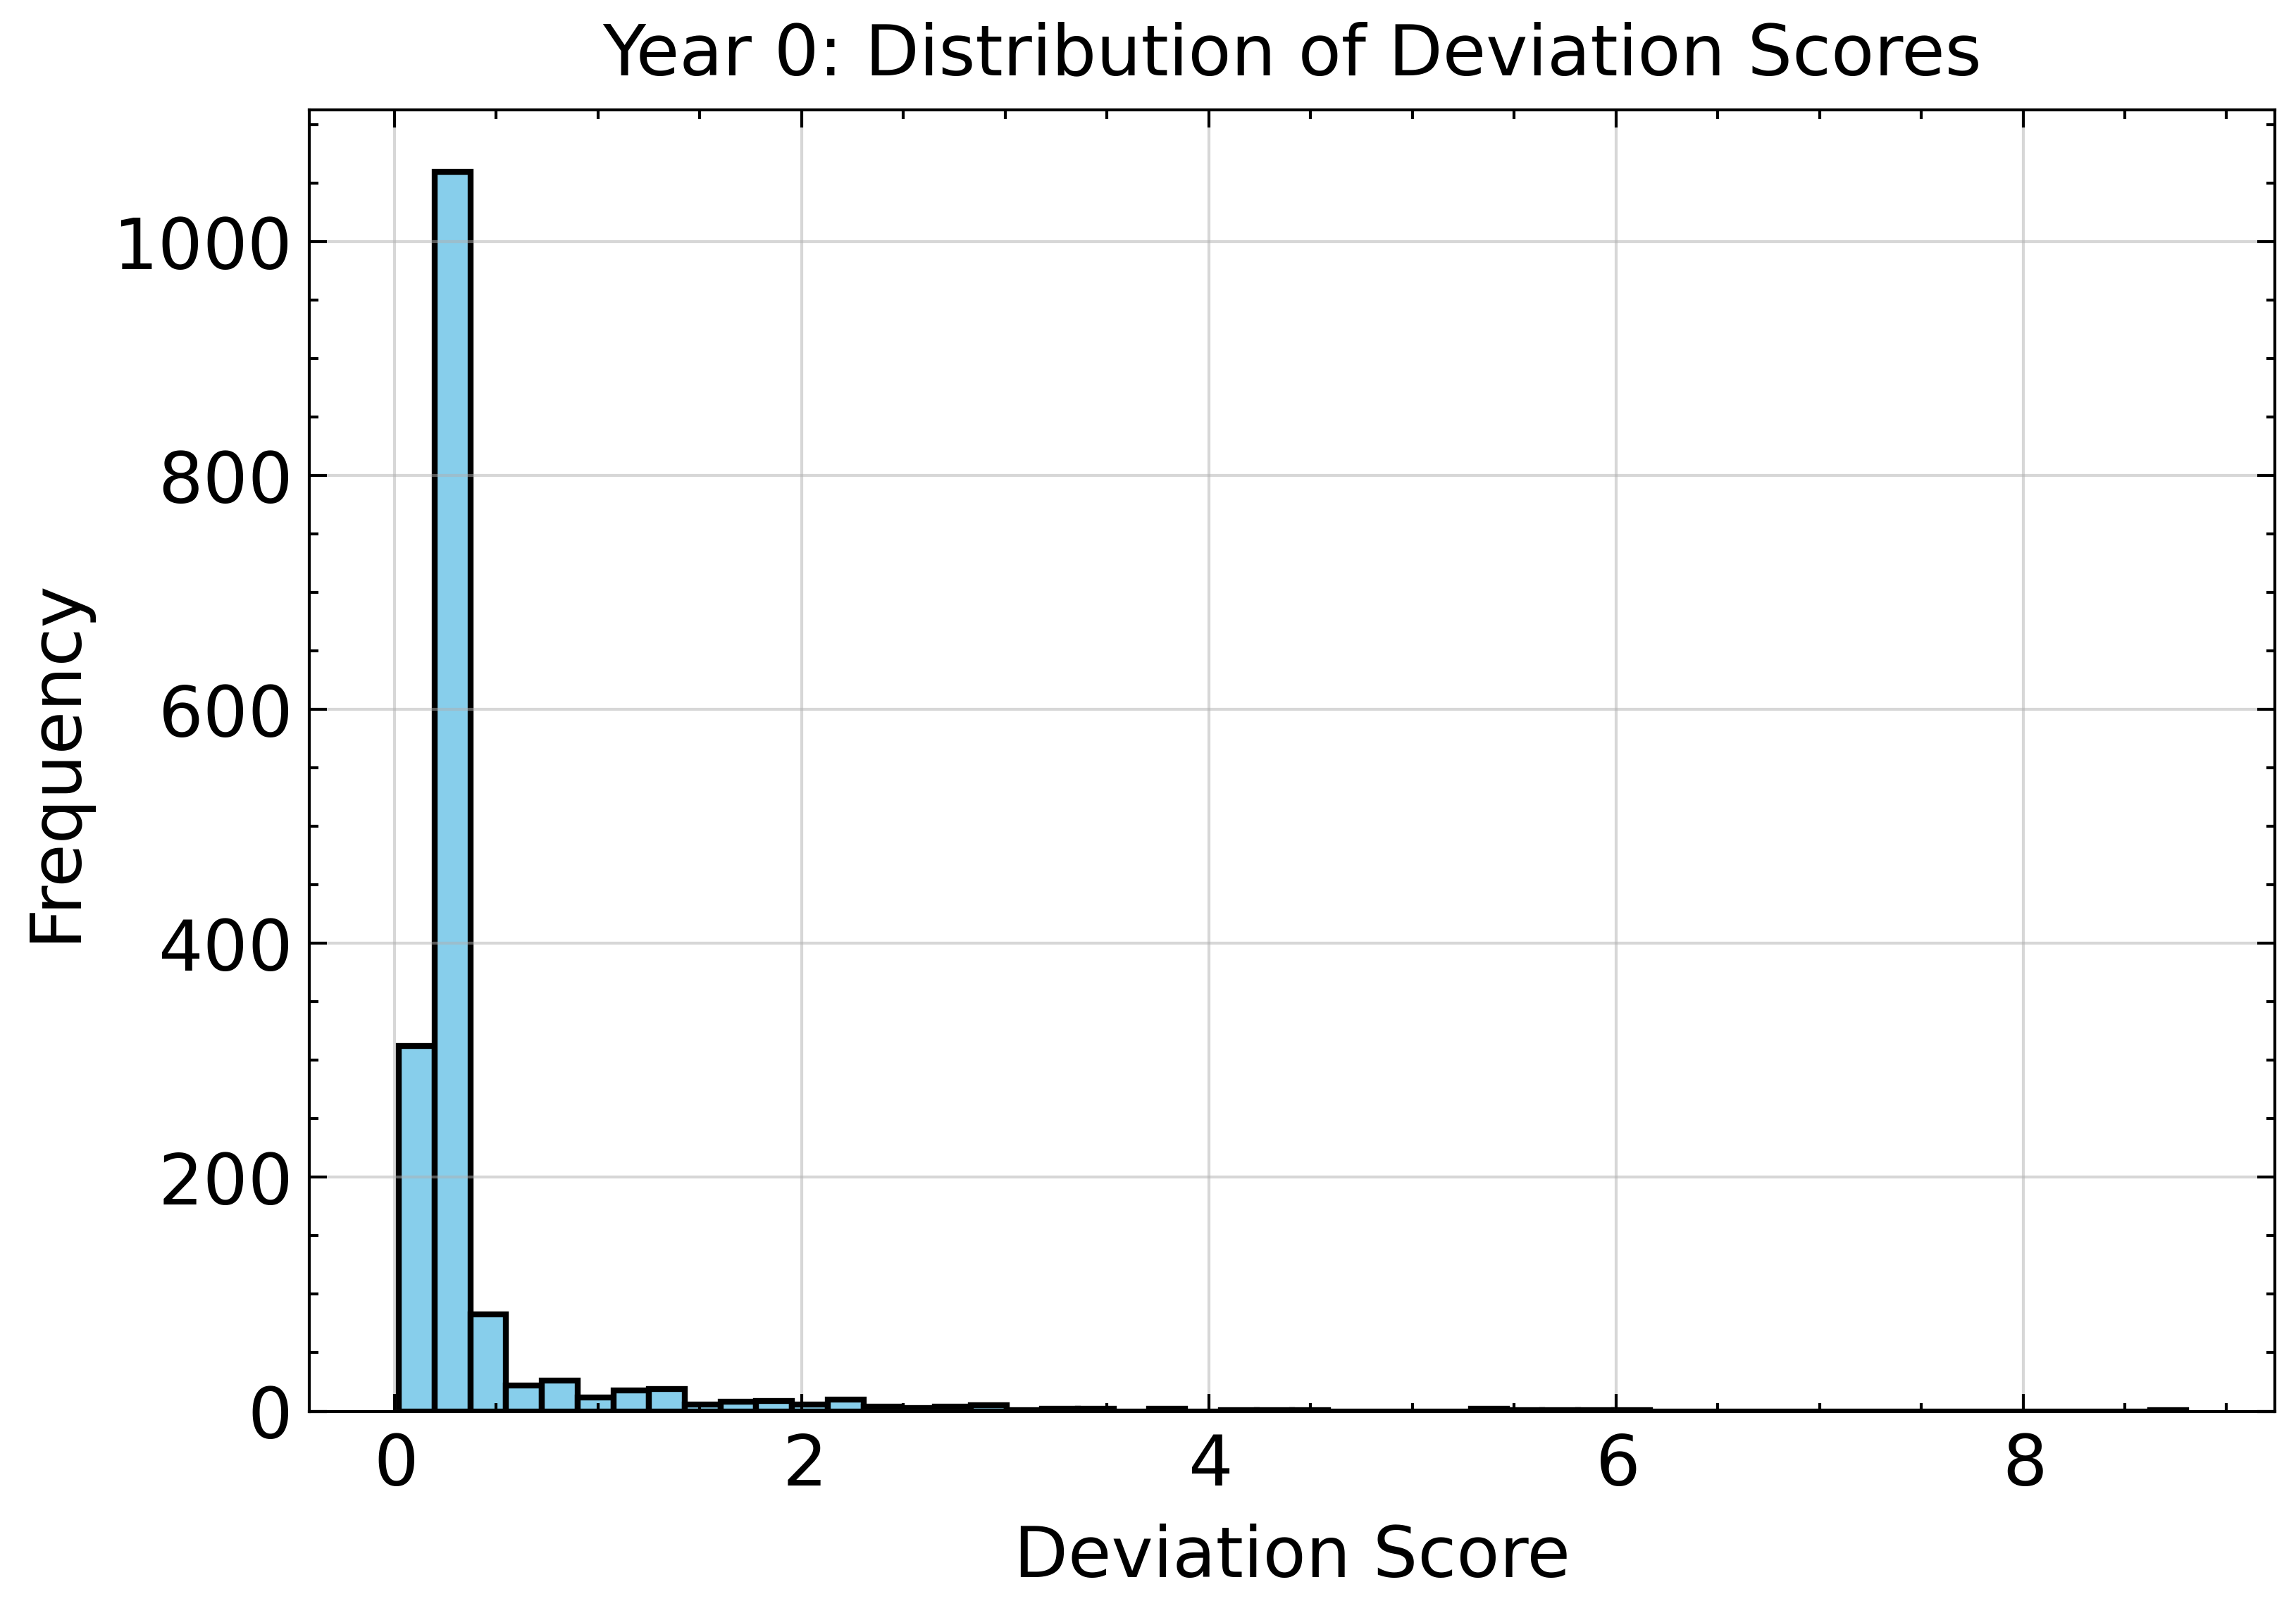

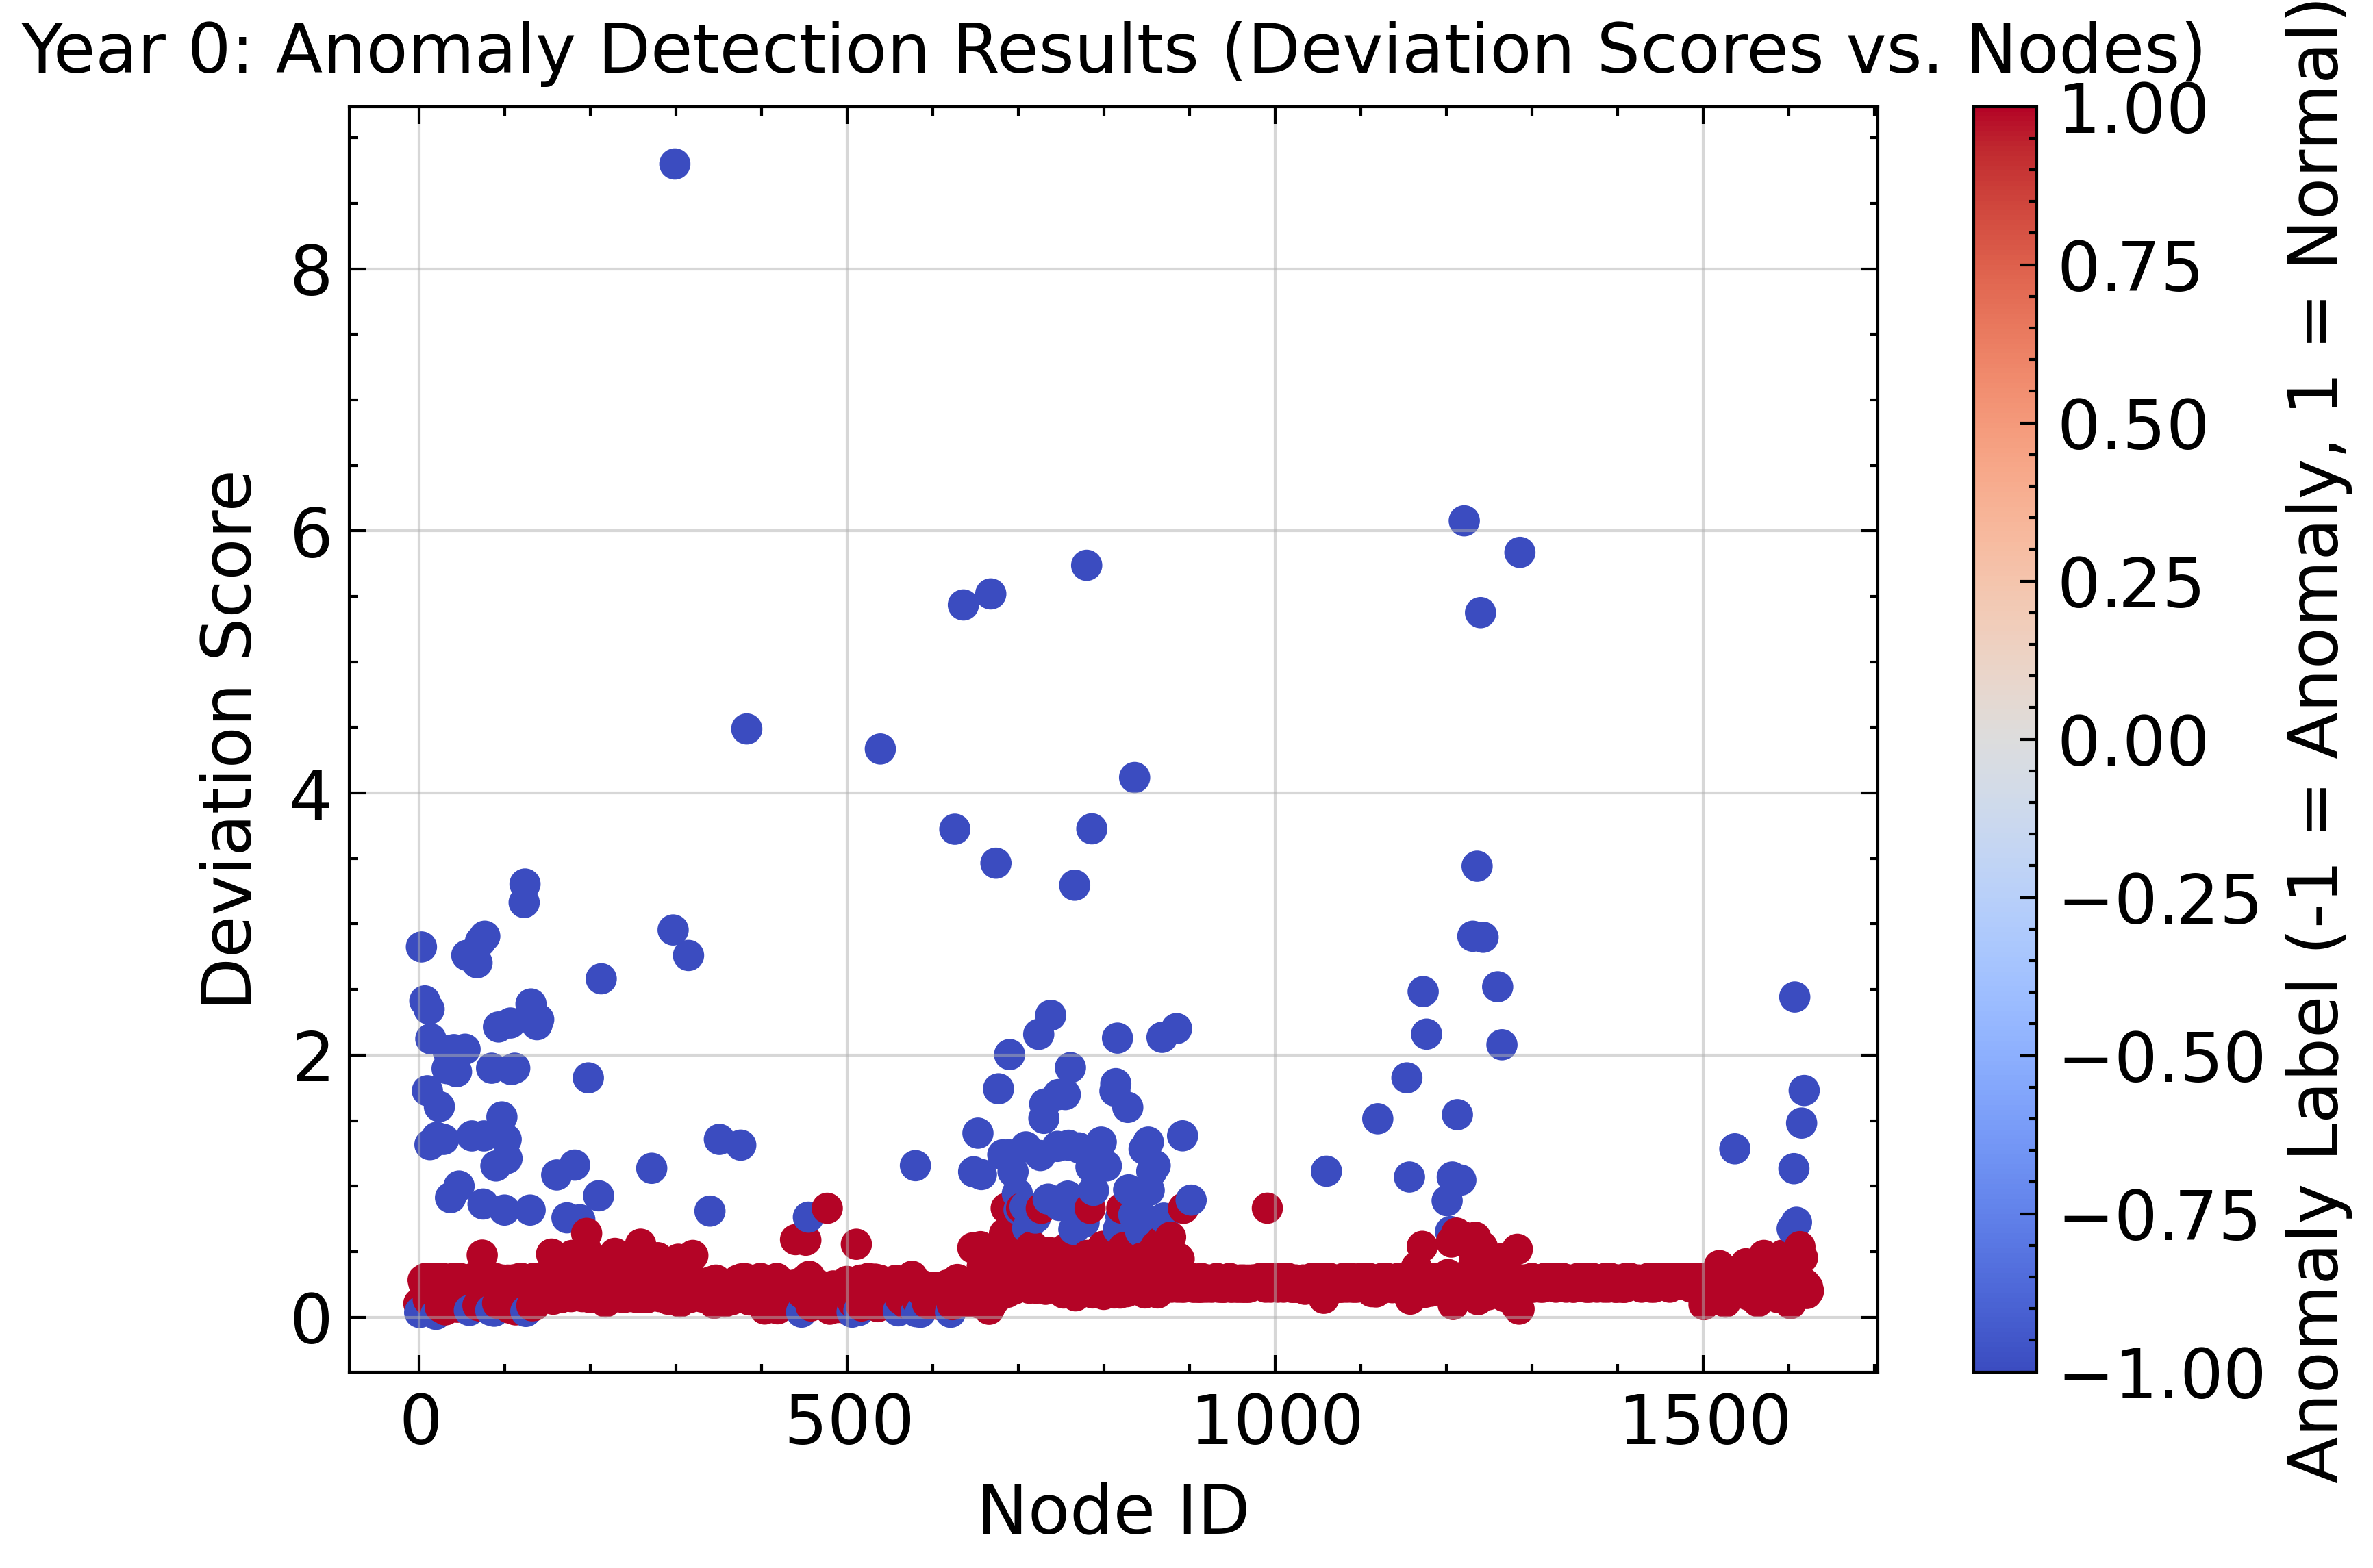

-> Plots generated for Year 0.

Generating final aggregate plots (Mean Deviation Score across all years)...
-> Aggregate Thresholds: Lower=0.0214, Upper=1.3102


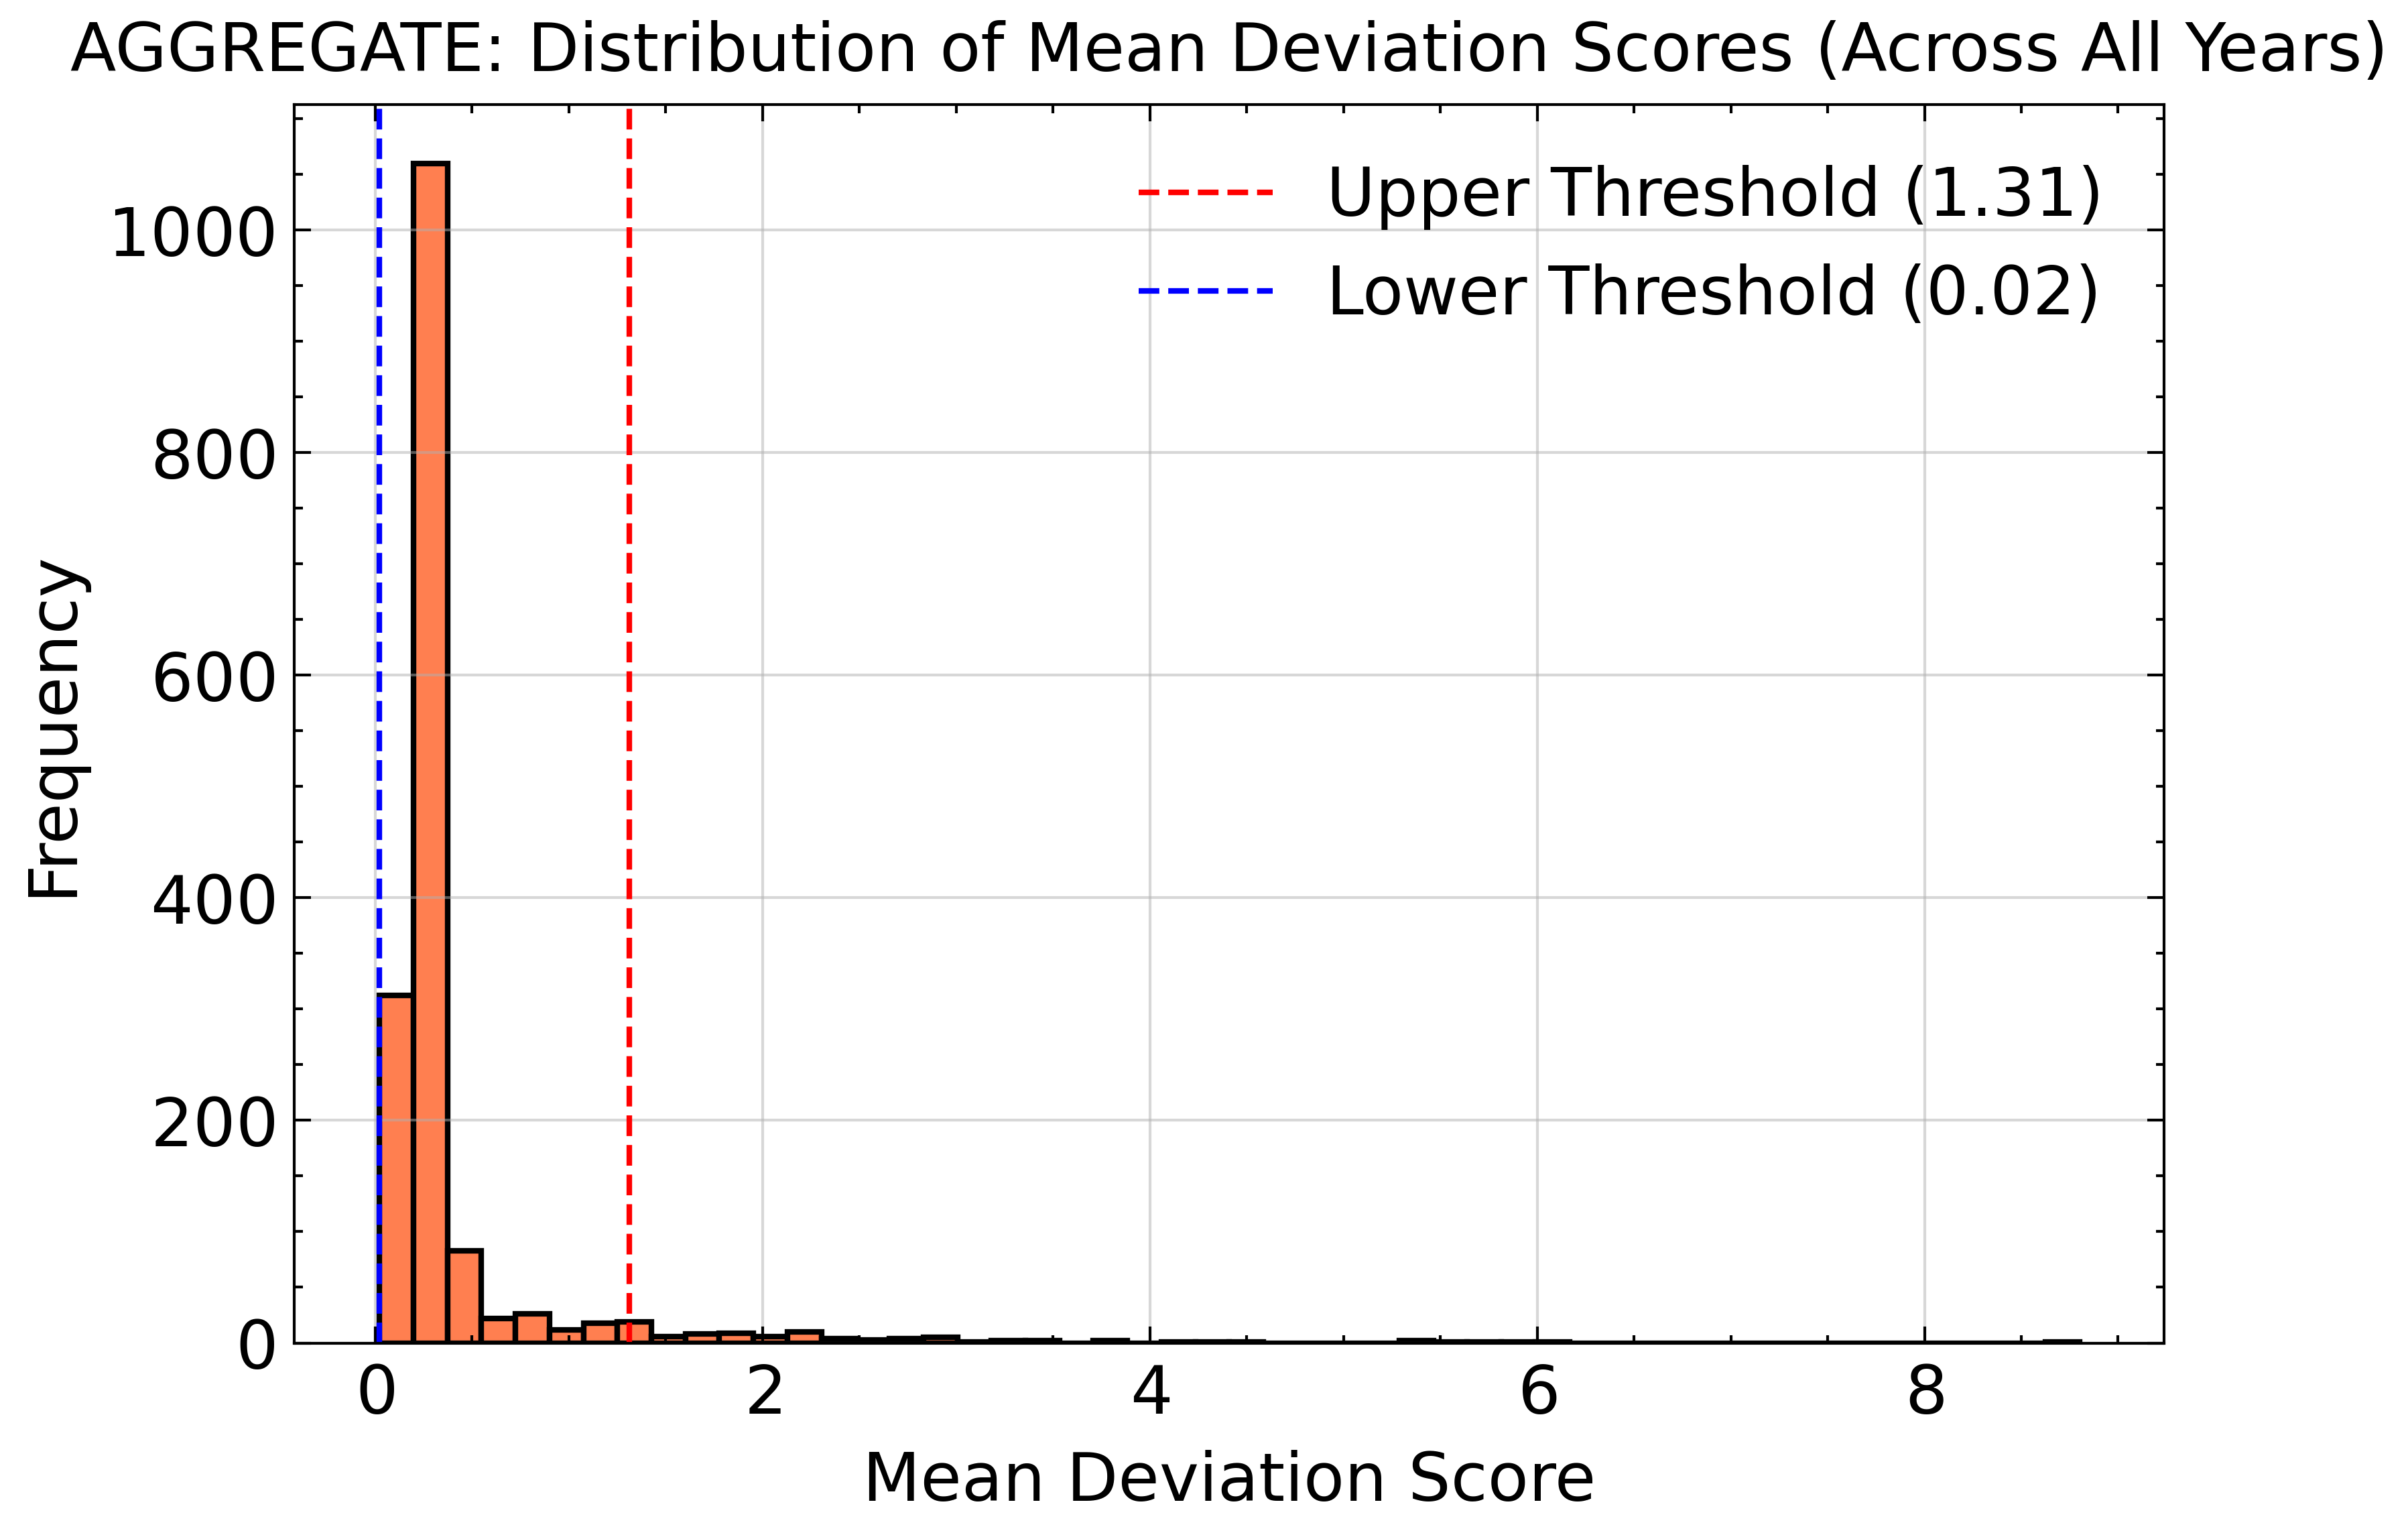

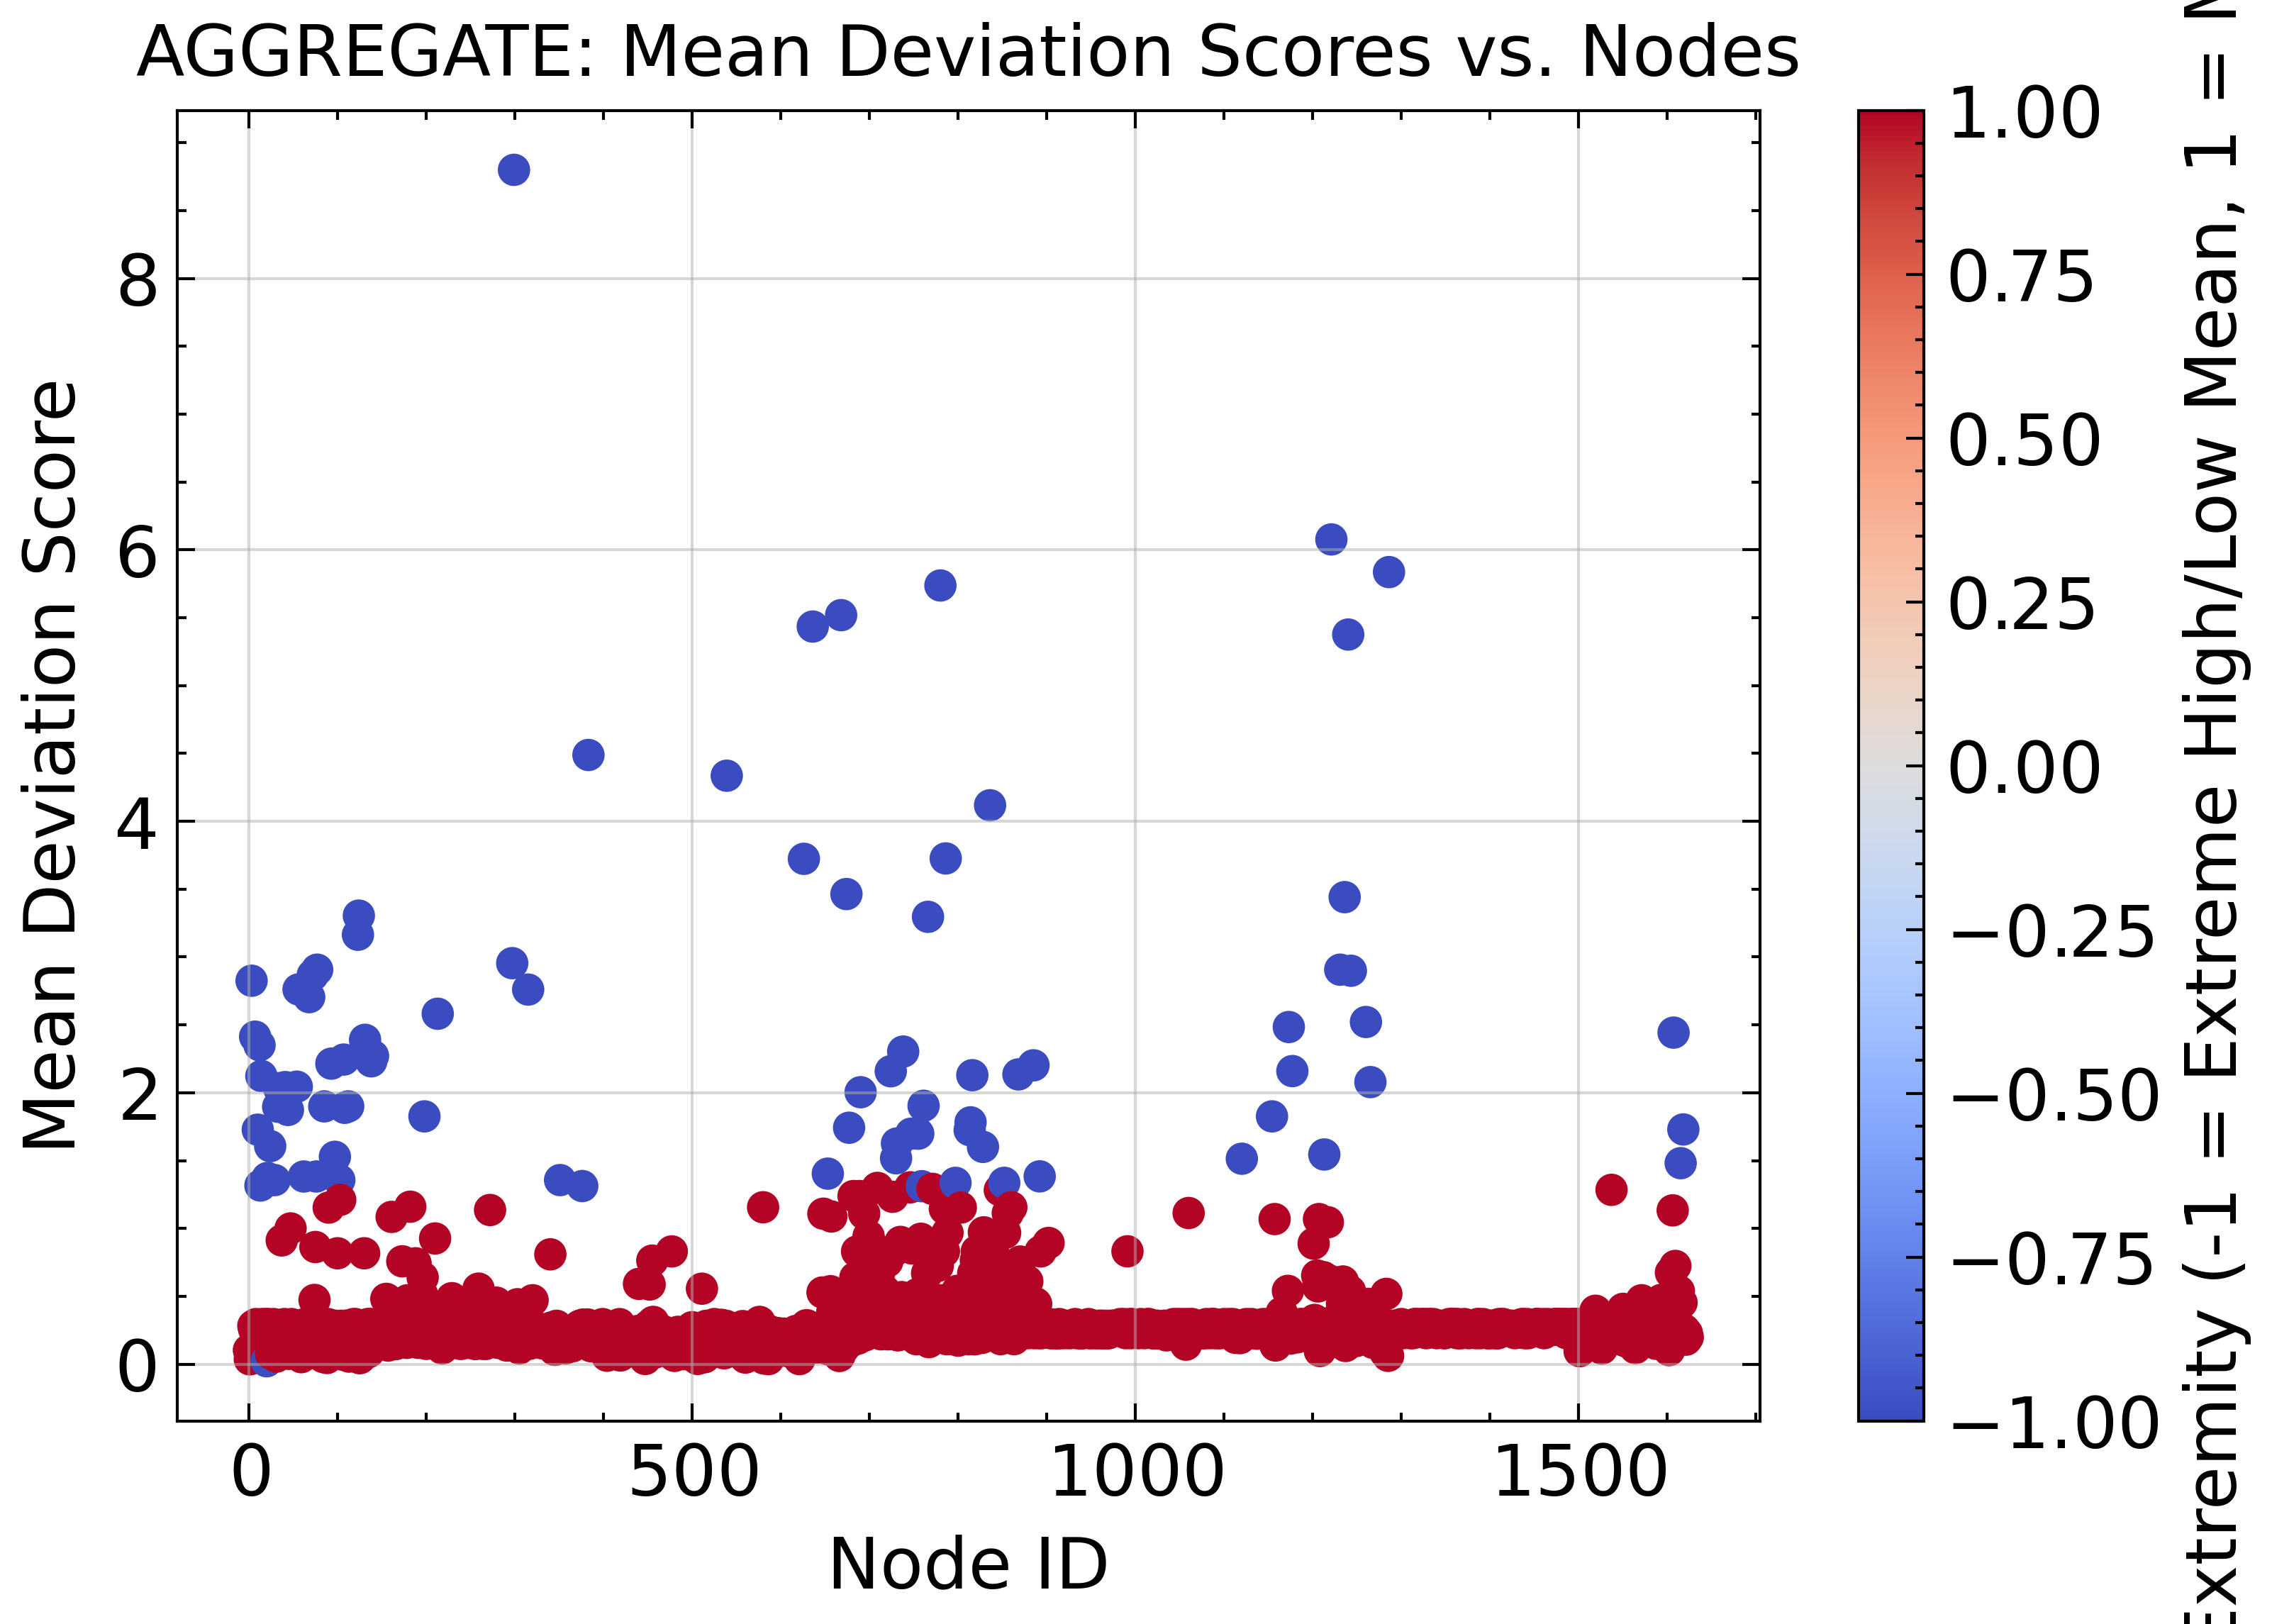


Top EXTREME Nodes (by Mean Deviation Score Magnitude):
Node ID | Mean Deviation Score | Extremity Type
---------------------------------------------
    299 |             8.799556 | HIGH
   1221 |             6.076585 | HIGH
   1286 |             5.835891 | HIGH
    780 |             5.737258 | HIGH
    668 |             5.518574 | HIGH
     20 |             0.021444 | LOW
STEP 8 COMPLETED! All per-year and aggregate plots generated.


In [81]:
print("="*50)
print("STEP 8: Anomaly Detection Evaluation (Per-Year and Aggregate Visualization)")
print("="*50)

try:
    # Load the per-year report generated in the previous step
    df_report = pd.read_csv(report_csv_path)
except FileNotFoundError:
    print(f"Error: Could not find report file at {report_csv_path}")
    print("Please ensure STEP 6 (Per-Year Reporting) ran successfully.")
    sys.exit() # Use sys.exit() instead of exit() for clean script termination

# Identify relevant columns
score_columns = [col for col in df_report.columns if '(Deviation Score)' in col]
label_columns = [col for col in df_report.columns if '(Is Anomaly)' in col]
num_test_samples = len(score_columns)

if num_test_samples == 0:
    print("Error: No 'Deviation Score' columns found in the CSV. Visualization aborted.")
    sys.exit()

# Ensure 'Node ID' and 'Mean Deviation Score' exist for aggregate plots
if 'Node ID' not in df_report.columns or 'Mean Deviation Score' not in df_report.columns:
    print("Error: 'Node ID' or 'Mean Deviation Score' column missing for aggregate plotting.")
    sys.exit()


# ======================================================================
# 1. PER-YEAR PLOTTING
# ======================================================================

print(f"\nGenerating plots for {num_test_samples} time windows (Years 0 to {num_test_samples - 1})...")

for i in range(num_test_samples):
    year_score_col = score_columns[i]
    year_label_col = label_columns[i]

    deviation_scores = df_report[year_score_col].values
    # Convert binary label (0, 1) to standard anomaly label (1, -1) for visualization
    # Where 1 (anomaly) -> -1, and 0 (normal) -> 1
    anomaly_labels = np.where(df_report[year_label_col].values == 1, -1, 1)

    # --- Plot 1: Histogram of Deviation Scores for the Year ---
    plt.figure(figsize=(6, 4))
    plt.hist(deviation_scores, bins=50, color='skyblue', edgecolor='black')
    plt.title(f"Year {i}: Distribution of Deviation Scores")
    plt.xlabel("Deviation Score")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.5)
    plt.show()

    # --- Plot 2: Scatter Plot of Deviation Scores vs. Nodes for the Year ---
    plt.figure(figsize=(6, 4))
    plt.scatter(
        df_report['Node ID'].values,
        deviation_scores,
        c=anomaly_labels,
        cmap='coolwarm',
        s=20
    )
    plt.title(f"Year {i}: Anomaly Detection Results (Deviation Scores vs. Nodes)")
    plt.xlabel("Node ID")
    plt.ylabel("Deviation Score")
    plt.colorbar(label='Anomaly Label (-1 = Anomaly, 1 = Normal)')
    plt.grid(True, alpha=0.5)
    plt.show()

    print(f"-> Plots generated for Year {i}.")


# ======================================================================
# 2. FINAL AGGREGATE PLOTTING (Using Mean Deviation Score)
# ======================================================================

print("\nGenerating final aggregate plots (Mean Deviation Score across all years)...")

# Use the pre-calculated 'Mean Deviation Score' from the DataFrame
aggregate_scores = df_report['Mean Deviation Score'].values

# --- CALCULATE THRESHOLDS AND LABELS (UPDATED LOGIC) ---

# Define the standard deviation multiplier here to make it easy to change
std_factor = 1.5 # <-- CHANGED FROM 2 TO 1.5

# Calculate a simple statistical measure (like standard deviation)
mean_of_scores = np.mean(aggregate_scores)
std_of_scores = np.std(aggregate_scores)

# Define the thresholds (using 1.5 standard deviations for 'extreme'):
# Upper Threshold: Catches nodes with a very high positive average score.
upper_threshold = mean_of_scores + (std_of_scores * std_factor) # <-- Uses 1.5

# Lower Threshold: Catches nodes with a very low positive average score (your concern).
lower_threshold = mean_of_scores - (std_of_scores * std_factor) # <-- Uses 1.5

# Ensure the lower threshold is not less than the minimum observed score
# For robustness with non-negative data:
lower_threshold = max(np.min(aggregate_scores), lower_threshold)


# Create the aggregate labels:
# Anomaly (-1) if the score is >= Upper_Threshold OR <= Lower_Threshold
aggregate_labels = np.where(
    (aggregate_scores >= upper_threshold) | (aggregate_scores <= lower_threshold),
    -1, # Extreme Anomaly (High or Low)
    1 # Moderate Mean
)

print(f"-> Aggregate Thresholds: Lower={lower_threshold:.4f}, Upper={upper_threshold:.4f}")

# --- Plot 3: Histogram of Mean Deviation Scores ---
plt.figure(figsize=(6, 4))
plt.hist(aggregate_scores, bins=50, color='coral', edgecolor='black')
plt.axvline(upper_threshold, color='red', linestyle='--', label=f'Upper Threshold ({upper_threshold:.2f})')
plt.axvline(lower_threshold, color='blue', linestyle='--', label=f'Lower Threshold ({lower_threshold:.2f})')
plt.title("AGGREGATE: Distribution of Mean Deviation Scores (Across All Years)")
plt.xlabel("Mean Deviation Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# --- Plot 4: Scatter Plot of Mean Deviation Scores vs. Nodes (with corrected labels) ---
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    df_report['Node ID'].values,
    aggregate_scores,
    c=aggregate_labels,
    cmap='coolwarm',
    s=20
)
plt.title("AGGREGATE: Mean Deviation Scores vs. Nodes")
plt.xlabel("Node ID")
plt.ylabel("Mean Deviation Score")
# Update the label to reflect the dual definition
plt.colorbar(scatter, label='Mean Score Extremity (-1 = Extreme High/Low Mean, 1 = Moderate Mean)')
plt.grid(True, alpha=0.5)
plt.show()

# --- Optionally, print top anomalous nodes based on AGGREGATE mean score ---
# Find top 5 most extreme high and top 5 most extreme low scores
top_high_mask = aggregate_scores >= upper_threshold
top_low_mask = aggregate_scores <= lower_threshold

# Get indices of nodes that are anomalies based on the dual threshold
anomalous_indices = np.where(aggregate_labels == -1)[0]
if len(anomalous_indices) > 0:
    # Separate them into High and Low lists for printing
    high_anomalies_indices = anomalous_indices[aggregate_scores[anomalous_indices] >= upper_threshold]
    low_anomalies_indices = anomalous_indices[aggregate_scores[anomalous_indices] <= lower_threshold]

    # Sort and take top N for display
    top_high_indices_sorted = high_anomalies_indices[np.argsort(aggregate_scores[high_anomalies_indices])[-5:][::-1]]
    top_low_indices_sorted = low_anomalies_indices[np.argsort(aggregate_scores[low_anomalies_indices])[:5]]

    top_aggregate_indices_print = np.concatenate((top_high_indices_sorted, top_low_indices_sorted))

    print("\nTop EXTREME Nodes (by Mean Deviation Score Magnitude):")
    print("Node ID | Mean Deviation Score | Extremity Type")
    print("-" * 45)

    for idx in top_aggregate_indices_print:
        extremity_type = "HIGH" if aggregate_scores[idx] >= upper_threshold else "LOW"
        node_id = df_report['Node ID'].values[idx]
        print(f"{node_id:7d} | {aggregate_scores[idx]:20.6f} | {extremity_type}")
else:
    # UPDATED print statement
    print(f"\nNo extreme anomalies detected based on the {std_factor}-sigma thresholds.")


print("="*50)
print("STEP 8 COMPLETED! All per-year and aggregate plots generated.")
print("="*50)

#all steps

### User Input: Number of Iterations

In [17]:
  #@title Enter the number of iterations (k)
k = 2 #@param {type:"integer"}

if k <= 0:
    print("Number of iterations (k) must be a positive integer. Setting k to 1.")
    k = 1
else:
    print(f"Pipeline will run for {k} iteration(s).")

Pipeline will run for 2 iteration(s).


### All Steps (0-8) Looped k Times

In [19]:
# --- Global Paths (Original unmodified data) ---
# These point to the *source* of the clean data, not the iteration-specific validation data.
DATA_DIR = "data"
ORIGINAL_CLEAN_META_PATH = os.path.join(DATA_DIR, "citation", "clean_meta.csv")
ORIGINAL_CLEAN_EDGES_PATH = os.path.join(DATA_DIR, "citation", "clean_edges.csv")
ORIGINAL_TOPICS_JSON_PATH = os.path.join(DATA_DIR, "Topics and conceptes.JSON")


# --- Helper Functions (copied and potentially modified for iteration-specific paths) ---
# These are copies of functions from the original steps, adjusted to accept paths.
# This avoids modifying the original step cells directly.

def load_data_iter(clean_meta_path, clean_edges_path, topics_json_path):
    print("Loading data files...")
    clean_meta_df = pd.read_csv(clean_meta_path)
    print(f"Loaded {os.path.basename(clean_meta_path)}: {len(clean_meta_df)} rows")
    clean_edges_df = pd.read_csv(clean_edges_path)
    print(f"Loaded {os.path.basename(clean_edges_path)}: {len(clean_edges_df)} rows")
    with open(topics_json_path, 'r', encoding='utf-8') as f:
        topics_concepts = json.load(f)
    print(f"Loaded topics and concepts: {len(topics_concepts)} topics")
    return clean_meta_df, clean_edges_df, topics_concepts

def save_and_sort_validation_files(original_nodes_df: pd.DataFrame, synthetic_nodes: List[Dict], original_edges_df: pd.DataFrame, synthetic_edges: List[Dict],
                                   VALIDATION_NODES_PATH: str, VALIDATION_EDGES_PATH: str):
    """Merges original and synthetic data, sorts both the node and edge files by ID, and saves them."""
    print("\nMerging, Sorting, and Saving validation files...")

    # 1. NODES: Merge, Sort, and Save (Still sorted by ID)
    synthetic_nodes_df = pd.DataFrame(synthetic_nodes)
    if not synthetic_nodes_df.empty:
        synthetic_nodes_df = synthetic_nodes_df[original_nodes_df.columns]
        combined_nodes_df = pd.concat([original_nodes_df, synthetic_nodes_df], ignore_index=True)
    else:
        combined_nodes_df = original_nodes_df.copy()
    combined_nodes_df = combined_nodes_df.sort_values(by='id').reset_index(drop=True)
    combined_nodes_df.to_csv(VALIDATION_NODES_PATH, index=False)
    print(f"Saved {VALIDATION_NODES_PATH} (N={len(combined_nodes_df)}) - **Sorted by ID**")


    # 2. EDGES: Merge, Sort, and Save (Still sorted by Source/Target ID)
    synthetic_edges_df = pd.DataFrame(synthetic_edges)
    if not synthetic_edges_df.empty:
        synthetic_edges_df = synthetic_edges_df[original_edges_df.columns]
        combined_edges_df = pd.concat([original_edges_df, synthetic_edges_df], ignore_index=True)
    else:
        combined_edges_df = original_edges_df.copy()

    src_col = original_edges_df.columns[0]
    dst_col = original_edges_df.columns[1]

    combined_edges_df = combined_edges_df.sort_values(by=[src_col, dst_col]).reset_index(drop=True)
    combined_edges_df.to_csv(VALIDATION_EDGES_PATH, index=False)
    print(f"Saved {VALIDATION_EDGES_PATH} (N={len(combined_edges_df)}) - **Sorted by Source/Target ID**")

    return combined_nodes_df, combined_edges_df

def calculate_network_parameters(clean_meta_df: pd.DataFrame, clean_edges_df: pd.DataFrame):
    print("\nCalculating network parameters...")
    original_nodes = len(clean_meta_df)
    new_nodes_total = math.floor(original_nodes * 0.1)
    original_edges = len(clean_edges_df)
    new_edges_total = math.floor(original_edges * 0.3)
    return new_nodes_total, new_edges_total

def calculate_year_range(clean_meta_df: pd.DataFrame):
    years = pd.to_numeric(clean_meta_df['year'], errors='coerce')
    valid_years = years.dropna()
    if len(valid_years) == 0:
        raise ValueError("No valid years found in clean_meta.csv")
    min_year = int(valid_years.min()) + 1
    max_year = int(valid_years.max()) - 1
    return min_year, max_year

def calculate_max_concepts(clean_meta_df: pd.DataFrame) -> int:
    concept_lengths = clean_meta_df['concepts'].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    max_concepts = max(1, concept_lengths.max())
    return int(max_concepts)

def calculate_nodes_per_topic(new_nodes_total: int, num_topics: int):
    nodes_per_topic = new_nodes_total // num_topics
    return nodes_per_topic

def calculate_edges_per_node(new_edges_total: int, new_nodes_total: int):
    if new_nodes_total == 0:
        edges_per_node = 0
    else:
        edges_per_node = math.floor(new_edges_total / new_nodes_total)
    return edges_per_node

def select_random_concepts(topic_concepts: List[str], num_concepts: int) -> List[str]:
    if len(topic_concepts) <= num_concepts:
        return topic_concepts.copy()
    return random.sample(topic_concepts, num_concepts)

def create_synthetic_nodes(topics_concepts: Dict, nodes_per_topic: int, min_year: int, max_year: int, max_concepts: int, start_id: int = 1):
    print("\nCreating synthetic nodes...")

    synthetic_nodes = []
    current_id = start_id
    for topic, concepts_list in topics_concepts.items():
        for _ in range(nodes_per_topic):
            node_id = f"F{current_id:010d}"
            num_concepts = random.randint(1, max_concepts)
            selected_concepts = select_random_concepts(concepts_list, num_concepts)
            concepts_str = ';'.join([f"'{concept}'" for concept in selected_concepts])
            year = random.randint(min_year, max_year)
            node = {
                'id': node_id,
                'title': f"Synthetic Paper {current_id}",
                'year': year,
                'concepts': concepts_str,
                'primary_topic': topic
            }
            synthetic_nodes.append(node)
            current_id += 1
    print(f"Created {len(synthetic_nodes)} synthetic nodes")
    return synthetic_nodes

def get_valid_citation_targets(clean_meta_df: pd.DataFrame, citing_year: int) -> List[str]:
    clean_meta_df_copy = clean_meta_df.copy()
    clean_meta_df_copy['year_numeric'] = pd.to_numeric(clean_meta_df_copy['year'], errors='coerce')
    valid_papers = clean_meta_df_copy[clean_meta_df_copy['year_numeric'] < citing_year]
    return valid_papers['id'].tolist()

def create_synthetic_edges(synthetic_nodes: List[Dict], clean_meta_df: pd.DataFrame, edges_per_node: int):
    """
    Create synthetic edges where the synthetic node is either citing or being cited by an original (real) node.
    The type of edge (citing or cited by) is determined randomly for each edge created.
    """
    print("\nCreating synthetic edges...")

    synthetic_edges = []

    # Pre-filter original nodes for easier use in 'cited by' logic (only need ID and Year)
    # We use Int64 (nullable integer) to handle potential NaNs from 'coerce'
    original_nodes_for_lookup = clean_meta_df[['id', 'year']].copy()
    original_nodes_for_lookup['year'] = pd.to_numeric(original_nodes_for_lookup['year'], errors='coerce').astype('Int64')

    # Pre-calculate the set of all valid citation targets for reuse
    original_node_ids = original_nodes_for_lookup['id'].tolist()

    # Cache for valid original nodes that can be cited by the synthetic paper (older papers)
    # Key: synthetic_year, Value: list of valid target IDs
    citation_targets_cache = {}

    # Pre-calculate the IDs of original papers newer than the synthetic ones (for "cited by" edges)
    # Key: synthetic_year, Value: list of newer original paper IDs
    newer_original_citers_cache = {}

    for node in synthetic_nodes:
        synthetic_id = node['id']
        synthetic_year = node['year']

        # Determine valid citation targets (Original nodes published strictly before synthetic_year)
        if synthetic_year not in citation_targets_cache:
             # NOTE: This assumes get_valid_citation_targets efficiently returns IDs of older papers.
             citation_targets_cache[synthetic_year] = get_valid_citation_targets(clean_meta_df, synthetic_year)

        valid_citation_targets = citation_targets_cache[synthetic_year]

        # Find Original nodes where the 'year' is strictly GREATER THAN the synthetic_year (Newer papers)
        if synthetic_year not in newer_original_citers_cache:
            newer_original_citers_cache[synthetic_year] = original_nodes_for_lookup[
                original_nodes_for_lookup['year'] > synthetic_year
            ]['id'].tolist()

        newer_original_citers = newer_original_citers_cache[synthetic_year]

        # Track which original nodes have already been connected to *this* synthetic node
        # to ensure no duplicate edges (original paper, synthetic paper) are created.
        connected_original_nodes = set()

        # --- Create Edges with Random Type ---
        for _ in range(edges_per_node):

            # Determine the edge type randomly: 0 for 'cites', 1 for 'cited by'
            edge_type = random.choice([0, 1])

            # 0: Synthetic Node CITES Older Original Node
            if edge_type == 0:

                # Filter for papers that are valid targets AND haven't been connected yet
                available_targets = [
                    target_id for target_id in valid_citation_targets
                    if target_id not in connected_original_nodes
                ]

                if available_targets:
                    # Randomly select ONE original paper to cite
                    cited_id = random.choice(available_targets)
                    edge = {
                        'cited': cited_id,            # Original node is cited
                        'cites': synthetic_id         # Synthetic node does the citing
                    }
                    synthetic_edges.append(edge)
                    connected_original_nodes.add(cited_id) # Mark as connected
                # else: Cannot create a 'cites' edge for this iteration.

            # 1: Newer Original Node CITES Synthetic Node (Synthetic Node is Cited By Newer Original Node)
            elif edge_type == 1:

                # Filter for papers that are valid citers AND haven't been connected yet
                available_citers = [
                    citer_id for citer_id in newer_original_citers
                    if citer_id not in connected_original_nodes
                ]

                if available_citers:
                    # Randomly select ONE original paper to be the citer
                    citing_id = random.choice(available_citers)
                    edge = {
                        'cited': synthetic_id,        # Synthetic node is cited
                        'cites': citing_id            # Newer Original node does the citing
                    }
                    synthetic_edges.append(edge)
                    connected_original_nodes.add(citing_id) # Mark as connected
                # else: Cannot create a 'cited by' edge for this iteration.

    print(f"Created {len(synthetic_edges)} synthetic edges")
    return synthetic_edges


def create_validation_id2idx(final_edges_df: pd.DataFrame, VALIDATION_NODES_PATH: str, VALIDATION_EDGES_PATH: str, VALIDATION_ID2IDX_PATH: str) :
    """
    Creates an ID-to-Index mapping by iterating through the sorted final_edges_df
    and assigning an index based on the order of first appearance.
    """
    print("\nCreating validation_id2idx.json...")

    # The column names are assumed to be 'cited' (source) and 'cites' (target)
    src_col = final_edges_df.columns[0]
    dst_col = final_edges_df.columns[1]

    # Use a list to store IDs in order of first appearance
    ordered_ids = []
    # Use a set to track IDs already added to avoid duplicates
    seen_ids = set()

    # Iterate over the sorted edges DataFrame
    # Since it is sorted by cited then cites, the iteration will naturally produce
    # the desired grouped order (all IDs related to W1001370459, then W1005007408, etc.)
    for _, row in final_edges_df.iterrows():
        source_id = str(row[src_col])
        target_id = str(row[dst_col])

        # 1. Add Source ID if not seen
        if source_id not in seen_ids:
            seen_ids.add(source_id)
            ordered_ids.append(source_id)

        # 2. Add Target ID if not seen
        if target_id not in seen_ids:
            seen_ids.add(target_id)
            ordered_ids.append(target_id)

    # Create the mapping: ID to Index (based on order of first appearance)
    id2idx = {idv: i for i, idv in enumerate(ordered_ids)}

    # Check for missing nodes (nodes in meta but not in edges, if any)
    # The previous step's node filtering *should* ensure this is zero, but just in case.
    try:
        validation_nodes_df = pd.read_csv(VALIDATION_NODES_PATH, usecols=['id'])
        all_nodes_in_file = set(validation_nodes_df['id'].astype(str).tolist())
        missing_nodes = all_nodes_in_file - seen_ids

        # Add any isolated nodes (if they exist) to the end of the mapping
        # This will ensure all nodes in the graph have an index.
        if missing_nodes:
            print(f"Warning: Found {len(missing_nodes)} isolated nodes in {VALIDATION_NODES_PATH} not present in {VALIDATION_EDGES_PATH}. Appending them to id2idx.")
            isolated_ids_sorted = sorted(list(missing_nodes))
            current_index = len(id2idx)
            for iso_id in isolated_ids_sorted:
                id2idx[iso_id] = current_index
                current_index += 1
            ordered_ids.extend(isolated_ids_sorted)
    except FileNotFoundError:
        print(f"Warning: {VALIDATION_NODES_PATH} not found. Skipping check for isolated nodes.")
    # Save the mapping to a JSON file
    with open(VALIDATION_ID2IDX_PATH, "w", encoding="utf-8") as f:
        json.dump(id2idx, f, ensure_ascii=False, indent=2)
    print(f"Saved {VALIDATION_ID2IDX_PATH} (N={len(ordered_ids)}) - **Keys ordered by appearance in edges**")
    return id2idx

# --- Plotting helper to save instead of show ---
def save_plot(fig, conf, filename_suffix):
    save_dir = os.path.join(conf.log_dir, conf.dynamics, conf.model, 'plots')
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'run_{conf.iteration_num}_{filename_suffix}.png')
    fig.savefig(save_path, bbox_inches='tight')
    plt.close(fig) # Close the figure to free memory


# --- Main function to run a single iteration of the pipeline ---
def run_single_iteration(iteration_num: int):
    print(f"\n{'='*50}\nStarting Run {iteration_num+1}/{k}\n{'='*50}")

    # --- Configuration for this iteration ---
    conf = OmegaConf.load('config.yaml')
    # Assign iteration_num to conf for use in plotting filenames
    conf.iteration_num = iteration_num + 1

    # Create iteration-specific data and log directories
    conf.data_dir = os.path.join(DATA_DIR, f'citation_run_{conf.iteration_num}')
    os.makedirs(conf.data_dir, exist_ok=True)
    conf.log_dir = os.path.join('logs', f'citation_run_{conf.iteration_num}', f'l{conf.lookback}_h{conf.horizon}')
    os.makedirs(conf.log_dir, exist_ok=True)

    set_cpu_num(conf.cpu_num)
    seed_everything(conf.seed + iteration_num) # Vary seed slightly for different runs
    print(f"Data directory for this run: {conf.data_dir}")
    print(f"Log directory for this run: {conf.log_dir}")

    # --- STEP 0: Synthetic Citation Network Generator ---
    print("\n" + "="*50 + "\nSTEP 0: Synthetic Citation Network Generator (Iteration-specific)\n" + "="*50)

    # Define iteration-specific paths for validation files
    VALIDATION_NODES_PATH_CURRENT = os.path.join(conf.data_dir, "validation_nodes.csv")
    VALIDATION_EDGES_PATH_CURRENT = os.path.join(conf.data_dir, "validation_edges.csv")
    VALIDATION_ID2IDX_PATH_CURRENT = os.path.join(conf.data_dir, "validation_id2idx.json")

    # Load original clean data (from original data/citation dir)
    original_clean_meta_df, original_clean_edges_df, topics_concepts = load_data_iter(
        ORIGINAL_CLEAN_META_PATH,
        ORIGINAL_CLEAN_EDGES_PATH,
        ORIGINAL_TOPICS_JSON_PATH
    )

    # Apply pre-cleaning logic to original graph data (function from `lPaxKDOtJ2NX`)
    clean_edges_df_processed, final_original_node_ids = clean_citation_graph_data(original_clean_meta_df, original_clean_edges_df)
    original_nodes_set = set(final_original_node_ids)
    clean_meta_df_processed = original_clean_meta_df[original_clean_meta_df['id'].isin(original_nodes_set)].copy()

    # Calculate network parameters
    new_nodes_total, new_edges_total = calculate_network_parameters(clean_meta_df_processed, clean_edges_df_processed)
    min_year, max_year = calculate_year_range(clean_meta_df_processed)
    max_concepts = calculate_max_concepts(clean_meta_df_processed)
    num_topics = len(topics_concepts)
    nodes_per_topic = calculate_nodes_per_topic(new_nodes_total, num_topics)
    edges_per_node = calculate_edges_per_node(new_edges_total, new_nodes_total)

    synthetic_nodes = create_synthetic_nodes(
        topics_concepts=topics_concepts,
        nodes_per_topic=nodes_per_topic,
        min_year=min_year,
        max_year=max_year,
        max_concepts=max_concepts
    )

    synthetic_edges = create_synthetic_edges(
        synthetic_nodes=synthetic_nodes,
        clean_meta_df=clean_meta_df_processed,
        edges_per_node=edges_per_node
    )

    # Create validation files for this iteration
    validation_nodes_df, validation_edges_df = save_and_sort_validation_files(
      original_nodes_df=clean_meta_df_processed, synthetic_nodes=synthetic_nodes,
      original_edges_df=clean_edges_df_processed, synthetic_edges=synthetic_edges,
      VALIDATION_NODES_PATH=VALIDATION_NODES_PATH_CURRENT, VALIDATION_EDGES_PATH=VALIDATION_EDGES_PATH_CURRENT
  )


    validation_id2idx = create_validation_id2idx(
        validation_edges_df, VALIDATION_NODES_PATH_CURRENT, VALIDATION_EDGES_PATH_CURRENT, VALIDATION_ID2IDX_PATH_CURRENT
    )
    print(f"Synthetic Network Generation for Run {conf.iteration_num} Complete.")

    # --- STEP 1: Building Citation Network ---
    print("\n" + "="*50 + "\nSTEP 1: Building Citation Network\n" + "="*50)
    # The NetworkSimulator itself relies on conf.data_dir to find validation_edges.csv
    simulator = NetworkSimulator(args=conf)
    network, adj_matrix = simulator.buildNetwork() # This will use data_dir to find validation_edges.csv
    conf.node_num = network.number_of_nodes()
    # Draw graph - saving to iteration-specific path
    drawGraph(network, layout='spring', filter='random', threshold=0.5, out_path=os.path.join(conf.data_dir, 'graph.png'))
    print(f"Graph visualization saved to: {os.path.join(conf.data_dir, 'graph.png')}")


    # --- STEP 1.5: Update csv files ---
    print("\n" + "="*50 + "\nSTEP 1.5: Update csv files\n" + "="*50)
    build_updated_clean_files(conf.data_dir)


    # --- STEP 2: Creating Citation Dynamics ---
    print("\n" + "="*50 + "\nSTEP 2: Creating Citation Dynamics\n" + "="*50)
    simulator.getSimTraj() # Uses conf.data_dir for dynamics.npz


    # --- STEP 3: Preparing Datasets ---
    print("\n" + "="*50 + "\nSTEP 3: Preparing Datasets\n" + "="*50)
    train_dataset = CitationDataset(conf, mode='train')
    val_dataset = CitationDataset(conf, mode='val')
    test_dataset = CitationDataset(conf, mode='test')
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")


    # --- STEP 4: Training DiskNet Model ---
    print("\n" + "="*50 + "\nSTEP 4: Training DiskNet Model\n" + "="*50)
    model = DiskNet(conf, adj_matrix)
    print_model_summary(model)
    try:
        model.fit(train_dataset.getLoader(), val_dataset.getLoader())
    except Exception as e:
        print(f"An error occurred during model training for Run {conf.iteration_num}: {e}")
        import traceback
        traceback.print_exc()
        return # Stop this iteration


    # --- STEP 5: Testing Model ---
    print("\n" + "="*50 + "\nSTEP 5: Testing Model\n" + "="*50)
    model.test(test_dataset.getLoader())
    results_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/result.npz'
    results = np.load(results_path)
    predicted_dynamics = results['predict']
    actual_dynamics = results['ground_truth']
    print(f"Prediction shape: {predicted_dynamics.shape}")
    print(f"Ground truth shape: {actual_dynamics.shape}")


    # --- STEP 6: Anomaly Detection ---
    print("\n" + "="*50 + "\nSTEP 6: Anomaly Detection\n" + "="*50)
    detector = CitationAnomalyDetector(contamination=0.1)
    deviation_scores, anomaly_labels = detector.detect_anomalies(predicted_dynamics, actual_dynamics)
    n_anomalies = np.sum(anomaly_labels == -1)
    anomalous_indices = np.where(anomaly_labels == -1)[0]
    top_anomalies_indices = np.argsort(np.abs(deviation_scores))[-10:]
    top_anomalies = top_anomalies_indices[::-1]

    anomaly_results_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_results.npz'
    np.savez(anomaly_results_path,
              deviation_scores=deviation_scores,
              anomaly_labels=anomaly_labels,
              anomalous_nodes=anomalous_indices,
              top_anomalies=top_anomalies)
    print(f"Anomaly detection results saved to: {anomaly_results_path}")

    create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices)


    # --- STEP 7: Compiling Per-Year Anomaly Report ---
    print("\n" + "="*50 + "\nSTEP 7: Compiling Per-Year Anomaly Report\n" + "="*50)

    num_test_samples = predicted_dynamics.shape[0]
    num_nodes = predicted_dynamics.shape[2]
    df_report = pd.DataFrame({'Node ID': np.arange(num_nodes)})

    for i in range(num_test_samples):
        pred_for_year_i = predicted_dynamics[i, :, :, :]
        actual_for_year_i = actual_dynamics[i, :, :, :]
        pred_for_year_i_batched = pred_for_year_i[np.newaxis, :, :, :]
        actual_for_year_i_batched = actual_for_year_i[np.newaxis, :, :, :]

        deviation_scores_i, anomaly_labels_i = detector.detect_anomalies(
            pred_for_year_i_batched, actual_for_year_i_batched
        )
        is_anomaly_binary_i = (anomaly_labels_i == -1).astype(int)
        df_report[f'Year {i} (Deviation Score)'] = deviation_scores_i
        df_report[f' Year {i} (Is Anomaly)'] = is_anomaly_binary_i

    score_columns = [col for col in df_report.columns if '(Deviation Score)' in col]
    df_report['Mean Deviation Score'] = df_report[score_columns].mean(axis=1)
    anomaly_status_columns = [col for col in df_report.columns if '(Is Anomaly)' in col]
    df_report['Anomaly Status Churn'] = (
        df_report[anomaly_status_columns].max(axis=1) - df_report[anomaly_status_columns].min(axis=1)
    )
    report_csv_path_iter = os.path.join(conf.log_dir, conf.dynamics, conf.model, 'anomaly_report_per_year.csv')
    df_report.to_csv(report_csv_path_iter, index=False)
    print(f"Per-year anomaly report generated and saved to: {report_csv_path_iter}")


    # --- STEP 8: Anomaly Detection Evaluation (Per-Year and Aggregate Visualization) ---
    print("\n" + "="*50 + "\nSTEP 8: Anomaly Detection Evaluation (Per-Year and Aggregate Visualization)\n" + "="*50)

    try:
        df_report = pd.read_csv(report_csv_path_iter)
    except FileNotFoundError:
        print(f"Error: Could not find report file at {report_csv_path_iter}. Visualization aborted for Run {conf.iteration_num}.")
        sys.exit()

    score_columns = [col for col in df_report.columns if '(Deviation Score)' in col]
    label_columns = [col for col in df_report.columns if '(Is Anomaly)' in col]
    num_test_samples = len(score_columns)

    if num_test_samples == 0:
        print(f"Error: No 'Deviation Score' columns found in the CSV for Run {conf.iteration_num}. Visualization aborted.")
        sys.exit()

    print(f"\nGenerating plots for {num_test_samples} time windows (Years 0 to {num_test_samples - 1}) for Run {conf.iteration_num}...")

    # ======================================================================
    # 1. PER-YEAR PLOTTING (No change here)
    # ======================================================================
    for i in range(num_test_samples):
        year_score_col = score_columns[i]
        year_label_col = label_columns[i]
        deviation_scores_year = df_report[year_score_col].values
        anomaly_labels_year = np.where(df_report[year_label_col].values == 1, -1, 1)

        # --- Plot 1: Histogram of Deviation Scores for the Year ---
        fig_hist = plt.figure(figsize=(6, 4))
        plt.hist(deviation_scores_year, bins=50, color='skyblue', edgecolor='black')
        plt.title(f"Run {conf.iteration_num} - Year {i}: Distribution of Deviation Scores")
        plt.xlabel("Deviation Score")
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.5)
        save_plot(fig_hist, conf, f'year_{i}_deviation_scores_hist')
        plt.close(fig_hist) # Close figures to manage memory

        # --- Plot 2: Scatter Plot of Deviation Scores vs. Nodes for the Year ---
        fig_scatter = plt.figure(figsize=(6, 4))
        plt.scatter(
            df_report['Node ID'].values,
            deviation_scores_year,
            c=anomaly_labels_year,
            cmap='coolwarm',
            s=20
        )
        plt.title(f"Run {conf.iteration_num} - Year {i}: Anomaly Detection Results")
        plt.xlabel("Node ID")
        plt.ylabel("Deviation Score")
        plt.colorbar(label='Anomaly Label (-1 = Anomaly, 1 = Normal)')
        plt.grid(True, alpha=0.5)
        save_plot(fig_scatter, conf, f'year_{i}_deviation_scores_scatter')
        plt.close(fig_scatter) # Close figures to manage memory


    # ======================================================================
    # 2. FINAL AGGREGATE PLOTTING (LOGIC CHANGED HERE)
    # ======================================================================

    aggregate_scores = df_report['Mean Deviation Score'].values

    # --- NEW LOGIC: Calculate Dual Thresholds for High and Low Extremity ---
    mean_of_scores = np.mean(aggregate_scores)
    std_of_scores = np.std(aggregate_scores)

    # Use 2 standard deviations for the threshold definition
    std_factor = 1.5
    upper_threshold = mean_of_scores + (std_of_scores * std_factor)
    lower_threshold = mean_of_scores - (std_of_scores * std_factor)

    # Ensure the lower threshold doesn't fall below the minimum observed score
    # (though statistically, the lower bound might be negative if scores can be negative)
    lower_threshold = max(np.min(aggregate_scores), lower_threshold)


    # Create the aggregate labels:
    # Anomaly (-1) if the score is >= Upper_Threshold OR <= Lower_Threshold
    aggregate_labels = np.where(
        (aggregate_scores >= upper_threshold) | (aggregate_scores <= lower_threshold),
        -1, # Extreme Anomaly (High or Low)
        1   # Moderate Mean
    )
    print(f"-> Aggregate Thresholds (Run {conf.iteration_num}): Lower={lower_threshold:.4f}, Upper={upper_threshold:.4f}")

    # --- Plot 3: Histogram of Mean Deviation Scores (with thresholds marked) ---
    fig_agg_hist = plt.figure(figsize=(6, 4))
    plt.hist(aggregate_scores, bins=50, color='coral', edgecolor='black')
    plt.axvline(upper_threshold, color='red', linestyle='--', label=f'Upper Threshold ({upper_threshold:.2f})')
    plt.axvline(lower_threshold, color='blue', linestyle='--', label=f'Lower Threshold ({lower_threshold:.2f})')
    plt.title(f"Run {conf.iteration_num} - AGGREGATE: Mean Deviation Scores")
    plt.xlabel("Mean Deviation Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.5)
    save_plot(fig_agg_hist, conf, f'aggregate_mean_scores_hist')
    plt.close(fig_agg_hist)

    # --- Plot 4: Scatter Plot of Mean Deviation Scores vs. Nodes (with corrected labels) ---
    fig_agg_scatter = plt.figure(figsize=(6, 4))
    scatter = plt.scatter(
        df_report['Node ID'].values,
        aggregate_scores,
        c=aggregate_labels,
        cmap='coolwarm',
        s=20
    )
    plt.title(f"Run {conf.iteration_num} - AGGREGATE: Mean Deviation Scores vs. Nodes")
    plt.xlabel("Node ID")
    plt.ylabel("Mean Deviation Score")
    # Updated label to reflect dual anomaly definition
    plt.colorbar(scatter, label='Mean Score Extremity (-1 = Extreme High/Low Mean, 1 = Moderate Mean)')
    plt.grid(True, alpha=0.5)
    save_plot(fig_agg_scatter, conf, f'aggregate_mean_scores_scatter')
    plt.close(fig_agg_scatter)

    # --- Print top anomalous nodes based on AGGREGATE mean score (LOGIC CHANGED HERE) ---

    anomalous_indices = np.where(aggregate_labels == -1)[0]
    node_ids = df_report['Node ID'].values

    if len(anomalous_indices) > 0:
        # Separate anomalies into High and Low based on the thresholds
        high_anomalies_mask = aggregate_scores[anomalous_indices] >= upper_threshold
        low_anomalies_mask = aggregate_scores[anomalous_indices] <= lower_threshold

        high_anomalies_indices = anomalous_indices[high_anomalies_mask]
        low_anomalies_indices = anomalous_indices[low_anomalies_mask]

        # Sort and take top N for display (e.g., top 5 high, top 5 low)
        N = 5
        top_high_indices_sorted = high_anomalies_indices[np.argsort(aggregate_scores[high_anomalies_indices])[-N:][::-1]]
        top_low_indices_sorted = low_anomalies_indices[np.argsort(aggregate_scores[low_anomalies_indices])[:N]]

        top_aggregate_indices_print = np.concatenate((top_high_indices_sorted, top_low_indices_sorted))

        print(f"\nTop EXTREME Nodes (by Mean Deviation Score Magnitude) for Run {conf.iteration_num}:")
        print(" Node ID | Mean Deviation Score | Extremity Type")
        print("-" * 45)

        for idx in top_aggregate_indices_print:
            extremity_type = "HIGH" if aggregate_scores[idx] >= upper_threshold else "LOW"
            print(f" {node_ids[idx]:7d} | {aggregate_scores[idx]:20.6f} | {extremity_type}")
    else:
        print(f"\nNo extreme aggregate anomalies detected based on the {std_factor}-sigma thresholds for Run {conf.iteration_num}.")

    print(f"\n--- Run {conf.iteration_num} Completed! ---")
    print(f"Check results for this run in: {conf.log_dir}/{conf.dynamics}/{conf.model}/")


# --- Execute the pipeline k times ---
print(f"\n\nStarting {k} iteration(s) of the pipeline...\n")
for i in range(k):
    try:
        run_single_iteration(i)
    except Exception as e:
        print(f"An unhandled error occurred during Run {i+1}: {e}")
        import traceback
        traceback.print_exc()
    print(f"\n{'='*50}\nFinished Run {i+1}\n{'='*50}")

print("\nAll requested iterations completed!")



Starting 2 iteration(s) of the pipeline...


Starting Run 1/2
Data directory for this run: data/citation_run_1
Log directory for this run: logs/citation_run_1/l2_h1

STEP 0: Synthetic Citation Network Generator (Iteration-specific)
Loading data files...
Loaded clean_meta.csv: 1702 rows
Loaded clean_edges.csv: 4822 rows
Loaded topics and concepts: 7 topics

Applying pre-cleaning logic to original graph data...
Initial clean graph: 1702 nodes, 4822 edges
After removing isolates: 1702 nodes
After removing self-loops: 4822 edges
After keeping LWCC: 1478 nodes, 4571 edges
Pre-cleaning complete. Final original graph size: 1478 nodes, 4571 edges

Calculating network parameters...

Creating synthetic nodes...
Created 147 synthetic nodes

Creating synthetic edges...
Created 1323 synthetic edges

Merging, Sorting, and Saving validation files...
Saved data/citation_run_1/validation_nodes.csv (N=1625) - **Sorted by ID**
Saved data/citation_run_1/validation_edges.csv (N=5894) - **Sorted by Source

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x78ea4c205940> (for post_execute):


KeyboardInterrupt: 

#download result

In [ ]:
folder1 = "/content/data"
folder2 = "/content/logs"

# Create a zip containing only the two folders
!zip -r fullRun.zip "$folder1" "$folder2"

# Download the zip file
files.download("fullRun.zip")


  adding: content/data/ (stored 0%)
  adding: content/data/citation_run_4/ (stored 0%)
  adding: content/data/citation_run_4/validation_nodes.csv (deflated 78%)
  adding: content/data/citation_run_4/updated_id2idx_clean.json (deflated 71%)
  adding: content/data/citation_run_4/graph.png (deflated 4%)
  adding: content/data/citation_run_4/dataset/ (stored 0%)
  adding: content/data/citation_run_4/dataset/train_3_3.npz (deflated 79%)
  adding: content/data/citation_run_4/dataset/test_3_3.npz (deflated 78%)
  adding: content/data/citation_run_4/dataset/val_3_3.npz (deflated 78%)
  adding: content/data/citation_run_4/validation_id2idx.json (deflated 68%)
  adding: content/data/citation_run_4/updated_clean_edges.csv (deflated 74%)
  adding: content/data/citation_run_4/validation_edges.csv (deflated 74%)
  adding: content/data/citation_run_4/dynamics.npz (deflated 79%)
  adding: content/data/citation_run_4/id2idx.json (deflated 69%)
  adding: content/data/citation_run_4/updated_clean_meta.cs

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#upload result and unzip

In [ ]:
path_to_zip_file = 'correct4Krun.zip'
directory_to_extract_to = os.path.dirname(os.path.abspath(path_to_zip_file))
with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
    zip_ref.extractall(directory_to_extract_to)

print("Extraction completed.")

Extraction completed.


#Analyze

In [ ]:
k = 4
all_runs_metrics = []

for run_num in range(1, k + 1):
    print(f"\nProcessing Run: {run_num}/{k}")

    base_data_dir = os.path.join("data", f"citation_run_{run_num}")
    base_log_dir = os.path.join("logs", f"citation_run_{run_num}", "l3_h3", "CitationNetwork", "DiskNet")

    report_csv_path = os.path.join(base_log_dir, 'anomaly_report_per_year.csv')
    id2idx_path = os.path.join(base_data_dir, 'updated_id2idx_clean.json')

    print(f"  Report CSV: {report_csv_path}")
    print(f"  ID2IDX JSON: {id2idx_path}")

    try:
        df_report_analysis = pd.read_csv(report_csv_path)

        with open(id2idx_path, 'r', encoding='utf-8') as f:
            id2idx_mapping = json.load(f)

        idx2id_mapping = {v: k_id for k_id, v in id2idx_mapping.items()}
        df_report_analysis['Original ID'] = df_report_analysis['Node ID'].map(idx2id_mapping)

        df_report_analysis['Is Synthetic'] = df_report_analysis['Original ID'].apply(lambda x: str(x).startswith('F'))

        # -----------------------
        # BASIC METRICS
        # -----------------------
        scores = df_report_analysis['Mean Deviation Score'].values
        overall_mean_score = np.mean(scores)
        overall_std_score = np.std(scores)
        overall_max_score = np.max(scores)

        num_synthetic = df_report_analysis['Is Synthetic'].sum()
        num_original = len(df_report_analysis) - num_synthetic
        total_nodes = len(df_report_analysis)

        # Synthetic / Original Distribution
        mean_score_synth = df_report_analysis[df_report_analysis['Is Synthetic']]['Mean Deviation Score'].mean()
        max_score_synth = df_report_analysis[df_report_analysis['Is Synthetic']]['Mean Deviation Score'].max()

        mean_score_orig = df_report_analysis[~df_report_analysis['Is Synthetic']]['Mean Deviation Score'].mean()
        max_score_orig = df_report_analysis[~df_report_analysis['Is Synthetic']]['Mean Deviation Score'].max()

        # -----------------------
        # AGGREGATE ANOMALY FLAG (CORRECTED METRIC STORAGE) 🚀
        # -----------------------
        std_factor = 1.5 # Fixed standard deviation multiplier

        if len(scores) > 0:
            # Calculate the actual numerical thresholds
            upper_threshold = overall_mean_score + (overall_std_score * std_factor)
            lower_threshold = overall_mean_score - (overall_std_score * std_factor)

            # Flag as anomaly (1) if score is above upper or below lower threshold
            df_report_analysis['Is Aggregate Anomaly'] = np.where(
                (df_report_analysis['Mean Deviation Score'] >= upper_threshold) |
                (df_report_analysis['Mean Deviation Score'] <= lower_threshold),
                1,  # Is an anomaly (either high or low extreme)
                0   # Is not an anomaly
            )
            # Store the actual calculated numerical thresholds
            upper_threshold_used_value = upper_threshold
            lower_threshold_used_value = lower_threshold
        else:
            upper_threshold_used_value = 0
            lower_threshold_used_value = 0
            df_report_analysis['Is Aggregate Anomaly'] = 0

        # -----------------------
        # ANOMALY COUNTS
        # -----------------------
        total_anomalies = df_report_analysis['Is Aggregate Anomaly'].sum()
        total_anomaly_rate = total_anomalies / total_nodes * 100 if total_nodes > 0 else 0

        orig_anomalies = df_report_analysis[~df_report_analysis['Is Synthetic']]['Is Aggregate Anomaly'].sum()
        synth_anomalies = df_report_analysis[df_report_analysis['Is Synthetic']]['Is Aggregate Anomaly'].sum()

        orig_anomaly_rate = orig_anomalies / num_original * 100 if num_original else 0
        synth_anomaly_rate = synth_anomalies / num_synthetic * 100 if num_synthetic else 0

        # -----------------------
        # STORE METRICS
        # -----------------------
        run_metrics = {
            'run_num': run_num,

            # Counts
            'total_nodes': total_nodes,
            'num_original_nodes': num_original,
            'num_synthetic_nodes': num_synthetic,

            # Deviation stats (overall)
            'overall_mean': overall_mean_score,
            'overall_std': overall_std_score,
            'overall_max': overall_max_score,

            # Synthetic stats
            'mean_synthetic': mean_score_synth,
            'max_synthetic': max_score_synth,

            # Original stats
            'mean_original': mean_score_orig,
            'max_original': max_score_orig,

            # Threshold used (Now storing the actual numerical bounds)
            'std_factor_used': std_factor, # Optional: Store the factor used (e.g., 3)
            'upper_threshold_used': upper_threshold_used_value, # <-- NEW
            'lower_threshold_used': lower_threshold_used_value, # <-- NEW

            # Anomalies
            'total_anomalies': total_anomalies,
            'total_anomaly_rate': total_anomaly_rate,
            'orig_anomalies': orig_anomalies,
            'orig_anomaly_rate': orig_anomaly_rate,
            'synth_anomalies': synth_anomalies,
            'synth_anomaly_rate': synth_anomaly_rate
        }

        all_runs_metrics.append(run_metrics)
        print(f"  Metrics collected for Run {run_num}.")

    except Exception as e:
        print(f"  Error processing Run {run_num}: {e}")

print("\nAll runs processed.\n")

df_all_runs = pd.DataFrame(all_runs_metrics)
display(df_all_runs)

# -----------------------
# CROSS–RUN STATISTICS
# -----------------------
if k > 1:
    print("\n=== STATS ACROSS ALL RUNS ===")
    # Drop the run number and the constant std_factor before summarizing
    summary = df_all_runs.drop(columns=['run_num', 'std_factor_used']).agg(['mean', 'min', 'max'])
    display(summary)


Processing Run: 1/4
  Report CSV: logs/citation_run_1/l3_h3/CitationNetwork/DiskNet/anomaly_report_per_year.csv
  ID2IDX JSON: data/citation_run_1/updated_id2idx_clean.json
  Metrics collected for Run 1.

Processing Run: 2/4
  Report CSV: logs/citation_run_2/l3_h3/CitationNetwork/DiskNet/anomaly_report_per_year.csv
  ID2IDX JSON: data/citation_run_2/updated_id2idx_clean.json
  Metrics collected for Run 2.

Processing Run: 3/4
  Report CSV: logs/citation_run_3/l3_h3/CitationNetwork/DiskNet/anomaly_report_per_year.csv
  ID2IDX JSON: data/citation_run_3/updated_id2idx_clean.json
  Metrics collected for Run 3.

Processing Run: 4/4
  Report CSV: logs/citation_run_4/l3_h3/CitationNetwork/DiskNet/anomaly_report_per_year.csv
  ID2IDX JSON: data/citation_run_4/updated_id2idx_clean.json
  Metrics collected for Run 4.

All runs processed.



,run_num,total_nodes,num_original_nodes,num_synthetic_nodes,overall_mean,overall_std,overall_max,mean_synthetic,max_synthetic,mean_original,max_original,std_factor_used,upper_threshold_used,lower_threshold_used,total_anomalies,total_anomaly_rate,orig_anomalies,orig_anomaly_rate,synth_anomalies,synth_anomaly_rate
0,1,6872,6249,623,0.445794,0.146453,1.244477,0.414495,0.744882,0.448914,1.244477,1.5,0.665474,0.226114,681,9.909779,669,10.705713,12,1.926164
1,2,7496,6250,1246,0.437152,0.181030,1.479525,0.335118,0.730929,0.457494,1.479525,1.5,0.708698,0.165607,800,10.672359,743,11.888000,57,4.574639
2,3,8118,6249,1869,0.426049,0.164189,1.424358,0.323101,0.841964,0.456840,1.424358,1.5,0.672334,0.179765,785,9.669869,740,11.841895,45,2.407705
3,4,8748,6250,2498,0.427000,0.193259,1.461559,0.292039,0.897700,0.480941,1.461559,1.5,0.716889,0.137111,823,9.407865,782,12.512000,41,1.641313



=== STATS ACROSS ALL RUNS ===


,total_nodes,num_original_nodes,num_synthetic_nodes,overall_mean,overall_std,overall_max,mean_synthetic,max_synthetic,mean_original,max_original,upper_threshold_used,lower_threshold_used,total_anomalies,total_anomaly_rate,orig_anomalies,orig_anomaly_rate,synth_anomalies,synth_anomaly_rate
mean,7808.5,6249.5,1559.0,0.433999,0.171233,1.402480,0.341188,0.803869,0.461047,1.402480,0.690848,0.177149,772.25,9.914968,733.5,11.736902,38.75,2.637455
min,6872.0,6249.0,623.0,0.426049,0.146453,1.244477,0.292039,0.730929,0.448914,1.244477,0.665474,0.137111,681.00,9.407865,669.0,10.705713,12.00,1.641313
max,8748.0,6250.0,2498.0,0.445794,0.193259,1.479525,0.414495,0.897700,0.480941,1.479525,0.716889,0.226114,823.00,10.672359,782.0,12.512000,57.00,4.574639


In [ ]:
# --- Global Data Lists (Updated: Added 'least' lists back) ---
top_anomalous_original_nodes_data = []      # Will hold TOP EXTREME nodes
top_anomalous_synthetic_nodes_data = []     # Will hold TOP EXTREME nodes
least_anomalous_original_nodes_data = []    # Will hold MOST NORMAL (least extreme) nodes
least_anomalous_synthetic_nodes_data = []   # Will hold MOST NORMAL (least extreme) nodes


# --- Helper Function for Clean Display (Updated for side-by-side display) ---
def create_combined_display_df(df_extreme, df_normal, type_label):

    # Include the Z-Score column in the display for insight
    DATA_COLS = ['node_id', 'year', 'mean_deviation_score', 'z_score', 'incoming_citations', 'outgoing_citations']

    # 1. Create a temporary unique index for each row within each run
    df_extreme['temp_index'] = df_extreme.groupby('run_num').cumcount()
    df_normal['temp_index'] = df_normal.groupby('run_num').cumcount()

    # 2. Set the MultiIndex: (run_num, temp_index) for visual merging on run_num
    df_extreme_display = df_extreme.set_index(['run_num', 'temp_index'])[DATA_COLS]
    df_normal_display = df_normal.set_index(['run_num', 'temp_index'])[DATA_COLS]

    # 3. Rename columns for clarity (Added labels back for side-by-side)
    df_extreme_display.columns = [f'EXTREME {col.replace("_", " ").title()}' for col in DATA_COLS]
    df_normal_display.columns = [f'NORMAL {col.replace("_", " ").title()}' for col in DATA_COLS]

    # 4. Concatenate side-by-side using the MultiIndex
    df_combined = pd.concat(
        [df_extreme_display, df_normal_display],
        axis=1,
        keys=[f'TOP EXTREME', f'MOST NORMAL']
    )

    # 5. Remove the 'temp_index' level and rename the remaining 'run_num' level
    df_combined.index = df_combined.index.droplevel('temp_index')
    df_combined.index.names = ['Run']

    return df_combined


# --- Main Processing Loop ---
for run_num in range(1, k + 1):
    print(f"\n{'='*70}")
    print(f"Analyzing Nodes for Run {run_num}/{k}")
    print(f"{'='*70}")

    # Define paths
    report_csv_path = os.path.join("logs", f"citation_run_{run_num}", "l3_h3", "CitationNetwork", "DiskNet", 'anomaly_report_per_year.csv')
    id2idx_path = os.path.join("data", f"citation_run_{run_num}", 'updated_id2idx_clean.json')
    meta_path = os.path.join("data", f"citation_run_{run_num}", 'updated_clean_meta.csv')
    edges_path = os.path.join("data", f"citation_run_{run_num}", 'updated_clean_edges.csv')

    try:
        # Load data
        df_report = pd.read_csv(report_csv_path)
        with open(id2idx_path, 'r', encoding='utf-8') as f:
            id2idx = json.load(f)
        idx2id = {v: k for k, v in id2idx.items()}

        # Load metadata to get the year
        df_meta = pd.read_csv(meta_path, dtype={'id': str, 'year': 'Int64'})
        id_to_year = df_meta.set_index('id')['year'].to_dict()

        df_report['Original ID'] = df_report['Node ID'].map(idx2id)
        df_report['Is Synthetic'] = df_report['Original ID'].apply(lambda x: str(x).startswith('F'))

        # --- Compute scores and Z-Scores ---
        scores = df_report['Mean Deviation Score'].values

        # Calculate statistics
        mean_score = np.mean(scores)
        std_score = np.std(scores)

        # Z-Score Calculation
        if std_score > 0:
            df_report['z_score'] = (df_report['Mean Deviation Score'] - mean_score) / std_score
            df_report['abs_z_score'] = df_report['z_score'].abs() # Used for sorting EXTREME and NORMAL
        else:
            df_report['z_score'] = 0
            df_report['abs_z_score'] = 0

        # Define the factor (1.5 as requested)
        std_factor = 1.5

        if len(scores) > 0:
            # Define the Upper and Lower Thresholds based on mean and 1.5 * std
            upper_threshold = mean_score + (std_score * std_factor)
            lower_threshold = mean_score - (std_score * std_factor)

            # Flag as anomaly (1) if score is above upper OR below lower threshold
            df_report['Is Aggregate Anomaly'] = np.where(
                (df_report['Mean Deviation Score'] >= upper_threshold) |
                (df_report['Mean Deviation Score'] <= lower_threshold),
                1,  # Is an anomaly (either high or low extreme)
                0   # Is not an anomaly
            )
        else:
            df_report['Is Aggregate Anomaly'] = 0


        # 1. Identify TOP EXTREME ANOMALIES (Largest abs_z_score)
        top_10_orig = df_report[~df_report['Is Synthetic']].nlargest(10, 'abs_z_score')
        top_10_synth = df_report[df_report['Is Synthetic']].nlargest(10, 'abs_z_score')

        # 2. Identify MOST NORMAL NODES (Smallest abs_z_score) 🎯
        least_10_orig = df_report[~df_report['Is Synthetic']].nsmallest(10, 'abs_z_score')
        least_10_synth = df_report[df_report['Is Synthetic']].nsmallest(10, 'abs_z_score')

        # Load edges
        edges_df = pd.read_csv(edges_path, dtype=str)

        # --- Function to compute incoming and outgoing citations ---
        def compute_in_out_counts(node_id):
            node_id = str(node_id)
            incoming = edges_df[edges_df['cites'] == node_id].shape[0]
            outgoing = edges_df[edges_df['cited'] == node_id].shape[0]
            return incoming, outgoing

        # --- Processing Loop Function ---
        def process_nodes(df_subset, data_list):
            for _, row in df_subset.iterrows():
                original_id = row['Original ID']
                incoming, outgoing = compute_in_out_counts(original_id)

                node_year = id_to_year.get(original_id, pd.NA)

                data_list.append({
                    'run_num': run_num,
                    'node_id': original_id,
                    'year': node_year,
                    'mean_deviation_score': row['Mean Deviation Score'],
                    'z_score': row['z_score'],
                    'abs_z_score': row['abs_z_score'],
                    'incoming_citations': incoming,
                    'outgoing_citations': outgoing
                })

        # Process the extreme and normal nodes
        process_nodes(top_10_orig, top_anomalous_original_nodes_data)
        process_nodes(top_10_synth, top_anomalous_synthetic_nodes_data)
        process_nodes(least_10_orig, least_anomalous_original_nodes_data) # 🎯
        process_nodes(least_10_synth, least_anomalous_synthetic_nodes_data) # 🎯

        print(f"Processed Run {run_num}. Nodes sorted by Absolute Z-Score for extreme and normal.")

    except Exception as e:
        print(f"Error on run {run_num}: {e}")
        traceback.print_exc()


# --- Final DataFrames Prep ---
df_original_extreme = pd.DataFrame(top_anomalous_original_nodes_data)
df_synthetic_extreme = pd.DataFrame(top_anomalous_synthetic_nodes_data)
df_original_normal = pd.DataFrame(least_anomalous_original_nodes_data)
df_synthetic_normal = pd.DataFrame(least_anomalous_synthetic_nodes_data)

# Clean up temporary 'abs_z_score' column from all DataFrames
cols_to_drop = ['abs_z_score']
for df in [df_original_extreme, df_synthetic_extreme, df_original_normal, df_synthetic_normal]:
    if 'abs_z_score' in df.columns:
        df.drop(columns=['abs_z_score'], inplace=True)

# Define columns for display
DATA_COLS = ['node_id', 'year', 'mean_deviation_score', 'z_score', 'incoming_citations', 'outgoing_citations']


# --- Display Tables ---

print("\n" + "="*100)
print("             🔍 Comparative Anomaly Analysis: ORIGINAL NODES (Extreme vs. Normal)")
print("="*100)

df_combined_original = create_combined_display_df(df_original_extreme.copy(), df_original_normal.copy(), "Original")
print("\n⭐ ORIGINAL Nodes: TOP EXTREME (Left) vs. MOST NORMAL (Right) ⭐")
display(df_combined_original)


print("\n" + "="*100)
print("             🧪 Comparative Anomaly Analysis: SYNTHETIC NODES (Extreme vs. Normal)")
print("="*100)

df_combined_synthetic = create_combined_display_df(df_synthetic_extreme.copy(), df_synthetic_normal.copy(), "Synthetic")
print("\n🧪 SYNTHETIC Nodes: TOP EXTREME (Left) vs. MOST NORMAL (Right) 🧪")
display(df_combined_synthetic)


Analyzing Nodes for Run 1/4
Processed Run 1. Nodes sorted by Absolute Z-Score for extreme and normal.

Analyzing Nodes for Run 2/4
Processed Run 2. Nodes sorted by Absolute Z-Score for extreme and normal.

Analyzing Nodes for Run 3/4
Processed Run 3. Nodes sorted by Absolute Z-Score for extreme and normal.

Analyzing Nodes for Run 4/4
Processed Run 4. Nodes sorted by Absolute Z-Score for extreme and normal.

             🔍 Comparative Anomaly Analysis: ORIGINAL NODES (Extreme vs. Normal)

⭐ ORIGINAL Nodes: TOP EXTREME (Left) vs. MOST NORMAL (Right) ⭐


TOP EXTREME                                                            \
    EXTREME Node Id EXTREME Year EXTREME Mean Deviation Score EXTREME Z Score   
Run                                                                             
1       W2124821727         2004                     1.244477        5.453503   
1       W2096525273         2003                     1.237271        5.404295   
1       W2163212281         2003                     1.209026        5.211441   
1       W2067857092         2004                     1.162104        4.891048   
1       W2101873753         2004                     1.138884        4.732504   
1       W2125360150         2004                     1.136822        4.718419   
1       W2014946489         2004                     1.118606        4.594038   
1       W2164231461         2004                     1.116329        4.578493   
1       W2040191060         2004                     1.104568        4.498187   
1       W2058122340         2004                     1.104419        4.497166   
2       W2939474406         2007                     1.479525        5.758004   
2       W2014935324         2007                     1.253721        4.510678   
2       W2105463749         2008                     1.179515        4.100768   
2       W1905539406         2008                     1.156690        3.974684   
2       W2102304447         2007                     1.155641        3.968885   
2       W2131186249         2007                     1.136444        3.862842   
2       W3121453158         2008                     1.132633        3.841791   
2       W2154431984         2008                     1.123740        3.792666   
2       W2143439038         2005                     1.121005        3.777560   
2       W2149573313         2008                     1.113182        3.734346   
3       W2096525273         2003                     1.424358        6.080221   
3       W2148606196         2003                     1.224685        4.864112   
3       W2143439038         2005                     1.204042        4.738381   
3       W1820051232         2003                     1.176140        4.568446   
3       W2136991248         2004                     1.161222        4.477584   
3       W3124117485         2005                     1.161004        4.476259   
3       W2006165291         2003                     1.153676        4.431629   
3       W2217809488         2005                     1.143834        4.371684   
3       W2123855284         2005                     1.128423        4.277824   
3       W2124821727         2004                     1.117374        4.210531   
4       W2096525273         2003                     1.461559        5.353217   
4       W2163212281         2003                     1.330058        4.672781   
4       W2044609898         2003                     1.305068        4.543471   
4       W2148606196         2003                     1.277278        4.399674   
4       W2939474406         2007                     1.262840        4.324970   
4       W2154872931         2003                     1.203079        4.015742   
4       W2006165291         2003                     1.191403        3.955324   
4       W2164639462         2003                     1.186648        3.930721   
4       W1981712955         2001                     1.177126        3.881450   
4       W2132549823         2001                     1.175348        3.872250   

                                                             MOST NORMAL  \
    EXTREME Incoming Citations EXTREME Outgoing Citations NORMAL Node Id   
Run                                                                        
1                            1                          9    W2119642490   
1                           39                         22    W3122389139   
1                            1                          5    W2092362068   
1                            1                          5    W170020


             🧪 Comparative Anomaly Analysis: SYNTHETIC NODES (Extreme vs. Normal)

🧪 SYNTHETIC Nodes: TOP EXTREME (Left) vs. MOST NORMAL (Right) 🧪


TOP EXTREME                                                            \
    EXTREME Node Id EXTREME Year EXTREME Mean Deviation Score EXTREME Z Score   
Run                                                                             
1       F0000000004         2004                     0.744882        2.042208   
1       F0000000116         2002                     0.725138        1.907396   
1       F0000000591         2004                     0.719058        1.865879   
1       F0000000170         2004                     0.715275        1.840051   
1       F0000000245         2003                     0.693943        1.694394   
1       F0000000379         2004                     0.692931        1.687478   
1       F0000000266         2003                     0.692348        1.683502   
1       F0000000374         2004                     0.688094        1.654453   
1       F0000000312         2001                     0.208900       -1.617543   
1       F0000000555         2004                     0.682277        1.614733   
2       F0000000499         2002                     0.121054       -1.746110   
2       F0000001077         2002                     0.121054       -1.746106   
2       F0000001086         2002                     0.121055       -1.746105   
2       F0000000837         2002                     0.123281       -1.733809   
2       F0000000479         2002                     0.123282       -1.733800   
2       F0000000164         2002                     0.126556       -1.715714   
2       F0000000906         2002                     0.127153       -1.712416   
2       F0000000712         2002                     0.127361       -1.711270   
2       F0000000730         2001                     0.129930       -1.697080   
2       F0000001001         2001                     0.129947       -1.696985   
3       F0000000776         2003                     0.841964        2.533140   
3       F0000001087         2005                     0.795375        2.249385   
3       F0000001171         2004                     0.738528        1.903161   
3       F0000001453         2001                     0.148694       -1.689237   
3       F0000000989         2001                     0.150618       -1.677522   
3       F0000000739         2001                     0.150728       -1.676850   
3       F0000000430         2001                     0.150735       -1.676808   
3       F0000001115         2001                     0.150741       -1.676774   
3       F0000001420         2003                     0.700505        1.671576   
3       F0000000775         2001                     0.152129       -1.668319   
4       F0000002424         2004                     0.897700        2.435591   
4       F0000001070         2004                     0.891094        2.401408   
4       F0000002178         2004                     0.881341        2.350941   
4       F0000001732         2001                     0.874364        2.314841   
4       F0000001197         2003                     0.862958        2.255823   
4       F0000002225         2001                     0.855752        2.218534   
4       F0000002480         2003                     0.834426        2.108187   
4       F0000001593         2008                     0.825530        2.062156   
4       F0000001453         2007                     0.815081        2.008084   
4       F0000002243         2007                     0.812464        1.994546   

                                                             MOST NORMAL  \
    EXTREME Incoming Citations EXTREME Outgoing Citations NORMAL Node Id   
Run                                                                        
1                            8                          3    F0000000086   
1                           10                          1    F0000000069   
1                            4                          7    F0000000416   
1                            2                          9    F000000

#compare csv files

In [ ]:
def compare_edge_csv_files(file1_path, file2_path, description1, description2):
    print(f"\n--- Comparing {description1} and {description2} ---")
    try:
        df1 = pd.read_csv(file1_path)
        df2 = pd.read_csv(file2_path)

        print(f"Loaded {description1} (rows: {len(df1)})\n")
        print(f"Loaded {description2} (rows: {len(df2)})\n")

        set1 = set(tuple(row) for row in df1.itertuples(index=False))
        set2 = set(tuple(row) for row in df2.itertuples(index=False))

        unexpected_in_1 = set1 - set2
        missing_in_1 = set2 - set1

        if unexpected_in_1:
            print(f"\n{len(unexpected_in_1)} Unexpected Citations (present in {description1} but NOT in {description2}):\n")
            for src, dst in list(unexpected_in_1)[:10]:
                print(f"  Source: {src}, Target: {dst}")
            if len(unexpected_in_1) > 10:
                print("  ... (more unexpected citations)")
        else:
            print(f"\nNo unexpected citations found (all edges in {description1} are also in {description2}).")

        if missing_in_1:
            print(f"\n{len(missing_in_1)} Missing Citations (present in {description2} but NOT in {description1}):\n")
            for src, dst in list(missing_in_1)[:10]:
                print(f"  Source: {src}, Target: {dst}")
            if len(missing_in_1) > 10:
                print("  ... (more missing citations)")
        else:
            print(f"\nNo missing citations found (all edges in {description2} are also in {description1}).")

        print("\n--- Summary ---")
        if not unexpected_in_1 and not missing_in_1:
            print(f"The `{description1}` and `{description2}` files are perfectly consistent.")
        else:
            print(f"Discrepancies found between `{description1}` and `{description2}`.")

    except FileNotFoundError as e:
        print(f"Error: One or both of the CSV files were not found. Details: {e}")
    except Exception as e:
        print(f"An unexpected error occurred during comparison: {e}")



### Checking Consistency: `data/citation_edges.csv` vs `data/citation/clean_edges.csv`

In [ ]:
file1 = os.path.join("data", "citation_edges.csv")
file2 = os.path.join("data", "citation", "clean_edges.csv")

compare_edge_csv_files(
    file1,
    file2,
    "data/citation_edges.csv",
    "data/citation/clean_edges.csv"
)


--- Comparing data/citation_edges.csv and data/citation/clean_edges.csv ---
Loaded data/citation_edges.csv (rows: 37342)

Loaded data/citation/clean_edges.csv (rows: 24814)


142 Unexpected Citations (present in data/citation_edges.csv but NOT in data/citation/clean_edges.csv):

  Source: W2000714505, Target: W2000714505
  Source: W3005995736, Target: W3005995736
  Source: W2035503835, Target: W2035503835
  Source: W2012034410, Target: W2012034410
  Source: W3098899650, Target: W3098899650
  Source: W2745006471, Target: W2745006471
  Source: W2149441684, Target: W2149441684
  Source: W2145113795, Target: W2145113795
  Source: W1970928383, Target: W1970928383
  Source: W2062667641, Target: W2062667641
  ... (more unexpected citations)

No missing citations found (all edges in data/citation/clean_edges.csv are also in data/citation_edges.csv).

--- Summary ---
Discrepancies found between `data/citation_edges.csv` and `data/citation/clean_edges.csv`.


### Checking Consistency: `data/citation/clean_edges.csv` vs `data/citation/validation_edges.csv`

In [ ]:
# Assuming 'k' is defined from previous steps, checking the last run.
# If 'k' is not globally available or you want to check a specific run, set it manually.
r_to_check = globals().get('k', 1)

file1 = os.path.join("data", "citation", "clean_edges.csv")
file2 = os.path.join("data", f"citation_run_{r_to_check}", "validation_edges.csv")

compare_edge_csv_files(
    file1,
    file2,
    f"data/citation/clean_edges.csv",
    f"data/citation_run_{r_to_check}/validation_edges.csv"
)


--- Comparing data/citation/clean_edges.csv and data/citation_run_4/validation_edges.csv ---
Loaded data/citation/clean_edges.csv (rows: 24814)

Loaded data/citation_run_4/validation_edges.csv (rows: 29632)


180 Unexpected Citations (present in data/citation/clean_edges.csv but NOT in data/citation_run_4/validation_edges.csv):

  Source: W4205556338, Target: W4245167505
  Source: W2408382927, Target: W2059098086
  Source: W1984990803, Target: W2032185182
  Source: W2163225965, Target: W2167183660
  Source: W2082187902, Target: W2123871098
  Source: W1967485833, Target: W2132216432
  Source: W2729020886, Target: W2494983366
  Source: W602304841, Target: W314550734
  Source: W2025939314, Target: W2116782162
  Source: W3009999522, Target: W2273267066
  ... (more unexpected citations)

4998 Missing Citations (present in data/citation_run_4/validation_edges.csv but NOT in data/citation/clean_edges.csv):

  Source: F0000002361, Target: W1983102293
  Source: F0000000225, Target: W2339540635

### Checking Consistency Between `validation_edges.csv` and `updated_clean_edges.csv`

In [ ]:
# --- Configuration ---
# Set the run number you want to check. Defaults to the last run if 'k' is defined.
run_to_check = globals().get('k', 1)
if not isinstance(run_to_check, int) or run_to_check < 1:
    print("Warning: 'k' not found or invalid. Defaulting to run 1.")
    run_to_check = 1

print(f"Checking edge consistency for Run: {run_to_check}\n")

# Construct base paths for the specified run
base_data_dir = os.path.join("data", f"citation_run_{run_to_check}")

# Define paths for the two CSV files
validation_edges_path = os.path.join(base_data_dir, "validation_edges.csv")
updated_clean_edges_path = os.path.join(base_data_dir, "updated_clean_edges.csv")

# --- Load Data ---
try:
    df_validation = pd.read_csv(validation_edges_path)
    df_updated_clean = pd.read_csv(updated_clean_edges_path)

    print(f"Loaded {os.path.basename(validation_edges_path)} (rows: {len(df_validation)})\n")
    print(f"Loaded {os.path.basename(updated_clean_edges_path)} (rows: {len(df_updated_clean)})\n")

    # --- Convert to Sets for Comparison ---
    # Assuming the first column is 'cited' (source) and second is 'cites' (target)
    validation_edges_set = set(tuple(row) for row in df_validation.itertuples(index=False))
    updated_clean_edges_set = set(tuple(row) for row in df_updated_clean.itertuples(index=False))

    # --- Perform Comparisons ---
    # Edges in validation_edges.csv but NOT in updated_clean_edges.csv
    unexpected_citations = validation_edges_set - updated_clean_edges_set

    # Edges in updated_clean_edges.csv but NOT in validation_edges.csv
    missing_citations = updated_clean_edges_set - validation_edges_set

    # --- Report Results ---
    print("\n--- Comparison Results ---")

    if unexpected_citations:
        print(f"\n{len(unexpected_citations)} Unexpected Citations (present in validation_edges.csv but NOT in updated_clean_edges.csv):\n")
        for src, dst in list(unexpected_citations)[:10]: # Print up to 10 for brevity
            print(f"  Source: {src}, Target: {dst}")
        if len(unexpected_citations) > 10:
            print("  ... (more unexpected citations)")
    else:
        print("\nNo unexpected citations found (all edges in validation_edges.csv are also in updated_clean_edges.csv).")

    if missing_citations:
        print(f"\n{len(missing_citations)} Missing Citations (present in updated_clean_edges.csv but NOT in validation_edges.csv):\n")
        for src, dst in list(missing_citations)[:10]: # Print up to 10 for brevity
            print(f"  Source: {src}, Target: {dst}")
        if len(missing_citations) > 10:
            print("  ... (more missing citations)")
    else:
        print("\nNo missing citations found (all edges in updated_clean_edges.csv are also in validation_edges.csv).")

    print("\n--- Summary ---")
    if not unexpected_citations and not missing_citations:
        print("The `validation_edges.csv` and `updated_clean_edges.csv` files are perfectly consistent for this run.")
    else:
        print("Discrepancies found between `validation_edges.csv` and `updated_clean_edges.csv` for this run.")

except FileNotFoundError as e:
    print(f"Error: One or both of the CSV files were not found for Run {run_to_check}. Please ensure the pipeline has been run successfully for this iteration.\nDetails: {e}")
except Exception as e:
    print(f"An unexpected error occurred during comparison for Run {run_to_check}: {e}")


Checking edge consistency for Run: 4

Loaded validation_edges.csv (rows: 29632)

Loaded updated_clean_edges.csv (rows: 29630)


--- Comparison Results ---

2 Unexpected Citations (present in validation_edges.csv but NOT in updated_clean_edges.csv):

  Source: W2148606196, Target: F0000001251
  Source: F0000001251, Target: W2979826702

No missing citations found (all edges in updated_clean_edges.csv are also in validation_edges.csv).

--- Summary ---
Discrepancies found between `validation_edges.csv` and `updated_clean_edges.csv` for this run.
